# Data Science for Security Engineers

## A Practical Guide to Statistical Thinking for Detection Engineering

 - -

### Who This Guide Is For

This guide is written for **security engineers, detection engineers, Detection Engineers, and threat hunters** who want to move beyond purely rule-based detection toward data-driven approaches. No prior statistics or data science knowledge is assumed. If you know what a log file is and can read basic Python, you have everything you need.

### What You Will Learn

By the end of this guide, you will be able to:

- Analyze security telemetry to understand what "normal" looks like
- Build statistical baselines that adapt to your environment
- Detect anomalies using techniques that work on real-world, messy security data
- Make statistically sound decisions about thresholds and alert tuning
- Understand why certain detections fail and how to fix them
- Communicate findings with appropriate confidence levels

### How This Guide Is Structured

Every concept follows the same pattern:

1. **The Intuition**  -  What is this concept and why should you care? No math yet, just the idea.
2. **Building Understanding**  -  How does it work? We'll build up gradually with examples.
3. **The Code**  -  Working Python that you can copy and adapt.
4. **Security Application**  -  How do you actually use this for detection? Real scenarios.
5. **Common Pitfalls**  -  What mistakes do people make? How do you avoid them?

### A Note on Security Data

Security data is *weird*. It breaks most assumptions that statistics textbooks make:

- **It has extreme outliers**  -  One compromised account can generate 10,000x normal traffic
- **It's heavily skewed**  -  Most users do very little; a few do a lot
- **It has adversaries**  -  Attackers actively try to look normal
- **It has patterns**  -  Daily cycles, weekly cycles, holiday effects
- **It's often incomplete**  -  Logs get dropped, systems go down

This guide focuses on techniques that actually work on this kind of data, not idealized textbook examples.

 - -

# Table of Contents\n\n- [Chapter 1: What is Data?](#chapter-1)\n- [Chapter 2: Exploratory Data Analysis (EDA)](#chapter-2)\n- [Chapter 3: Measuring the Center (Central Tendency)](#chapter-3)\n- [Chapter 4: Measuring the Spread (Dispersion)](#chapter-4)\n- [Chapter 5: Visualizing Distributions](#chapter-5)\n- [Chapter 6: Visualization Pitfalls and How Graphs Lie](#chapter-6)\n- [Chapter 7: What is a Distribution?](#chapter-7)\n- [Chapter 8: Why Distributions Dictate Your Models](#chapter-8)\n- [Chapter 9: The Normal Distribution](#chapter-9)\n- [Chapter 10: Heavy-Tailed Distributions](#chapter-10)\n- [Chapter 11: Counting Events](#chapter-11)\n- [Chapter 12: Z-Scores  -  Measuring Unusualness](#chapter-12)\n- [Chapter 13: Robust Statistics  -  The Modified Z-Score](#chapter-13)\n- [Chapter 14: Log-Normal Transformations (Taming the Tail)](#chapter-14)\n- [Chapter 15: Local Outlier Factor (LOF)](#chapter-15)\n- [Chapter 16: One-Class SVM (Novelty Detection)](#chapter-16)\n- [Chapter 17: Types of Outliers: Advanced Distance Metrics](#chapter-17)\n- [Chapter 18: Frequency Analysis](#chapter-18)\n- [Chapter 19: Ratios and Rates](#chapter-19)\n- [Chapter 20: Cardinality](#chapter-20)\n- [Chapter 21: Probability Basics: The Curse of Dimensionality](#chapter-21)\n- [Chapter 22: Conditional Probability](#chapter-22)\n- [Chapter 23: Bayes' Theorem  -  The Foundation of Probabilistic Detection](#chapter-23)\n- [Chapter 24: The Base Rate Problem](#chapter-24)\n- [Chapter 25: Building Cohorts](#chapter-25)\n- [Chapter 26: Deviation from Peers](#chapter-26)\n- [Chapter 27: Correlation and Simpson's Paradox](#chapter-27)\n- [Chapter 28: Time Series Basics](#chapter-28)\n- [Chapter 29: Seasonality and Trends](#chapter-29)\n- [Chapter 30: Beaconing Detection: Advanced Frequency Analysis](#chapter-30)\n- [Chapter 31: Sequence Analysis](#chapter-31)\n- [Chapter 32: Matrix Profiles (Time-Series Anomalies)](#chapter-32)\n- [Chapter 33: First-Seen Detection](#chapter-33)\n- [Chapter 34: AI Agent Detection  -  Distinguishing Humans from Automation](#chapter-34)\n- [Chapter 35: Building Risk Scores: From Points to Probabilities](#chapter-35)\n- [Chapter 36: Threshold Selection: The Mathematics of Cost](#chapter-36)\n- [Chapter 37: Signal Extraction and Smoothing](#chapter-37)\n- [Chapter 38: Distribution Comparison](#chapter-38)\n- [Chapter 39: Extreme Value Theory (EVT)](#chapter-39)\n- [Chapter 40: Statistical Laws for Security](#chapter-40)\n- [Chapter 41: String Metrics and Entropy](#chapter-41)\n- [Chapter 42: Dimensionality Reduction (PCA)](#chapter-42)\n- [Chapter 43: Advanced Sequence Modeling (HMMs)](#chapter-43)\n- [Chapter 44: Unsupervised Anomaly Detection](#chapter-44)\n- [Chapter 45: Advanced Time Series Forecasting](#chapter-45)\n- [Chapter 46: Deep Learning Anomaly Detection](#chapter-46)\n- [Chapter 47: Graph Analytics for Security](#chapter-47)\n- [Chapter 48: Graph-Based Outliers (Oddball)](#chapter-48)\n- [Chapter 49: What's Next in Security Data Science](#chapter-49)\n

 - -

<a id='chapter-1'></a>
# Chapter 1: What is Data?

## The Intuition

Before we can analyze anything, we need to understand what we're looking at. In security, "data" usually means **telemetry**  -  records of events that happened in your environment:

| Telemetry Type | What It Records | Example Fields |
| -  -  -  -  -  -  -  - | -  -  -  -  -  -  -  - -| -  -  -  -  -  -  -  - |
| Authentication logs | Who logged in where | username, timestamp, success/failure, source_ip |
| Network flows | Who talked to whom | src_ip, dst_ip, bytes, duration |
| API logs | What actions were taken | user, endpoint, method, response_code |
| File access | Who touched what files | user, file_path, action, timestamp |
| Process logs | What ran on each system | process_name, command_line, parent_process |

Each record has multiple **fields** (also called attributes or columns). The *type* of data in each field determines which statistical techniques you can use.

## Types of Data

### Numerical Data  -  Things You Can Do Math On

**Continuous numerical data** can take any value within a range, including decimals:
- Response time: 1.5ms, 2.73ms, 156.001ms
- Bytes transferred: 1024.5, 50000.0, 1234567.89
- CPU utilization: 0.0%, 47.3%, 99.9%

**Discrete numerical data** can only take specific values, usually whole numbers:
- Number of failed logins: 0, 1, 2, 3, ...
- Number of files accessed: 1, 5, 100, ...
- Number of unique IPs contacted: 3, 12, 47, ...

### Categorical Data  -  Groups or Categories

**Nominal categorical data** has categories with no natural order:
- User role: admin, developer, Detection Engineer (no role is "higher" than another)
- Event type: login, logout, file_access
- Country: US, UK, Germany

**Ordinal categorical data** has categories with a natural order:
- Alert severity: low < medium < high < critical
- Risk score: 1 < 2 < 3 < 4 < 5
- Seniority: junior < mid < senior < principal

### Binary Data  -  Yes or No

A special case with only two values:
- Success / Failure
- True / False
- Internal / External
- Malicious / Benign

## Why Data Types Matter for Detection

The type of data determines what questions you can ask and what techniques will work:

| Data Type | Valid Questions | Invalid Questions |
| -  -  -  -  - -| -  -  -  -  -  -  -  - -| -  -  -  -  -  -  -  -  - -|
| Continuous | "What's the average?" |  -  |
| Discrete counts | "How many per hour?" |  -  |
| Categorical | "Which is most common?" | "What's the average user role?" |
| Binary | "What percentage succeeded?" | "What's the median success?" |\n\n

In [2]:
# Let's create some example security data to work with

# Simulate one day of authentication events
n_events = 1000

auth_data = pd.DataFrame({
    # Timestamp - when did this happen?
    'timestamp': pd.date_range('2024-01-15 00:00:00', periods=n_events, freq='86s'),
    
    # Categorical (nominal): who is this?
    'username': np.random.choice(
        ['alice', 'bob', 'charlie', 'david', 'eve'], 
        n_events, 
        p=[0.30, 0.25, 0.20, 0.15, 0.10]  # Alice is most active
    ),
    
    # Categorical (nominal): what role?
    'role': np.random.choice(
        ['developer', 'Detection Engineer', 'admin'], 
        n_events,
        p=[0.50, 0.35, 0.15]  # Most users are developers
    ),
    
    # Binary: did it succeed?
    'success': np.random.choice([True, False], n_events, p=[0.92, 0.08]),
    
    # Continuous: how long did the authentication take?
    'response_time_ms': np.random.exponential(scale=50, size=n_events),
    
    # Discrete: how many MFA attempts?
    'mfa_attempts': np.random.poisson(lam=1.2, size=n_events)
})

print('Sample of authentication data:')
print(auth_data.head(10))

Sample of authentication data:
            timestamp username       role  success  response_time_ms  \
0 2024-01-15 00:00:00      bob  developer     True         55.844362   
1 2024-01-15 00:01:26      eve    analyst     True         79.649053   
2 2024-01-15 00:02:52  charlie      admin     True         14.415307   
3 2024-01-15 00:04:18  charlie    analyst     True         49.024679   
4 2024-01-15 00:05:44    alice    analyst     True         42.401938   
5 2024-01-15 00:07:10    alice    analyst     True         89.437314   
6 2024-01-15 00:08:36    alice    analyst     True        118.269355   
7 2024-01-15 00:10:02    david    analyst     True          0.611563   
8 2024-01-15 00:11:28  charlie  developer     True         56.045950   
9 2024-01-15 00:12:54  charlie  developer     True          2.661379   

   mfa_attempts  
0             3  
1             0  
2             0  
3             1  
4             1  
5             0  
6             1  
7             0  
8             

In [3]:
# Understanding the data types

print('Data types in our dataset:')
print('=' * 60)
for col in auth_data.columns:
    dtype = auth_data[col].dtype
    
    # Determine the semantic type
    if col == 'timestamp':
        semantic = 'Temporal'
    elif col in ['username', 'role']:
        semantic = 'Categorical (nominal)'
    elif col == 'success':
        semantic = 'Binary'
    elif col == 'response_time_ms':
        semantic = 'Numerical (continuous)'
    elif col == 'mfa_attempts':
        semantic = 'Numerical (discrete)'
    else:
        semantic = 'Unknown'
    
    print(f'{col:20} | Python: {str(dtype):15} | Type: {semantic}')

Data types in our dataset:
timestamp            | Python: datetime64[ns]  | Type: Temporal
username             | Python: object          | Type: Categorical (nominal)
role                 | Python: object          | Type: Categorical (nominal)
success              | Python: bool            | Type: Binary
response_time_ms     | Python: float64         | Type: Numerical (continuous)
mfa_attempts         | Python: int64           | Type: Numerical (discrete)


In [4]:
# Different data types need different summaries

print('NUMERICAL columns - use descriptive statistics:')
print(auth_data[['response_time_ms', 'mfa_attempts']].describe())

print('\n' + '=' * 50)
print('\nCATEGORICAL columns - use value counts:')
print('\nUsername distribution:')
print(auth_data['username'].value_counts())

print('\n' + '=' * 50)
print('\nBINARY columns - use percentages:')
success_rate = auth_data['success'].mean() * 100
print(f'Success rate: {success_rate:.1f}%')
print(f'Failure rate: {100 - success_rate:.1f}%')

NUMERICAL columns - use descriptive statistics:
       response_time_ms  mfa_attempts
count       1000.000000   1000.000000
mean          48.058402      1.171000
std           48.376728      1.032873
min            0.032680      0.000000
25%           13.847052      0.000000
50%           33.109502      1.000000
75%           66.882998      2.000000
max          386.176476      5.000000


CATEGORICAL columns - use value counts:

Username distribution:
username
alice      319
bob        240
charlie    198
david      143
eve        100
Name: count, dtype: int64


BINARY columns - use percentages:
Success rate: 92.3%
Failure rate: 7.7%


## Security Application: Know Your Data First

Before building any detection, always perform **data reconnaissance**. This means understanding what you're working with before trying to detect anything.

### Questions to Ask About Every Field

1. **What type of data is this?** This determines which techniques you can use.

2. **What's the range of normal values?** You can't detect anomalies without knowing what normal looks like.

3. **Are there missing values?** Missing data in logs often means logging failures  -  which is itself a detection signal!

4. **How is it distributed?** Is it symmetric? Skewed? Does it have multiple peaks?

5. **Does it change over time?** Different patterns on weekdays vs weekends? Business hours vs night?

In [5]:
def perform_eda(df, column):
    """
    Perform basic reconnaissance on a data column.
    This should be your FIRST step before any analysis.
    
    Parameters:
     -  -  -  -  - -
    df : pandas DataFrame
        Your data
    column : str
        The column to analyze
    """
    print(f'=== Reconnaissance: {column} ===')
    print()
    
    data = df[column]
    
    # Basic info that applies to all types
    print(f'Total records:  {len(data):,}')
    print(f'Missing values: {data.isna().sum():,} ({data.isna().mean()*100:.1f}%)')
    print(f'Unique values:  {data.nunique():,}')
    print()
    
    # Type-specific analysis
    if pd.api.types.is_numeric_dtype(data):
        print('Type: Numerical')
        print(f'  Min:    {data.min():.2f}')
        print(f'  Max:    {data.max():.2f}')
        print(f'  Mean:   {data.mean():.2f}')
        print(f'  Median: {data.median():.2f}')
        print(f'  Std:    {data.std():.2f}')
        
        # Check for skewness
        skew = stats.skew(data.dropna())
        if abs(skew) > 1:
            print(f'  ⚠️  Highly skewed (skewness = {skew:.2f})')
            print(f'       Consider using median instead of mean!')
        
    elif pd.api.types.is_bool_dtype(data):
        print('Type: Binary')
        print(f'  True:  {data.sum():,} ({data.mean()*100:.1f}%)')
        print(f'  False: {(~data).sum():,} ({(1-data.mean())*100:.1f}%)')
        
    else:
        print('Type: Categorical')
        print('  Top 5 values:')
        for val, count in data.value_counts().head(5).items():
            pct = count / len(data) * 100
            print(f'    {val}: {count:,} ({pct:.1f}%)')
    
    print()


# Try it on our data
data_recon(auth_data, 'response_time_ms')

=== Reconnaissance: response_time_ms ===

Total records:  1,000
Missing values: 0 (0.0%)
Unique values:  1,000

Type: Numerical
  Min:    0.03
  Max:    386.18
  Mean:   48.06
  Median: 33.11
  Std:    48.38
  ⚠️  Highly skewed (skewness = 2.12)
       Consider using median instead of mean!



In [6]:
# More examples
data_recon(auth_data, 'username')
data_recon(auth_data, 'success')

=== Reconnaissance: username ===

Total records:  1,000
Missing values: 0 (0.0%)
Unique values:  5

Type: Categorical
  Top 5 values:
    alice: 319 (31.9%)
    bob: 240 (24.0%)
    charlie: 198 (19.8%)
    david: 143 (14.3%)
    eve: 100 (10.0%)

=== Reconnaissance: success ===

Total records:  1,000
Missing values: 0 (0.0%)
Unique values:  2

Type: Numerical
  Min:    0.00
  Max:    1.00
  Mean:   0.92
  Median: 1.00
  Std:    0.27
  ⚠️  Highly skewed (skewness = -3.17)
       Consider using median instead of mean!



### Key Takeaways

1. **Data types matter**  -  You can't calculate the "average" of user roles, and counting unique response times doesn't make sense.

2. **Security data is often messy**  -  Expect missing values, outliers, and weird distributions.

3. **Always start with reconnaissance**  -  Understand your data before trying to analyze it.

4. **Different fields need different techniques**  -  The rest of this guide will teach you the right approach for each type.

 - -

<a id='chapter-2'></a>
# Chapter 2: Exploratory Data Analysis (EDA)

## The Intuition
Before you write a single detection rule, run a machine learning model, or calculate a z-score, you must look at your data. This formal process is called Exploratory Data Analysis (EDA). Skipping EDA is the single biggest reason why security teams build detections that immediately drown the SOC in false positives. You cannot defend against what you cannot see, but more importantly, you cannot mathematically model what you have not explored.

## Building Understanding
The EDA Workflow follows a strict 4-step process:

1. **Understand Structure & Types:** Are you looking at continuous numbers (bytes), discrete counts (event IDs), or categorical strings (usernames)?
2. **Calculate Summary Statistics:** Find the Median, MAD, Minimum, and Maximum. This tells you where the center of the behavior lies and how far it stretches.
3. **Visualize the Distribution:** Plot a histogram or a boxplot. Summary statistics can lie (Anscombe's Quartet), but visual shapes do not. Is it a bell curve, or does it have a massive tail?
4. **Identify Data Quality Issues:** Are 40% of the rows missing an IP address? Does the firewall log suddenly stop for 3 hours on Tuesday? You must clean the data before applying math.

## Security Application
When you ingest a brand new log source (e.g., a new EDR vendor), you do not immediately start hunting for anomalies. You spend your first week running EDA against the `parent_process_name` distribution, measuring the cardinality of unique executed commands, and building a physical understanding of what a "normal" workstation looks like under that specific telemetry.\n

## Setup

Let's import the libraries we'll use throughout this guide. If any imports fail, install the missing package with `pip install <package_name>`.

In [1]:
# Core data manipulation
import numpy as np
import pandas as pd

# Statistical functions
from scipy import stats
from scipy.stats import median_abs_deviation

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from collections import Counter
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visual style for all plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

# For reproducibility - same random numbers each time
np.random.seed(42)

print('All libraries loaded successfully!')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

All libraries loaded successfully!
NumPy version: 2.0.2
Pandas version: 2.3.3


<a id='chapter-3'></a>
# Chapter 3: Measuring the Center (Central Tendency)

## The Intuition

When you have a collection of numbers, one of the first things you want to know is: **what's a "typical" value?**

Imagine you're looking at the number of API calls per user per day. Some users make 10 calls, some make 100, some make 1,000. What's "normal"? 

The answer to this question is called **central tendency**  -  a single number that represents the "center" of your data. There are three main ways to measure it:

1. **Mean**  -  The traditional average
2. **Median**  -  The middle value
3. **Mode**  -  The most common value

Each tells you something different, and choosing the right one matters enormously for security detection.

## The Mean (Average)

### What It Is

Add up all the values and divide by how many there are.

**Formula:** Mean = (sum of all values) ÷ (count of values)

### When to Use It

When your data is roughly symmetric and doesn't have extreme outliers.

### The Critical Problem for Security

**The mean is extremely sensitive to outliers.** One extreme value can completely distort the average. And security data *always* has outliers  -  that's often what we're trying to detect!\n\n

In [7]:
# Example: The mean is sensitive to outliers

# Normal daily login counts for 10 users
normal_logins = [5, 8, 12, 7, 9, 11, 6, 10, 8, 9]

print('Normal login counts:', normal_logins)
print(f'Mean: {np.mean(normal_logins):.1f} logins per day')
print('This seems reasonable - most users are around 8-10 logins.')

print('\n' + '=' * 50)

# Now add one compromised account doing credential stuffing
with_attacker = normal_logins + [50000]  # Attacker with 50,000 login attempts

print('\nNow we add one compromised account with 50,000 attempts...')
print(f'Mean: {np.mean(with_attacker):.1f} logins per day')
print(f'\n⚠️  The mean jumped from 8.5 to {np.mean(with_attacker):.0f}!')
print('This no longer represents a "typical" user at all.')

Normal login counts: [5, 8, 12, 7, 9, 11, 6, 10, 8, 9]
Mean: 8.5 logins per day
This seems reasonable - most users are around 8-10 logins.


Now we add one compromised account with 50,000 attempts...
Mean: 4553.2 logins per day

⚠️  The mean jumped from 8.5 to 4553!
This no longer represents a "typical" user at all.


## The Median

### What It Is

Sort all the values and pick the one in the middle.

**How to calculate:**
1. Sort the values from smallest to largest
2. If odd count: pick the middle value
3. If even count: average the two middle values

### Why It's Better for Security

**The median is robust to outliers.** It doesn't matter how extreme the outliers are  -  they don't affect the middle value much.

Since security data almost always has outliers (that's what we're trying to detect!), the median usually gives you a better sense of "typical" behavior.

In [8]:
# The median is robust to outliers

print('Without the attacker:')
print(f'  Sorted data: {sorted(normal_logins)}')
print(f'  Mean:   {np.mean(normal_logins):.1f}')
print(f'  Median: {np.median(normal_logins):.1f}')

print('\n' + '=' * 50)

print('\nWith the attacker (50,000 logins):')
print(f'  Sorted: {sorted(with_attacker)[:5]} ... {sorted(with_attacker)[-1]}')
print(f'  Mean:   {np.mean(with_attacker):.1f}  ← Completely broken!')
print(f'  Median: {np.median(with_attacker):.1f}   ← Still reasonable!')

print(f'\n✓ The median barely changed (8.5 → 9.0) despite the extreme outlier!')
print('  This is why the median is often better for security baselines.')

Without the attacker:
  Sorted data: [5, 6, 7, 8, 8, 9, 9, 10, 11, 12]
  Mean:   8.5
  Median: 8.5


With the attacker (50,000 logins):
  Sorted: [5, 6, 7, 8, 8] ... 50000
  Mean:   4553.2  ← Completely broken!
  Median: 9.0   ← Still reasonable!

✓ The median barely changed (8.5 → 9.0) despite the extreme outlier!
  This is why the median is often better for security baselines.


## The Mode

### What It Is

The value that appears most often.

### When to Use It

Primarily for **categorical data** where mean and median don't make sense.

**Example:**
- "What's the most common authentication method?" → Mode (answer: "password")
- "What's the *average* authentication method?" → Doesn't make sense!

In [9]:
# Mode is useful for categorical data

auth_methods = ['password', 'password', 'mfa', 'password', 'sso', 
                'mfa', 'password', 'password', 'sso', 'password']

counts = Counter(auth_methods)

print('Authentication method frequency:')
for method, count in counts.most_common():
    pct = count / len(auth_methods) * 100
    print(f'  {method}: {count} times ({pct:.0f}%)')

print(f'\nMode (most common): {counts.most_common(1)[0][0]}')

print('\nNote: Mean and median cannot be calculated for categorical data!')

Authentication method frequency:
  password: 6 times (60%)
  mfa: 2 times (20%)
  sso: 2 times (20%)

Mode (most common): password

Note: Mean and median cannot be calculated for categorical data!


## Visualizing the Difference

Let's see what happens with skewed data  -  data where most values are small but a few are very large. This is extremely common in security.

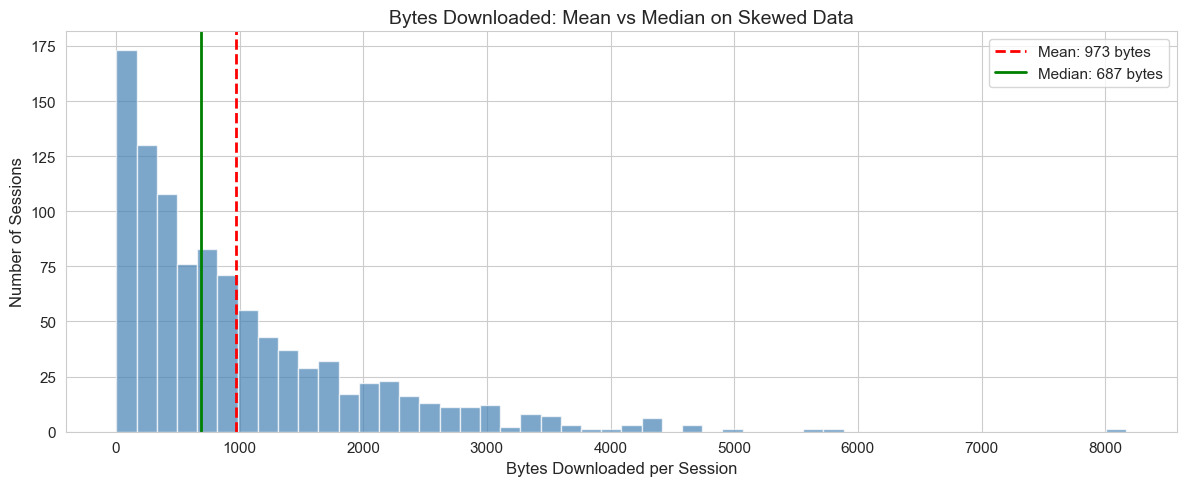

Mean:   973 bytes
Median: 687 bytes

The mean is 1.4x higher than the median!
The median better represents the "typical" session.


In [10]:
# Visualizing mean vs median with skewed data

# Simulate bytes downloaded per session
# Most sessions download small amounts, but some download huge amounts
np.random.seed(42)
bytes_downloaded = np.random.exponential(scale=1000, size=1000)

fig, ax = plt.subplots(figsize=(12, 5))

# Plot histogram
ax.hist(bytes_downloaded, bins=50, color='steelblue', alpha=0.7, edgecolor='white')

# Add vertical lines for mean and median
mean_val = np.mean(bytes_downloaded)
median_val = np.median(bytes_downloaded)

ax.axvline(mean_val, color='red', linestyle=' - ', linewidth=2, 
           label=f'Mean: {mean_val:.0f} bytes')
ax.axvline(median_val, color='green', linestyle='-', linewidth=2, 
           label=f'Median: {median_val:.0f} bytes')

ax.set_xlabel('Bytes Downloaded per Session', fontsize=12)
ax.set_ylabel('Number of Sessions', fontsize=12)
ax.set_title('Bytes Downloaded: Mean vs Median on Skewed Data', fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'Mean:   {mean_val:.0f} bytes')
print(f'Median: {median_val:.0f} bytes')
print(f'\nThe mean is {mean_val/median_val:.1f}x higher than the median!')
print('The median better represents the "typical" session.')

## Summary: Choosing the Right Measure

| Measure | Best For | Sensitive to Outliers? | Works on Categorical? |
|-----|-----|------------|-----------|
| Mean | Symmetric data, no outliers | **Yes (very!)** | No |
| Median | Skewed data, data with outliers | No (robust) | No |
| Mode | Categorical data | No | **Yes** |

### The Security Rule of Thumb

> **When in doubt, use the median.** Security data almost always has outliers, and the median will give you a better baseline than the mean.

### Quick Decision Guide

In [11]:
def choose_center_measure(data, name='values'):
    """
    Help decide whether to use mean or median for a baseline.
    
    This function examines your data and provides guidance.
    """
    data = np.array(data)
    
    mean_val = np.mean(data)
    median_val = np.median(data)
    ratio = mean_val / median_val if median_val != 0 else float('inf')
    
    # Calculate skewness
    skewness = stats.skew(data)
    
    print(f'Analysis of {name}:')
    print('=' * 50)
    print(f'Mean:            {mean_val:.2f}')
    print(f'Median:          {median_val:.2f}')
    print(f'Mean/Median:     {ratio:.2f}')
    print(f'Skewness:        {skewness:.2f}')
    print()
    
    # Provide recommendation
    if abs(skewness) > 1 or ratio > 1.3 or ratio < 0.7:
        print('📊 RECOMMENDATION: Use the MEDIAN')
        print('   Reason: Data is skewed or has outliers')
        print(f'   Baseline value: {median_val:.2f}')
        return median_val
    else:
        print('📊 RECOMMENDATION: Mean is acceptable')
        print('   Reason: Data is relatively symmetric')
        print(f'   Baseline value: {mean_val:.2f}')
        return mean_val


# Test with our skewed download data
baseline = choose_center_measure(bytes_downloaded, 'bytes_downloaded')

Analysis of bytes_downloaded:
Mean:            972.51
Median:          686.78
Mean/Median:     1.42
Skewness:        1.87

📊 RECOMMENDATION: Use the MEDIAN
   Reason: Data is skewed or has outliers
   Baseline value: 686.78


### Key Takeaways

1. **The mean** is the familiar "average" but is easily fooled by outliers

2. **The median** is robust and better represents "typical" in skewed data

3. **Security data is almost always skewed**  -  prefer the median for baselines

4. **When mean and median differ significantly**, your data is skewed  -  that's a signal!

5. **Use mode for categorical data** where numerical measures don't apply

 - -

<a id='chapter-4'></a>
# Chapter 4: Measuring the Spread (Dispersion)

## The Intuition

Knowing the center isn't enough. Consider these two scenarios:

**Scenario A:** Users make 100 ± 5 API calls per day (very consistent)

**Scenario B:** Users make 100 ± 500 API calls per day (highly variable)

Both have the same center (100), but they're completely different! In Scenario A, someone making 200 calls is highly suspicious. In Scenario B, that's completely normal.

**Spread** (also called dispersion or variability) tells you how much values differ from each other:
- **High spread** = values are all over the place
- **Low spread** = values cluster tightly around the center

## Why Spread Matters for Detection

To detect anomalies, you need two things:

1. **What's the typical value?** (center  -  Chapter 2)
2. **How much variation is normal?** (spread  -  this chapter)

An observation is only anomalous if it's **far from the center relative to the normal spread**.

## Measures of Spread

### The Range (Simple but Useless)

**What it is:** Maximum minus minimum

**The problem:** Completely determined by the two most extreme values. One outlier ruins it.\n\n

In [12]:
# Range is not robust

normal_data = [45, 52, 48, 51, 47, 53, 49, 50, 46, 52]
with_outlier = normal_data + [500]  # One extreme value

print('Normal data:', sorted(normal_data))
print(f'Range: {max(normal_data) - min(normal_data)}')

print('\nWith one outlier (500):', sorted(with_outlier)[:5], '...', sorted(with_outlier)[-1])
print(f'Range: {max(with_outlier) - min(with_outlier)}')

print('\n⚠️  The range went from 8 to 455 because of one outlier!')
print('   Never use range for security data.')

Normal data: [45, 46, 47, 48, 49, 50, 51, 52, 52, 53]
Range: 8

With one outlier (500): [45, 46, 47, 48, 49] ... 500
Range: 455

⚠️  The range went from 8 to 455 because of one outlier!
   Never use range for security data.


### Variance and Standard Deviation

**The idea:** Measure how far, on average, each value is from the mean.

**Variance (σ²):** The average of squared distances from the mean

**Standard Deviation (σ):** The square root of variance (same units as your data)

**Why square the distances?**
- Some distances are positive (above mean), some are negative (below mean)
- If you just added them, they'd cancel out
- Squaring makes everything positive
- We take the square root at the end to get back to original units

**The problem:** Like the mean, standard deviation is sensitive to outliers.

In [13]:
# Step-by-step calculation of standard deviation

data = np.array([45, 52, 48, 51, 47, 53, 49, 50, 46, 52])

print('Understanding Standard Deviation Step by Step:')
print('=' * 50)
print(f'Data: {data}')

# Step 1: Calculate mean
mean = np.mean(data)
print(f'\nStep 1 - Mean: {mean}')

# Step 2: Calculate deviations from mean
deviations = data - mean
print(f'\nStep 2 - Deviations from mean:')
for val, dev in zip(data, deviations):
    print(f'  {val} - {mean} = {dev:+.1f}')

# Step 3: Square the deviations
squared_devs = deviations ** 2
print(f'\nStep 3 - Square each deviation (makes all positive):')
print(f'  {[round(x, 1) for x in squared_devs]}')

# Step 4: Average of squared deviations (variance)
variance = np.mean(squared_devs)
print(f'\nStep 4 - Variance (average of squared deviations): {variance:.2f}')

# Step 5: Square root (standard deviation)
std_dev = np.sqrt(variance)
print(f'\nStep 5 - Standard Deviation (square root): {std_dev:.2f}')

print(f'\n📊 Interpretation:')
print(f'   Values typically deviate about {std_dev:.1f} units from the mean of {mean}')

Understanding Standard Deviation Step by Step:
Data: [45 52 48 51 47 53 49 50 46 52]

Step 1 - Mean: 49.3

Step 2 - Deviations from mean:
  45 - 49.3 = -4.3
  52 - 49.3 = +2.7
  48 - 49.3 = -1.3
  51 - 49.3 = +1.7
  47 - 49.3 = -2.3
  53 - 49.3 = +3.7
  49 - 49.3 = -0.3
  50 - 49.3 = +0.7
  46 - 49.3 = -3.3
  52 - 49.3 = +2.7

Step 3 - Square each deviation (makes all positive):
  [np.float64(18.5), np.float64(7.3), np.float64(1.7), np.float64(2.9), np.float64(5.3), np.float64(13.7), np.float64(0.1), np.float64(0.5), np.float64(10.9), np.float64(7.3)]

Step 4 - Variance (average of squared deviations): 6.81

Step 5 - Standard Deviation (square root): 2.61

📊 Interpretation:
   Values typically deviate about 2.6 units from the mean of 49.3


In [14]:
# Standard deviation is sensitive to outliers

print('Standard deviation comparison:')
print(f'\nWithout outlier: std = {np.std(normal_data):.2f}')
print(f'With outlier:    std = {np.std(with_outlier):.2f}')

print(f'\n⚠️  One outlier increased std from 2.6 to 132!')
print('   This is a problem for security data.')

Standard deviation comparison:

Without outlier: std = 2.61
With outlier:    std = 129.59

⚠️  One outlier increased std from 2.6 to 132!
   This is a problem for security data.


### Interquartile Range (IQR)  -  A Robust Alternative

**The idea:** Instead of looking at all data, focus on the middle 50%.

**Quartiles** divide your sorted data into four equal parts:
- **Q1** (25th percentile): 25% of data is below this
- **Q2** (50th percentile): The median  -  50% below
- **Q3** (75th percentile): 75% of data is below this

**IQR = Q3 - Q1**

The IQR tells you the range of the "middle half" of your data, ignoring the extremes.

In [15]:
# IQR is robust to outliers

def calculate_iqr(data):
    """Calculate IQR and return quartiles."""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    return iqr, q1, q3

iqr_normal, q1_n, q3_n = calculate_iqr(normal_data)
iqr_outlier, q1_o, q3_o = calculate_iqr(with_outlier)

print('Without outlier:')
print(f'  Q1 (25th percentile): {q1_n}')
print(f'  Q3 (75th percentile): {q3_n}')
print(f'  IQR: {iqr_normal}')

print('\nWith outlier (500):')
print(f'  Q1: {q1_o}')
print(f'  Q3: {q3_o}')
print(f'  IQR: {iqr_outlier}')

print(f'\n✓ IQR barely changed! ({iqr_normal} → {iqr_outlier})')
print('  The outlier doesn\'t affect the middle 50%.')

Without outlier:
  Q1 (25th percentile): 47.25
  Q3 (75th percentile): 51.75
  IQR: 4.5

With outlier (500):
  Q1: 47.5
  Q3: 52.0
  IQR: 4.5

✓ IQR barely changed! (4.5 → 4.5)
  The outlier doesn't affect the middle 50%.


### Median Absolute Deviation (MAD)  -  The Best for Security

**The idea:** Use median for both the center and the spread measure.

**How to calculate:**
1. Find the median of your data
2. Calculate how far each value is from the median (absolute distance)
3. Take the median of those distances

**MAD = median( |each value - median| )**

**Why MAD is powerful:**
- Uses median twice (for center and spread)
- Extremely robust to outliers
- Perfect for security data with its inevitable extreme values

In [16]:
# Understanding MAD step by step

data = np.array([45, 52, 48, 51, 47, 53, 49, 50, 46, 52])

print('Understanding MAD (Median Absolute Deviation):')
print('=' * 50)
print(f'Data: {data}')

# Step 1: Calculate median
median = np.median(data)
print(f'\nStep 1 - Median: {median}')

# Step 2: Calculate absolute deviations from median
abs_deviations = np.abs(data - median)
print(f'\nStep 2 - Absolute deviations from median:')
for val, dev in zip(data, abs_deviations):
    print(f'  |{val} - {median}| = {dev}')

# Step 3: Median of those deviations
mad = np.median(abs_deviations)
print(f'\nStep 3 - Median of those deviations (MAD): {mad}')

# Verify with scipy
mad_scipy = median_abs_deviation(data)
print(f'\nVerification with scipy: {mad_scipy}')

Understanding MAD (Median Absolute Deviation):
Data: [45 52 48 51 47 53 49 50 46 52]

Step 1 - Median: 49.5

Step 2 - Absolute deviations from median:
  |45 - 49.5| = 4.5
  |52 - 49.5| = 2.5
  |48 - 49.5| = 1.5
  |51 - 49.5| = 1.5
  |47 - 49.5| = 2.5
  |53 - 49.5| = 3.5
  |49 - 49.5| = 0.5
  |50 - 49.5| = 0.5
  |46 - 49.5| = 3.5
  |52 - 49.5| = 2.5

Step 3 - Median of those deviations (MAD): 2.5

Verification with scipy: 2.5


In [17]:
# MAD is extremely robust to outliers

print('Comparing spread measures:')
print('=' * 50)

print('\nWithout outlier:')
print(f'  Standard Deviation: {np.std(normal_data):.2f}')
print(f'  MAD:                {median_abs_deviation(normal_data):.2f}')

print('\nWith outlier (500):')
print(f'  Standard Deviation: {np.std(with_outlier):.2f}  ← Exploded!')
print(f'  MAD:                {median_abs_deviation(with_outlier):.2f}  ← Stable!')

print('\n✓ MAD is the best choice for security data!')

Comparing spread measures:

Without outlier:
  Standard Deviation: 2.61
  MAD:                2.50

With outlier (500):
  Standard Deviation: 129.59  ← Exploded!
  MAD:                2.00  ← Stable!

✓ MAD is the best choice for security data!


## Visualizing Spread

Let's see why spread matters for detection.

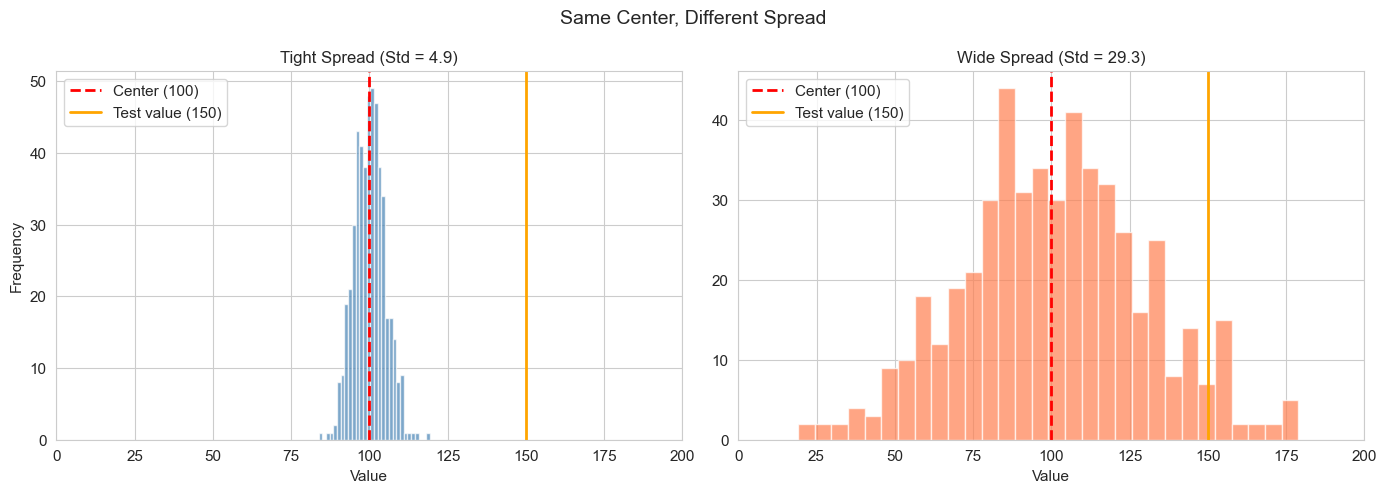

Key insight:
  A value of 150 is HIGHLY SUSPICIOUS in the left plot (10 std devs away!)
  But COMPLETELY NORMAL in the right plot (only 1.7 std devs away)

You MUST know the spread to detect anomalies!


In [18]:
# Visualizing the importance of spread

np.random.seed(42)

# Two datasets with same center but different spread
tight_spread = np.random.normal(loc=100, scale=5, size=500)   # Low variability
wide_spread = np.random.normal(loc=100, scale=30, size=500)   # High variability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tight spread
axes[0].hist(tight_spread, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(100, color='red', linestyle=' - ', linewidth=2, label='Center (100)')
axes[0].axvline(150, color='orange', linestyle='-', linewidth=2, label='Test value (150)')
axes[0].set_title(f'Tight Spread (Std = {np.std(tight_spread):.1f})', fontsize=12)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 200)
axes[0].legend()

# Wide spread
axes[1].hist(wide_spread, bins=30, color='coral', alpha=0.7, edgecolor='white')
axes[1].axvline(100, color='red', linestyle=' - ', linewidth=2, label='Center (100)')
axes[1].axvline(150, color='orange', linestyle='-', linewidth=2, label='Test value (150)')
axes[1].set_title(f'Wide Spread (Std = {np.std(wide_spread):.1f})', fontsize=12)
axes[1].set_xlabel('Value')
axes[1].set_xlim(0, 200)
axes[1].legend()

plt.suptitle('Same Center, Different Spread', fontsize=14)
plt.tight_layout()
plt.show()

print('Key insight:')
print('  A value of 150 is HIGHLY SUSPICIOUS in the left plot (10 std devs away!)')
print('  But COMPLETELY NORMAL in the right plot (only 1.7 std devs away)')
print('\nYou MUST know the spread to detect anomalies!')

## Summary: Choosing the Right Spread Measure

| Measure | Robust to Outliers? | Best For |
|-----|----------|------|
| Range | No (worst) | Never use for security |
| Std Dev | No | Clean, symmetric data only |
| IQR | Yes | Quick robust estimate |
| MAD | Yes (best) | Security baselines |

### The Security Rule

> **Use MAD (Median Absolute Deviation) for measuring spread in security data.** It's robust to the outliers that are everywhere in security telemetry.

In [19]:
def build_robust_baseline(data, name='metric'):
    """
    Build a robust baseline using median and MAD.
    
    This is the recommended approach for security data.
    """
    data = np.array(data)
    
    center = np.median(data)
    spread = median_abs_deviation(data)
    
    # Scale MAD to be comparable to std dev for normal distributions
    # (multiply by 1.4826)
    scaled_spread = spread * 1.4826
    
    print(f'Robust Baseline for {name}:')
    print('=' * 40)
    print(f'Center (median):     {center:.2f}')
    print(f'Spread (MAD):        {spread:.2f}')
    print(f'Scaled spread:       {scaled_spread:.2f}')
    print()
    print('Suggested thresholds:')
    print(f'  Warning (±2 spreads):  [{max(0, center - 2*scaled_spread):.2f}, {center + 2*scaled_spread:.2f}]')
    print(f'  Alert (±3 spreads):    [{max(0, center - 3*scaled_spread):.2f}, {center + 3*scaled_spread:.2f}]')
    
    return {
        'center': center,
        'spread': spread,
        'scaled_spread': scaled_spread,
        'warn_upper': center + 2 * scaled_spread,
        'alert_upper': center + 3 * scaled_spread
    }


# Example with our download data
np.random.seed(42)
downloads = np.random.exponential(scale=1000, size=1000)
baseline = build_robust_baseline(downloads, 'bytes_downloaded')

Robust Baseline for bytes_downloaded:
Center (median):     686.78
Spread (MAD):        490.63
Scaled spread:       727.41

Suggested thresholds:
  Warning (±2 spreads):  [0.00, 2141.59]
  Alert (±3 spreads):    [0.00, 2869.00]


### Key Takeaways

1. **Spread measures how much variation is normal**  -  essential for anomaly detection

2. **Standard deviation is sensitive to outliers**  -  one extreme value ruins your baseline

3. **MAD (Median Absolute Deviation) is robust**  -  use it for security data

4. **Anomaly = far from center RELATIVE TO SPREAD**  -  you need both measures

5. **Pair median with MAD**  -  they work together as robust alternatives to mean/std dev

 - -

## Advanced Shape Metrics: Skewness and Kurtosis
To truly make sense of the advanced techniques later in this playbook (like Heavy-Tailed Distributions and Extreme Value Theory), we must go beyond just measuring the center and spread. We must measure the *shape* of the distribution.

### Skewness (Where is the Tail?)
Skewness measures geometric asymmetry.
*   **Normal Distribution:** Skewness ≈ 0. The left and right sides mirror each other.
*   **Right-Skewed (Positive):** A long tail extending violently to the right. The Mean is heavily dragged to the right of the Median. `Mean >> Median`.
*   **Security Reality:** Security data is almost exclusively massively right-skewed. Most users download 5MB of data; one compromised host exfiltrates 500GB. If your data is right-skewed, standard statistics (like standard deviation) will completely fail.

### Kurtosis (How Fat are the Tails?)
Kurtosis explicitly measures the presence of extreme outliers (the "fatness" of the tails).
*   **Mesokurtic (Normal):** Kurtosis = 3. (In Python's `scipy.stats`, "Excess Kurtosis" = 0).
*   **Leptokurtic (Fat Tails):** Excess Kurtosis > 0.
*   **Security Reality:** Security volumes are incredibly Leptokurtic. This means that a mathematical "6-Sigma" event (which should statistically only happen once every 1.3 million years in a normal bell curve) might actually happen every single Tuesday on your network. This is fundamentally why standard SIEM anomaly detection generates so many false positives—it drastically underestimates the fatness of the tails.\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

np.random.seed(42)

# Normal data (e.g., human response times to a multi-factor authentication prompt)
normal_data = np.random.normal(loc=100, scale=15, size=1000)

# Security data (e.g., bytes transferred per session, naturally right-skewed and fat-tailed)
# We use a log-normal distribution to accurately simulate this reality
security_data = np.random.lognormal(mean=4, sigma=1.5, size=1000)

print("--- Normal Data ---")
print(f"Skewness:        {skew(normal_data):.2f} (Close to 0 = Symmetric)")
print(f"Excess Kurtosis: {kurtosis(normal_data):.2f} (Close to 0 = Normal tails)\n")

print("--- Security Data (Network Bytes) ---")
print(f"Skewness:        {skew(security_data):.2f} (Highly positive = Long right tail)")
print(f"Excess Kurtosis: {kurtosis(security_data):.2f} (Massively positive = Extremely fat tails)")

# Visualization to hammer home the mathematical shape difference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(normal_data, bins=30, color='blue', alpha=0.7)
axes[0].set_title('Normal Data\n(Symmetric, Skew ≈ 0)')

# We artificially cap the x-axis for the security data just so the histogram is readable,
# otherwise the massive fat-tail outliers stretch the graph into oblivion.
axes[1].hist(security_data, bins=50, color='red', alpha=0.7, range=(0, 2000))
axes[1].set_title('Security Data\n(Right-Skewed, Skew >> 0)')

plt.tight_layout()
plt.show()

<a id='chapter-5'></a>
# Chapter 5: Visualizing Distributions

## The Intuition

Numbers like mean, median, and standard deviation are useful summaries, but they don't tell the whole story. **Visualization reveals patterns that statistics hide.**

For security data, visualization helps you:
- See if data is skewed (long tail on one side)
- Spot outliers visually
- Identify multiple populations (humans vs bots, normal vs compromised)
- Understand what "normal" looks like before building detections

## Essential Visualizations for Security

### 1. Histogram  -  The Most Important Plot

Shows how frequently values occur in different ranges.\n\n

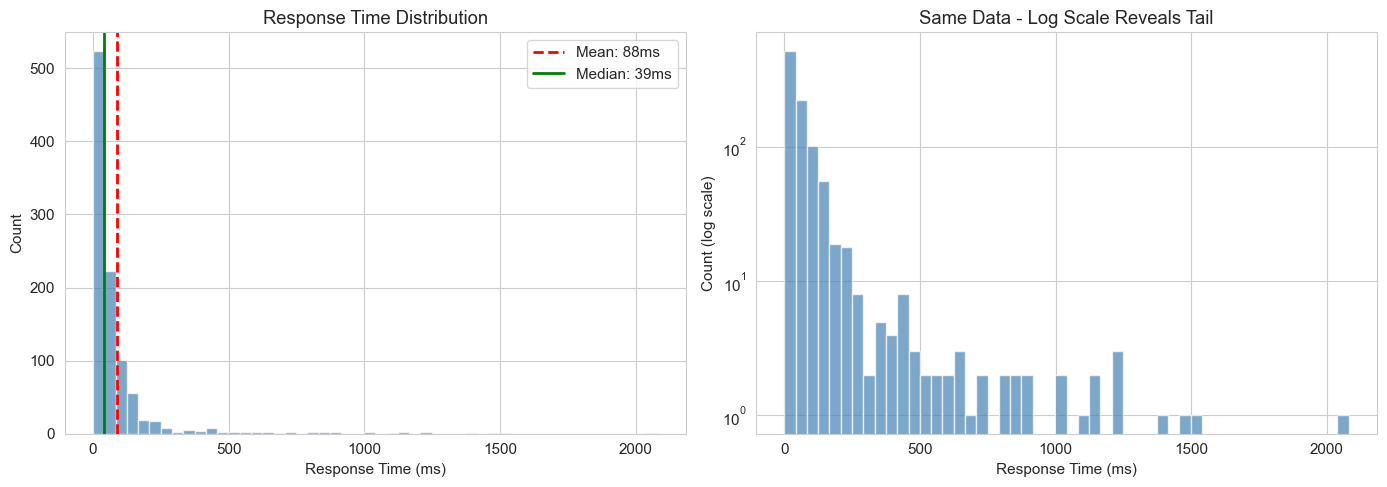

Key observations:
1. Data is heavily right-skewed (long tail)
2. Mean >> Median (confirms skewness)
3. Log scale reveals structure in the tail


In [33]:
# Histograms reveal distribution shape

np.random.seed(42)

# Simulate response times - most fast, some slow (security scan or attack?)
response_times = np.concatenate([
    np.random.exponential(scale=50, size=900),    # Normal responses
    np.random.exponential(scale=500, size=100)    # Slow responses
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(response_times, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(np.mean(response_times), color='red', linestyle=' - ', lw=2, label=f'Mean: {np.mean(response_times):.0f}ms')
axes[0].axvline(np.median(response_times), color='green', linestyle='-', lw=2, label=f'Median: {np.median(response_times):.0f}ms')
axes[0].set_xlabel('Response Time (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('Response Time Distribution')
axes[0].legend()

# Log scale - reveals the tail
axes[1].hist(response_times, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_xlabel('Response Time (ms)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Same Data - Log Scale Reveals Tail')

plt.tight_layout()
plt.show()

print('Key observations:')
print('1. Data is heavily right-skewed (long tail)')
print('2. Mean >> Median (confirms skewness)')
print('3. Log scale reveals structure in the tail')

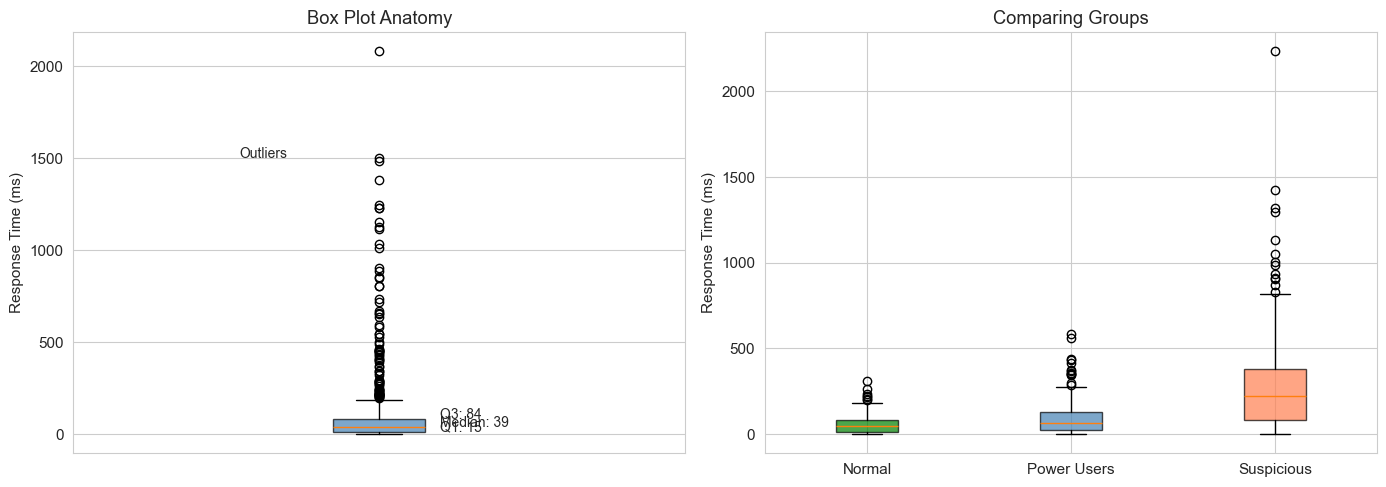

In [34]:
# Box plot - summarizes distribution and shows outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single box plot with explanation
bp = axes[0].boxplot(response_times, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
axes[0].set_ylabel('Response Time (ms)')
axes[0].set_title('Box Plot Anatomy')
axes[0].set_xticks([])

# Add annotations
q1, med, q3 = np.percentile(response_times, [25, 50, 75])
axes[0].annotate(f'Q3: {q3:.0f}', xy=(1.1, q3), fontsize=10)
axes[0].annotate(f'Median: {med:.0f}', xy=(1.1, med), fontsize=10)
axes[0].annotate(f'Q1: {q1:.0f}', xy=(1.1, q1), fontsize=10)
axes[0].annotate('Outliers', xy=(0.85, 1500), fontsize=10, ha='right')

# Compare groups
normal_users = np.random.exponential(scale=50, size=200)
power_users = np.random.exponential(scale=100, size=200)
suspicious = np.random.exponential(scale=300, size=200)

bp2 = axes[1].boxplot([normal_users, power_users, suspicious], 
                       labels=['Normal', 'Power Users', 'Suspicious'],
                       patch_artist=True)
colors = ['green', 'steelblue', 'coral']
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Response Time (ms)')
axes[1].set_title('Comparing Groups')

plt.tight_layout()
plt.show()

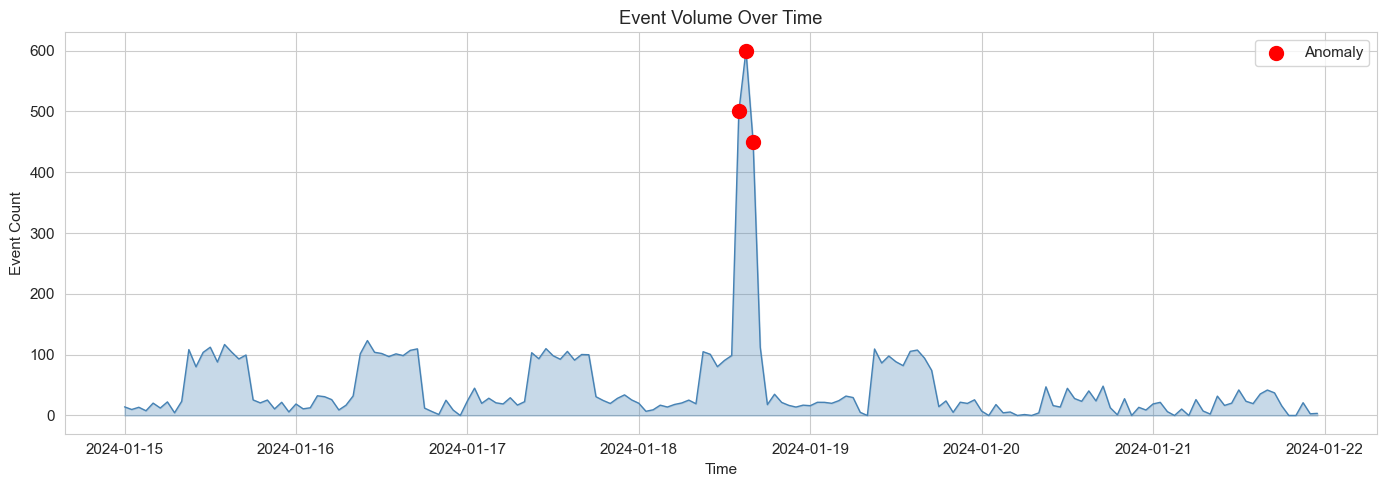

Patterns visible:
- Daily cycle: high during work hours, low at night
- Weekly cycle: lower on weekends
- Anomaly: massive spike on Thursday afternoon


In [35]:
# Time series - patterns over time

# Generate 7 days of hourly event data with patterns
hours = pd.date_range('2024-01-15', periods=24*7, freq='H')
n_hours = len(hours)

# Work hours pattern
hour_effect = np.where((hours.hour >= 9) & (hours.hour <= 17), 100, 20)
# Weekend effect
weekend_effect = np.where(hours.dayofweek >= 5, 0.3, 1.0)
# Combine with noise
event_counts = np.maximum(0, hour_effect * weekend_effect + np.random.normal(0, 10, n_hours))

# Add an attack spike
attack_idx = 24*3 + 14  # Thursday 2pm
event_counts[attack_idx:attack_idx+3] = [500, 600, 450]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hours, event_counts, color='steelblue', linewidth=1)
ax.fill_between(hours, event_counts, alpha=0.3, color='steelblue')

# Highlight anomaly
ax.scatter(hours[attack_idx:attack_idx+3], event_counts[attack_idx:attack_idx+3],
           color='red', s=100, zorder=5, label='Anomaly')

ax.set_xlabel('Time')
ax.set_ylabel('Event Count')
ax.set_title('Event Volume Over Time')
ax.legend()

plt.tight_layout()
plt.show()

print('Patterns visible:')
print('- Daily cycle: high during work hours, low at night')
print('- Weekly cycle: lower on weekends')
print('- Anomaly: massive spike on Thursday afternoon')

### Key Takeaways

1. **Always visualize before computing**  -  plots reveal what numbers hide
2. **Use log scale for skewed data**  -  reveals structure in the tail
3. **Box plots show outliers explicitly**  -  great for comparing groups
4. **Time series reveal patterns**  -  seasonality, trends, anomalies

 - -

<a id='chapter-6'></a>
# Chapter 6: Visualization Pitfalls and How Graphs Lie

## The Intuition
Visualizations are the most powerful tool for communicating complex telemetry to SOC analysts or leadership. However, because our visual cortex eagerly identifies patterns, bad graphs can trick the brain into seeing anomalies that do not mathematically exist, or worse, hide critical attacks in plain sight.

## Building Understanding

1. **The Bin Size Illusion (Histograms)**
If you plot network bytes in a histogram using 5 massive bins, the graph will look completely smooth. If you plot the exact same data using 500 tiny bins, it will look incredibly jagged and volatile. An attacker exfiltrating 5GB of data can be entirely hidden if you accidentally configure your histogram's bin size to be increments of 10GB. 

2. **Y-Axis Manipulation**
By artificially setting the Y-axis to start at 90 instead of 0, a 1% increase in CPU usage can be visually distorted to look like a massive 500% spike. In security dashboards, always ensure axes are conceptually pinned to zero unless explicitly comparing micro-variance.

3. **Logarithmic Distortion**
When dealing with heavy-tailed security data, analysts often apply a log-scale to the Y-axis. This is necessary to make the graph readable, but it visually crushes the outlier peaks. A bar that is just *twice as tall* on a log-scale represents an event that occurred *100 times more often*. Do not trust vertical height identically on log-scaled graphs.

4. **The Prohibition on Pie Charts**
Pie charts are mathematically terrible for comparing quantities because the human brain struggles to accurately measure 2D area and angles. In security, there are often 50+ unique categories (Event IDs, Windows Error Codes). A pie chart with 50 slices is an unreadable circle of noise. **Always use a horizontal bar chart instead.**\n

<a id='chapter-7'></a>
# Chapter 7: What is a Distribution?

## The Intuition

A **distribution** describes the pattern of values in your data  -  how common each value is and what shape the data takes when you plot it.

Think of it as answering: "If I pick a random observation, what values am I likely to see?"

### Why Distributions Matter for Security

Understanding distributions helps you:
1. **Know what's normal**  -  The distribution shows you the full range of expected behavior
2. **Detect anomalies**  -  Values in the tails (rare regions) may indicate attacks
3. **Choose the right statistics**  -  Different distributions need different methods
4. **Set appropriate thresholds**  -  Base your alerts on actual data patterns

### Common Distribution Shapes in Security Data\n\n

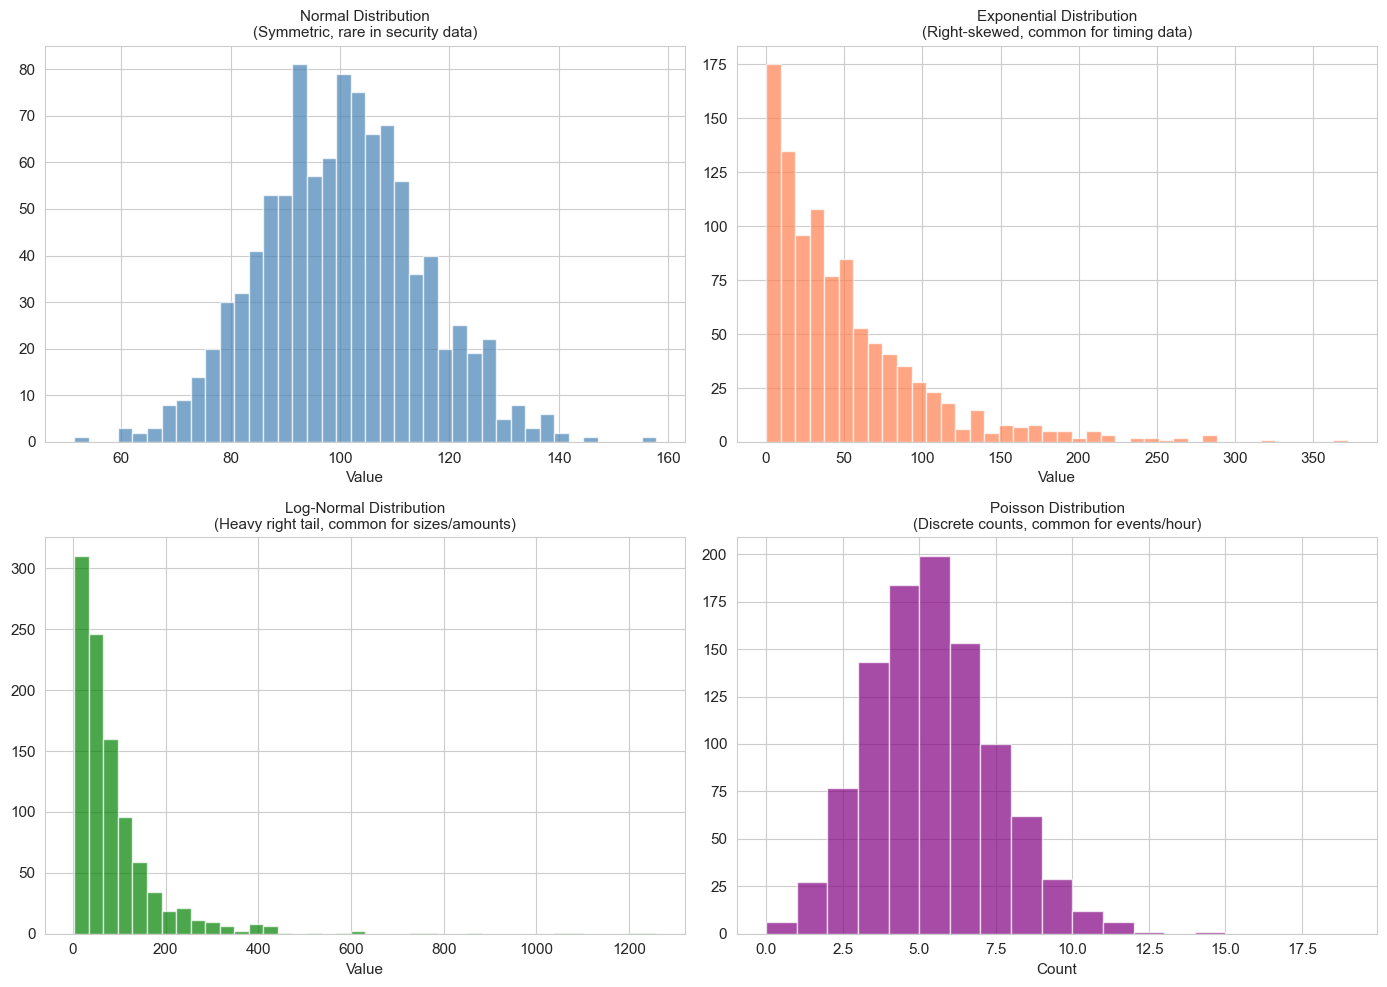

Security data usually follows exponential or log-normal distributions,
NOT the normal distribution that statistics textbooks assume!


In [20]:
# Visualizing common distribution shapes

np.random.seed(42)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Normal (rare in security)
normal = np.random.normal(100, 15, 1000)
axes[0, 0].hist(normal, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0, 0].set_title('Normal Distribution\n(Symmetric, rare in security data)', fontsize=11)
axes[0, 0].set_xlabel('Value')

# Exponential (very common - response times, wait times)
exponential = np.random.exponential(50, 1000)
axes[0, 1].hist(exponential, bins=40, color='coral', alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Exponential Distribution\n(Right-skewed, common for timing data)', fontsize=11)
axes[0, 1].set_xlabel('Value')

# Log-normal (file sizes, transaction amounts)
lognormal = np.random.lognormal(4, 1, 1000)
axes[1, 0].hist(lognormal, bins=40, color='green', alpha=0.7, edgecolor='white')
axes[1, 0].set_title('Log-Normal Distribution\n(Heavy right tail, common for sizes/amounts)', fontsize=11)
axes[1, 0].set_xlabel('Value')

# Poisson (event counts)
poisson = np.random.poisson(5, 1000)
axes[1, 1].hist(poisson, bins=range(0, 20), color='purple', alpha=0.7, edgecolor='white')
axes[1, 1].set_title('Poisson Distribution\n(Discrete counts, common for events/hour)', fontsize=11)
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('Security data usually follows exponential or log-normal distributions,')
print('NOT the normal distribution that statistics textbooks assume!')

<a id='chapter-8'></a>
# Chapter 8: Why Distributions Dictate Your Models

## The Intuition
We spent the previous chapters defining Normal, Log-Normal, Heavy-Tailed, and Poisson distributions. But why does this matter? Connecting it all together: **You do not get to choose your model; the data's distribution chooses the model for you.**

## Building Understanding

**Connecting the Pipeline:**
If you arbitrarily choose to use Standard Deviation on a firewall dataset without checking its distribution via EDA first, you are acting blindly. 

1. **If EDA proves the data is Symmetrical (Normal):**
   - You have clearance to use Mean and Standard Deviation. 
   - You can confidently use traditional parametric Z-Scores to find anomalies.

2. **If EDA proves the data is Skewed (Heavy-Tailed / Log-Normal):**
   - Traditional math breaks. The Mean is dragged out by the tail.
   - You MUST switch to robust statistics: Median, MAD, and Modified Z-Scores. 
   - You must consider applying Log-Transforms (`np.log()`) before passing the data to Machine Learning models, otherwise the model will overfit on the extreme outliers.

3. **If EDA proves the data counts discrete rare events (Poisson):**
   - You cannot use Euclidean distance. You must model the inter-arrival time using probability density equations.

Your entire detection engineering architecture—from simple threshold alerts in SPL to deep learning autoencoders—is legally bound by the underlying physical geometry of the distribution.\n

<a id='chapter-9'></a>
# Chapter 9: The Normal Distribution

## The Intuition

The Normal Distribution (or Gaussian distribution) is the classic "bell curve" you likely learned about in school. It assumes that most values cluster tightly around the mean, and extreme values are incredibly rare.

If security data looked like a bell curve, our jobs would be easy. We could just use standard deviation to set thresholds and go to lunch. However, security data almost never follows a normal distribution.

## Building Understanding

In a true normal distribution, there is a predictable rule called the Empirical Rule (or 68-95-99.7 rule). 
About 68% of data falls within one standard deviation of the mean.
About 95% falls within two standard deviations.
About 99.7% falls within three standard deviations.

This means a value four or five standard deviations away is mathematically near-impossible. But in security, we see these "impossible" values all the time. A single process might occasionally allocate 1000x more memory than usual without being malicious. A burst of network traffic might be 100 times larger than the average.

### Why Security Data Isn't Normal

Human behavior, computer networks, and adversarial actions are not random coin flips. They involve deliberate intent, automated bursts, and compound failures. This leads to data shapes that are heavily skewed or have thick "tails" where extreme values live comfortably.

### The Central Limit Theorem

There is one saving grace. The Central Limit Theorem states that if you take enough independent samples and calculate their means, those *means* will form a normal distribution, regardless of the original data's shape. This is occasionally useful if we are comparing average behavior over many groups or days rather than individual events.
\n\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Comparing a normal distribution to a typical security distribution
np.random.seed(42)

# A neat, normal bell curve
normal_data = np.random.normal(loc=100, scale=15, size=1000)

# A highly skewed security-like distribution (e.g., bytes transferred)
# We will learn more about this in Chapter 7
skewed_data = np.random.lognormal(mean=3, sigma=1.5, size=1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(normal_data, bins=50, color='blue', alpha=0.7)
ax1.set_title('Normal Distribution (Rare in Security)')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

ax2.hist(skewed_data, bins=50, color='red', alpha=0.7)
ax2.set_title('Right-Skewed Data (Common in Security)')
ax2.set_xlabel('Value')
# Limiting x-axis to zoom in on the main cluster, ignoring the massive tail
ax2.set_xlim(0, 1000) 

plt.tight_layout()
plt.show()


## Security Application

When a vendor pitches you an anomaly detection tool, ask what statistical assumptions their model makes. If they say "we trigger alerts at three standard deviations," they are assuming the data is normally distributed. You now know that this will result in a flood of false positives when applied to network bytes or execution times.

## Common Pitfalls

Assuming normality is the most common statistical error in detection engineering. Always visualize your data with a histogram first. If it does not look like a symmetrical bell, do not use simple mean and standard deviation. Stick to the robust statistics (median and MAD) we covered earlier.


<a id='chapter-10'></a>
# Chapter 10: Heavy-Tailed Distributions

## The Intuition

If the normal distribution is a neat bell, heavy-tailed distributions look like ski slopes. They start with a massive spike on the left and trail off into a very long, flat "tail" on the right. 

In these distributions, extreme outliers are not just possible. They are expected. The 80/20 rule (Pareto principle) is a classic example. 80 percent of your network traffic might come from 20 percent of your users. 

## Building Understanding

There are several variations of heavy-tailed distributions.

1. **Log-Normal**
If you take the logarithm of the values and plot them, they form a normal bell curve. File sizes and transaction amounts often follow this pattern. A bulk of files are tiny, but a few massive database backups exist and skew the average.

2. **Power Laws (Pareto)**
These are extreme versions of heavy tails. In a power law, a single event can dwarf all other events combined. Think of internet virality or DNS request volumes. One automated system might make a million requests while humans make five.

### How to Identify Them

The quickest tell of a heavy right tail is checking the center measures. If your mean is massively larger than your median, the mean is being pulled by extreme outliers.
(Mean >> Median)

Another method is the log-log plot. If you plot the frequency against the values on a graph where both axes are logarithmic, a power law distribution will look like a straight descending line.
\n\n

In [ ]:
# Let's see how mean and median differ in heavy-tailed data
import numpy as np

np.random.seed(42)
# Simulating bytes transferred in network flows
# Most flows are small (web browsing), a few are huge (file downloads)
network_bytes = np.random.lognormal(mean=8, sigma=2, size=10000)

mean_bytes = np.mean(network_bytes)
median_bytes = np.median(network_bytes)
max_bytes = np.max(network_bytes)

print(f"Median bytes (typical value)    {median_bytes:10.0f}")
print(f"Mean bytes (distorted average)  {mean_bytes:10.0f}")
print(f"Max bytes (the extreme tail)    {max_bytes:10.0f}")
print(f"\nNotice the mean is pulled much higher than the median.")


## Security Application

Log-normal and Pareto distributions dominate security logs. 

When establishing baseline activity for a user, you cannot use average daily bytes downloaded. A single legitimate ISO download will inflate the user's average, hiding a slow-and-low low exfiltration attempt later. 

Always use log scale when plotting security data histograms. If the standard histogram looks entirely concentrated in one bin, applying a logarithm to the values will reveal the true shape of the data.

## Common Pitfalls

Never remove the "outliers" from a heavy-tailed distribution just to make the data look cleaner. In a power law, the extreme events are the most important part of the data. Instead of discarding them, transform your perspective using robust statistics or logarithmic scales.


<a id='chapter-11'></a>
# Chapter 11: Counting Events

## The Intuition

Security Detection Engineers spend a lot of time counting. How many failed logins per hour? How many unique IP connections per minute? We are observing individual, discrete events happening over a specific window of time.

The statistical model for these independent events is the Poisson distribution.

## Building Understanding

The Poisson distribution predicts the probability of a given number of events occurring in a fixed interval of time or space, assuming these events happen at a known constant average rate and independently of each other.

If a server normally experiences 5 errors per hour, Poisson tells us exactly how likely it is to see 0 errors, 5 errors, or 15 errors in the next hour. 

A unique mathematical property of a pure Poisson distribution is that its variance equals its mean. If the average rate is 10 events, the variance is also 10.

### The Problem of Overdispersion

If you map your actual security counts, you will likely find that the variance is much larger than the mean. This is called overdispersion.

Why does this happen? Because security events are rarely independent. A password spray attack is clearly not independent random failed logins. One failed login from a script guarantees hundreds more will follow in the next millisecond. The cluster-nature of security events violates the core assumption of the Poisson model.
\n\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# True Poisson process (independent events)
lam = 5 # Average rate is 5 events per hour
events = np.arange(0, 15)
poisson_probs = poisson.pmf(events, lam)

plt.figure(figsize=(8, 4))
plt.bar(events, poisson_probs, color='teal', alpha=0.7)
plt.title('Theoretical Poisson Distribution (Average=5)')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.xticks(events)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Security Application

While true Poisson processes are rare in the wild, the concept is highly relevant for setting rate limits and alarm thresholds. 

When deciding how many failed authentication attempts should trigger a lockout, you are estimating the tail of an event-count distribution. Since we know our data is overdispersed (clustered), simple rate queries often generate false positives during legitimate IT bulk operations. A better detection strategy pairs the raw count threshold with diversity metrics (e.g. 50 failed logins across 50 *different* usernames).

## Common Pitfalls

A high count of events in a short window does not immediately imply an attack. Automated cron jobs, system reboots, and retry-logic loops can all create massive spikes in event counts that look suspicious but are completely benign. Always look for context around the spike.


<a id='chapter-12'></a>
# Chapter 12: Z-Scores  -  Measuring Unusualness

## The Intuition

A **z-score** answers: "How unusual is this value, measured in standard deviations from the mean?"

- Z-score of 0 = exactly at the mean
- Z-score of 1 = one standard deviation above the mean
- Z-score of -2 = two standard deviations below the mean

### The Formula

**Z = (value - mean) / standard_deviation**

### Common Thresholds

For normally distributed data:
- |Z| > 2: Outside ~95% of data (potential warning)
- |Z| > 3: Outside ~99.7% of data (potential alert)\n\n

In [21]:
def calculate_zscore(value, data):
    """Calculate the z-score of a value relative to a dataset."""
    mean = np.mean(data)
    std = np.std(data)
    return (value - mean) / std if std > 0 else 0


# Example: Login attempts per user
np.random.seed(42)
normal_logins = np.random.normal(50, 10, 100)  # Mean=50, Std=10

test_values = [50, 60, 70, 80, 100, 150]

print('Z-Score Analysis: Login Attempts')
print('=' * 50)
print(f'Baseline: mean={np.mean(normal_logins):.1f}, std={np.std(normal_logins):.1f}')
print()

for val in test_values:
    z = calculate_zscore(val, normal_logins)
    
    if abs(z) > 3:
        status = 'ALERT'
    elif abs(z) > 2:
        status = 'WARNING'
    else:
        status = 'NORMAL'
    
    print(f'Value: {val:>4} | Z-score: {z:>6.2f} | {status}')

Z-Score Analysis: Login Attempts
Baseline: mean=49.0, std=9.0

Value:   50 | Z-score:   0.11 | NORMAL
Value:   60 | Z-score:   1.22 | NORMAL
Value:   70 | Z-score:   2.33 | WARNING
Value:   80 | Z-score:   3.43 | ALERT
Value:  100 | Z-score:   5.65 | ALERT
Value:  150 | Z-score:  11.18 | ALERT


### The Problem with Regular Z-Scores

Z-scores use mean and standard deviation, which are **sensitive to outliers**.

If your baseline includes attack data, the z-scores get distorted  -  the attacks inflate the mean and std, making new attacks look less anomalous!

**Solution: Modified Z-Score** (covered in Chapter 10)

 - -

<a id='chapter-13'></a>
# Chapter 13: Robust Statistics  -  The Modified Z-Score

## The Intuition

In Chapter 9, we learned about z-scores: how many standard deviations a value is from the mean. But we also learned that mean and standard deviation are sensitive to outliers.

The **Modified Z-Score** fixes this by using robust statistics:
- Instead of mean → use **median**
- Instead of std dev → use **MAD** (scaled)

This gives us an outlier score that isn't fooled by the very outliers we're trying to detect!

## The Formula

**Modified Z-Score = 0.6745 × (value - median) / MAD**

The 0.6745 is a scaling factor that makes the modified z-score comparable to the regular z-score for normally distributed data.

## Why This Matters for Security

Regular z-scores fail when your baseline is contaminated with attack data. The attack inflates the mean and standard deviation, making the attack look less anomalous!

Modified z-scores don't have this problem. Even if 10% of your data is attack traffic, the median and MAD stay stable.\n\n

In [25]:
def modified_zscore(values):
    """
    Calculate modified z-scores using median and MAD.
    
    This is the recommended method for security anomaly detection.
    
    Interpretation:
    - |score| > 3.5 is commonly used as the outlier threshold
    - This is equivalent to about 3 standard deviations for normal data
    """
    values = np.array(values)
    
    median = np.median(values)
    mad = median_abs_deviation(values)
    
    # Handle edge case where MAD is 0 (all values identical)
    if mad == 0:
        # Return 0 for values equal to median, infinity otherwise
        return np.where(values == median, 0, np.inf)
    
    # Calculate modified z-score
    # 0.6745 is the scaling factor to match standard z-scores for normal data
    m_zscore = 0.6745 * (values - median) / mad
    
    return m_zscore


# Example: Compare regular vs modified z-scores
np.random.seed(42)

# Normal baseline data
normal_data = np.random.normal(loc=100, scale=15, size=100)

# Add some attack traffic (outliers)
attack_data = np.array([500, 600, 700, 800])  # 4 extreme outliers
contaminated_data = np.concatenate([normal_data, attack_data])

# Test value to evaluate
test_value = 450  # Suspicious but not as extreme as the attacks

print('Comparing Z-Score Methods')
print('=' * 50)
print(f'Test value: {test_value}')
print(f'Normal data: mean={np.mean(normal_data):.1f}, std={np.std(normal_data):.1f}')
print(f'Contaminated data: mean={np.mean(contaminated_data):.1f}, std={np.std(contaminated_data):.1f}')
print()

# Regular z-scores
regular_z_clean = (test_value - np.mean(normal_data)) / np.std(normal_data)
regular_z_contaminated = (test_value - np.mean(contaminated_data)) / np.std(contaminated_data)

# Modified z-scores  
all_clean = np.append(normal_data, test_value)
all_contaminated = np.append(contaminated_data, test_value)
modified_z_clean = modified_zscore(all_clean)[-1]
modified_z_contaminated = modified_zscore(all_contaminated)[-1]

print('Regular Z-Score (mean/std):')
print(f'  Using clean baseline:        {regular_z_clean:.2f}')
print(f'  Using contaminated baseline: {regular_z_contaminated:.2f}  ← Attack hides itself!')
print()
print('Modified Z-Score (median/MAD):')
print(f'  Using clean baseline:        {modified_z_clean:.2f}')
print(f'  Using contaminated baseline: {modified_z_contaminated:.2f}  ← Still catches it!')
print()
print('⚠️  The regular z-score dropped from 23 to 2.6 when contaminated!')
print('✓  The modified z-score stayed high and still detects the anomaly!')

Comparing Z-Score Methods
Test value: 450
Normal data: mean=98.4, std=13.6
Contaminated data: mean=119.7, std=109.1

Regular Z-Score (mean/std):
  Using clean baseline:        25.94
  Using contaminated baseline: 3.03  ← Attack hides itself!

Modified Z-Score (median/MAD):
  Using clean baseline:        32.19
  Using contaminated baseline: 27.85  ← Still catches it!

⚠️  The regular z-score dropped from 23 to 2.6 when contaminated!
✓  The modified z-score stayed high and still detects the anomaly!


In [26]:
def detect_outliers_robust(data, threshold=3.5):
    """
    Detect outliers using the modified z-score method.
    
    Parameters:
     -  -  -  -  - -
    data : array-like
        Your data
    threshold : float
        Modified z-score threshold (default 3.5 is common)
    
    Returns:
     -  -  -  - 
    DataFrame with original values, scores, and outlier flags
    """
    data = np.array(data)
    scores = modified_zscore(data)
    
    results = pd.DataFrame({
        'value': data,
        'modified_zscore': scores,
        'is_outlier': np.abs(scores) > threshold
    })
    
    n_outliers = results['is_outlier'].sum()
    print(f'Found {n_outliers} outliers out of {len(data)} values ({n_outliers/len(data)*100:.1f}%)')
    print(f'Median: {np.median(data):.2f}')
    print(f'MAD: {median_abs_deviation(data):.2f}')
    print(f'Threshold: ±{threshold}')
    
    return results


# Example with API call counts
np.random.seed(42)
api_calls = np.concatenate([
    np.random.poisson(lam=50, size=95),  # Normal users
    np.array([500, 800, 1200, 50, 45])   # 3 attackers + 2 normal
])

print('Detecting outliers in API call counts:')
print('=' * 50)
results = detect_outliers_robust(api_calls)

print('\nOutliers detected:')
print(results[results['is_outlier']].sort_values('modified_zscore', ascending=False))

Detecting outliers in API call counts:
Found 3 outliers out of 100 values (3.0%)
Median: 50.50
MAD: 5.50
Threshold: ±3.5

Outliers detected:
    value  modified_zscore  is_outlier
97   1200       140.970500        True
96    800        91.915955        True
95    500        55.125045        True


### Key Takeaways

1. **Modified z-score uses median and MAD** instead of mean and std dev

2. **It's robust to contamination**  -  even if attackers are in your baseline, they don't hide themselves

3. **Threshold of 3.5 is common**  -  equivalent to about 3 standard deviations for normal data

4. **Always prefer modified z-score** for security anomaly detection

 - -

<a id='chapter-14'></a>
# Chapter 14: Log-Normal Transformations (Taming the Tail)

## The Intuition
We previously praised the Modified Z-Score (MAD) as the ultimate robust statistic. But on incredibly massive datasets (like 100 billion firewall flows), even the Median and MAD can break down if the data is violently heavy-tailed. 

If most users transfer 5KB, but a few users transfer 5GB, the IQR is so tightly packed near 5KB that applying a threshold of `Median + (3.5 * MAD)` might still flag every transfer over 100KB as an anomaly, creating a tidal wave of false positives.

## Building Understanding
Instead of tweaking your threshold, **change the geometry of the data.** 

If data follows a Log-Normal distribution (which mathematically defines 90% of all security telemetry), it means the *logarithm* of the data follows a perfect Normal bell curve.
By simply commanding Python to calculate `np.log1p(bytes)`, you instantly compress a wildly skewed, heavy-tailed distribution into a perfectly symmetrical Normal distribution. 

1. **Transform:** Calculate the natural log of all raw values.
2. **Analyze:** The tail vanishes! You can now use standard Means, Z-Scores, and Euclidean distances.
3. **Threshold:** Find outliers in the log-space, then convert the boundary back to reality using exponents `np.exp()`.

This is computationally cheaper than Isolation Forests, operates globally across massive big-data platforms (like Splunk or BigQuery), and mathematically eliminates the false-positive explosion caused by extreme tails.\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

np.random.seed(42)

# Simulating 100,000 highly skewed network flows
# Majority are tiny (10KB - 50KB), but a very long tail extends into the GBs
raw_bytes = np.random.lognormal(mean=10, sigma=2, size=100000)

# The MAD Breakdown
median = np.median(raw_bytes)
mad = median_abs_deviation(raw_bytes)
# Modified Z-Score boundary of 3.5
mad_threshold = median + (3.5 * mad * 1.4826)

print("--- The MAD Failure on Massive High-Variance Skew ---")
print(f"Median: {median:,.0f} bytes")
print(f"Calculated Threshold (3.5 MAD): {mad_threshold:,.0f} bytes")
# Check how many false positives we get!
fp_count = np.sum(raw_bytes > mad_threshold)
print(f"False Positives Generated: {fp_count:,} out of 100,000 sessions!\n")

print("--- The Log-Transformation Solution ---")
# 1. Transform the data natively
# We use log1p (log(1+x)) to safely handle any values of 0 bytes
log_bytes = np.log1p(raw_bytes)

# 2. Since it is now perfectly Normal, we use the standard Mean & Std Dev!
log_mean = np.mean(log_bytes)
log_std = np.std(log_bytes)

# 3. Apply standard Z-Score of 3 over the logged data
log_threshold = log_mean + (3 * log_std)
# Convert the logged threshold back into real bytes for the SOC
real_threshold = np.expm1(log_threshold)

print(f"Log-Space Mean: {log_mean:.2f}")
print(f"Log-Space Threshold (Mean + 3 Std): {log_threshold:.2f}")
print(f"Real-World Bytes Threshold: {real_threshold:,.0f} bytes")

fp_count_log = np.sum(raw_bytes > real_threshold)
print(f"False Positives Generated: {fp_count_log:,} (Silence is golden)\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_bytes, bins=100, color='red', alpha=0.7)
axes[0].set_title('Raw Bytes\n(Tail stretches infinitely to the right)')

axes[1].hist(log_bytes, bins=50, color='blue', alpha=0.7)
axes[1].axvline(log_threshold, color='black', linestyle='--', label='Z-Score Threshold on Log')
axes[1].set_title('Log-Transformed Bytes\n(Perfect Normal Bell Curve)')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id='chapter-15'></a>
# Chapter 15: Local Outlier Factor (LOF)

## The Intuition
DBSCAN (which we covered) is fantastic for finding anomalies outside of dense clusters. However, DBSCAN relies on a fixed, global radius (`eps`). If your data has multiple normal clusters, but ones are packed incredibly tight (a highly restricted service account executing the exact same 3 SQL queries) and others are widely spread out (general employees surfing the web), a global radius fails. 

**Local Outlier Factor (LOF)** solves this by analyzing the density of a data point *relative* to the density of its k-nearest neighbors. If a point's local density is substantially lower than the density of its neighbors, it is mathematically isolated and flagged as an outlier.

## Building Understanding
LOF calculates a score:
- **LOF ≈ 1**: The point has the exact same density as its neighbors (Normal).
- **LOF > 1.5**: The point has a much lower density than its neighbors (Outlier).

This allows the algorithm to find "local" anomalies that are close to a spread-out cluster, even if they would technically be perfectly "inside" a tightly packed cluster on the other side of the graph.\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

# Cluster 1: Tightly packed (Restricted Service Accounts)
# Low byte count, extremely low variance in response time
service_accs = np.random.normal(loc=[10, 10], scale=[1, 1], size=(100, 2))

# Cluster 2: Widely spread (Human Employees)
# High byte count, massive variance in response time
human_emps = np.random.normal(loc=[50, 50], scale=[8, 8], size=(100, 2))

# Combine them into normal behavior
X_normal = np.vstack([service_accs, human_emps])

# Anomalies
# Anomaly 1: A service account that is acting slightly out of bounds
# Because Cluster 1 is so tight, moving to [15, 15] is a massive statistical anomaly!
anomaly_service = np.array([[18, 18]])

# Anomaly 2: A human employee acting slightly out of bounds
# Cluster 2 is wide, so [60, 60] is totally normal. But [75, 75] is an anomaly.
anomaly_human = np.array([[80, 80]])

X_eval = np.vstack([X_normal, anomaly_service, anomaly_human])

# Run LOF
# novelty=False is used for outlier detection on a static dataset
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
predictions = lof.fit_predict(X_eval) # Returns 1 for inlier, -1 for outlier

# Extract the negative Local Outlier Factor scores (the lower the more abnormal)
lof_scores = -lof.negative_outlier_factor_

plt.figure(figsize=(9, 6))

# Plot normal points
inliers = X_eval[predictions == 1]
plt.scatter(inliers[:, 0], inliers[:, 1], color='blue', alpha=0.5, label='Normal Baseline')

# Plot outliers, scaling the red circle by the severity of the LOF score
outliers = X_eval[predictions == -1]
outlier_scores = lof_scores[predictions == -1]

plt.scatter(outliers[:, 0], outliers[:, 1], color='red', marker='x', s=100, label='Detected Anomalies')

# Draw circles reflecting the score explicitly
for i, pt in enumerate(outliers):
    plt.scatter(pt[0], pt[1], s=outlier_scores[i] * 100, facecolors='none', edgecolors='red', linewidth=2)

plt.title('Local Outlier Factor (LOF)\nHandles Vastly Different Cluster Densities')
plt.xlabel('Bytes Transferred')
plt.ylabel('Response Time Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Notice the Red anomaly near [18, 18].")
print(f"If we used a global distance metric (like K-Means or DBSCAN),")
print(f"that point would be considered safer than half the human employees.")
print(f"But LOF correctly flags it because it violates the strict LOCAL density of the service accounts.")

<a id='chapter-16'></a>
# Chapter 16: One-Class SVM (Novelty Detection)

## The Intuition
Traditional supervised Machine Learning (like Random Forests) requires two classes to draw a mathematical boundary between: "Malicious" vs "Benign". In security, you rarely have enough perfectly labeled "Malicious" data to teach a model what zero-days look like.

A **One-Class Support Vector Machine (SVM)** is trained *exclusively* on Benign data. It does not know what an attack is. Instead, it tightly wraps a multi-dimensional hyper-sphere around the normal baseline. In production, if any new telemetry falls outside of that perfectly molded hyper-sphere, it throws an alert. This is formally known as **Novelty Detection**.

## Building Understanding
Because One-Class SVMs use a "Kernel Trick" (usually an RBF kernel), they can map data into infinitely high dimensions, allowing them to draw shapes wrapping around data that is not a simple circle or square. They can wrap around complex, donut-shaped or highly irregular normal behavior perfectly.\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM

np.random.seed(42)

# Generate normal data in an irregular, curved shape (e.g. daily rhythmic volume)
t = np.linspace(0, 2 * np.pi, 200)
x_normal = np.sin(t) * 10 + np.random.normal(0, 1, 200)
y_normal = np.cos(t) * 10 + np.random.normal(0, 1, 200)
X_train = np.column_stack([x_normal, y_normal])

# Train the One-Class SVM EXCLUSIVELY on normal data
# nu is the upper bound on the fraction of margin errors (assume 1% of training data is noise)
# gamma defines how tightly the model wraps the boundary
svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
svm.fit(X_train)

# Generate new observations (Some normal, some malicious)
X_test_normal = np.column_stack([np.sin(t) * 10 + np.random.normal(0, 1, 200), np.cos(t) * 10 + np.random.normal(0, 1, 200)])
X_test_attack = np.array([[0, 0], [15, 15], [-12, -12]]) # Novelties

X_eval = np.vstack([X_test_normal, X_test_attack])

# Predict (-1 is Novelty/Anomaly, 1 is Normal)
predictions = svm.predict(X_eval)

# Generate a mesh grid to visualize the exact mathematical boundary the SVM drew
xx, yy = np.meshgrid(np.linspace(-18, 18, 100), np.linspace(-18, 18, 100))
# The decision_function returns the distance to the separating hyperplane
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
# Fill the contour where the model predicts 'Normal' (Z > 0)
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='lightblue', alpha=0.3)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkblue')

# Plot the evaluation data
plt.scatter(X_eval[predictions == 1, 0], X_eval[predictions == 1, 1], c='gray', alpha=0.8, s=20, label='Predicted Normal')
plt.scatter(X_eval[predictions == -1, 0], X_eval[predictions == -1, 1], c='red', marker='x', s=100, linewidths=2, label='Predicted Novelty (Attack)')

plt.title('One-Class SVM Novelty Detection\nWrapping a Boundary EXCLUSIVELY Around Normalcy')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id='chapter-17'></a>
# Chapter 17: Types of Outliers: Advanced Distance Metrics

## The Intuition
Detecting outliers is not just drawing a hard line on a graph. In Detection Engineering, you are usually measuring a user across multiple dimensions simultaneously: byte count, connection duration, unique IPs contacted, and time of day. 

If you evaluate each dimension individually, you will miss the attack. You need a mathematical way to say: "This user's byte count is normal, and their connection duration is normal, but the *combination* of the two is mathematically impossible."

## Building Understanding

There are three basic types of outliers:
1. **Point Outliers:** One single value is massive (e.g. 500GB download).
2. **Contextual Outliers:** A value is normal globally, but anomalous given the context (e.g. 500MB download by the Receptionist account, which normally downloads 0 bytes).
3. **Collective Outliers:** A sequence of normal actions that, when aggregated, form an attack (e.g. Brute forcing: 1 failed login is normal, 1,000 in an hour is anomalous).

### The Multivariate Problem: Mahalanobis Distance
When you track two correlated features (e.g., API Payload Size and API Response Time), a simple Euclidean distance (measuring straight-line distance from the center) fails completely. 

If payload size and response time always grow together (positive covariance), an API call with a MASSIVE payload and a MASSIVE response time is actually perfectly normal. But an API call with a MASSIVE payload and a TINY response time? That breaks the correlation. That is an anomaly.

To calculate this, we use the **Mahalanobis Distance**. The formula is:
$$ D^2 = (x - \mu)^T \Sigma^{-1} (x - \mu) $$

Where:
- $x$ is the new event you want to score.
- $\mu$ is the mean vector of all features.
- $\Sigma^{-1}$ is the **Inverse Covariance Matrix**.

By multiplying against the inverse covariance network, the math effectively "rotates" and "squashes" your data. It turns an angled elliptical cloud of data into a perfect circle. Once it's a perfect circle, you can calculate the distance from the center accurately. Any distance > 3 is a critical multivariate anomaly.
\n\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

np.random.seed(42)

# Normal User Behavior: Payload Size and Response Time are highly correlated
mean = [500, 50] # 500 bytes, 50ms average
cov = [[1000, 800], 
       [800, 1000]] # High positive covariance

normal_traffic = np.random.multivariate_normal(mean, cov, 1000)

inv_cov = np.linalg.inv(cov)

# Calculate Mahalanobis distance for all normal points
distances = [mahalanobis(pt, mean, inv_cov) for pt in normal_traffic]

# Define an anomaly boundary (e.g. 99th percentile of chi-square distribution)
# Mahalanobis distance squared follows a chi-square distribution
threshold = np.sqrt(chi2.ppf(0.99, df=2))

# Let's create two NEW events to test
# Event 1: Massive payload (600), massive response (60). Individually huge.
event_1 = [600, 60] 
# Event 2: Moderate payload (530), tiny response (20). Individually normal!
event_2 = [530, 20]

dist_1 = mahalanobis(event_1, mean, inv_cov)
dist_2 = mahalanobis(event_2, mean, inv_cov)

plt.figure(figsize=(8, 5))
plt.scatter(normal_traffic[:,0], normal_traffic[:,1], alpha=0.3, label='Normal Traffic')
plt.scatter(*event_1, color='green', s=100, label=f'Event 1 (Dist: {dist_1:.1f}) - NORMAL')
plt.scatter(*event_2, color='red', s=100, label=f'Event 2 (Dist: {dist_2:.1f}) - ANOMALY')
plt.title('Multivariate Anomaly Detection via Mahalanobis Distance')
plt.xlabel('Payload Size (Bytes)')
plt.ylabel('Response Time (ms)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Threshold for Anomaly: {threshold:.2f}\n")
print(f"Event 1 Distance: {dist_1:.2f} (Follows the correlation, so it is safe)")
print(f"Event 2 Distance: {dist_2:.2f} (Breaks the correlation! Potential exploit!)")

## Security Application
Attackers try to blend in by keeping their metrics below your single-dimension thresholds. They will throttle their byte counts to stay under the 99th percentile. However, it is mathematically incredibly difficult for an attacker to spoof multiple correlated metrics simultaneously. If you use Mahalanobis distance on (Bytes Transferred, Connection Duration, Port Number), you will catch "low and slow" beaconing that evades every single 1D threshold.

## Common Pitfalls
Using Mahalanobis distance on non-normal data. It assumes the underlying data follows a multivariate normal distribution. In security, data is often heavy-tailed (Chapter 7). To fix this, you must apply a logarithmic transformation to your features (`np.log(bytes)`) BEFORE calculating the covariance matrix and the distance.


<a id='chapter-18'></a>
# Chapter 18: Frequency Analysis

## The Intuition

**Frequency analysis** asks: "How often does each thing appear?"

This is fundamental to security because:
- Rare events may be suspicious
- Common patterns define "normal"
- Changes in frequency indicate changes in behavior\n\n

In [22]:
# Frequency analysis example

# Simulate API endpoint access logs
np.random.seed(42)

# Most traffic goes to a few endpoints
endpoints = np.random.choice(
    ['/api/users', '/api/login', '/api/data', '/api/admin', '/api/debug', '/api/internal/secrets'],
    size=1000,
    p=[0.35, 0.30, 0.20, 0.10, 0.04, 0.01]  # Admin and debug are rare
)

# Count frequencies
freq = pd.Series(endpoints).value_counts()

print('Endpoint Access Frequency')
print('=' * 50)
for endpoint, count in freq.items():
    pct = count / len(endpoints) * 100
    bar = '█' * int(pct / 2)
    print(f'{endpoint:25} | {count:4} ({pct:5.1f}%) {bar}')

print(f'\n⚠️  Note: /api/internal/secrets is rare ({freq.get("/api/internal/secrets", 0)/len(endpoints)*100:.1f}%)')
print('   Any access to this endpoint warrants investigation!')

Endpoint Access Frequency
/api/users                |  365 ( 36.5%) ██████████████████
/api/login                |  306 ( 30.6%) ███████████████
/api/data                 |  176 ( 17.6%) ████████
/api/admin                |  107 ( 10.7%) █████
/api/debug                |   40 (  4.0%) ██
/api/internal/secrets     |    6 (  0.6%) 

⚠️  Note: /api/internal/secrets is rare (0.6%)
   Any access to this endpoint warrants investigation!


In [23]:
# Frequency ratios - comparing categories

def analyze_frequency_ratios(events, category_col, numerator_val, denominator_val):
    """
    Calculate ratio between two categories.
    
    Useful for:
    - Success/Failure ratio
    - Read/Write ratio
    - Internal/External ratio
    """
    counts = pd.Series(events).value_counts()
    num = counts.get(numerator_val, 0)
    denom = counts.get(denominator_val, 0)
    
    if denom == 0:
        ratio = float('inf') if num > 0 else 0
    else:
        ratio = num / denom
    
    return {
        'numerator': num,
        'denominator': denom,
        'ratio': ratio,
        'pct_numerator': num / len(events) * 100
    }


# Example: Login success/failure ratio
login_outcomes = ['success'] * 920 + ['failure'] * 80  # 92% success rate

normal_ratio = analyze_frequency_ratios(login_outcomes, 'outcome', 'failure', 'success')
print(f'Normal failure/success ratio: {normal_ratio["ratio"]:.3f}')
print(f'Failure rate: {normal_ratio["pct_numerator"]:.1f}%')

# Under brute force attack
attack_outcomes = ['success'] * 50 + ['failure'] * 950  # Mostly failures
attack_ratio = analyze_frequency_ratios(attack_outcomes, 'outcome', 'failure', 'success')
print(f'\nUnder attack failure/success ratio: {attack_ratio["ratio"]:.1f}')
print(f'Failure rate: {attack_ratio["pct_numerator"]:.1f}%')
print('\n⚠️  19x increase in failure ratio indicates brute force attack!')

Normal failure/success ratio: 0.087
Failure rate: 8.0%

Under attack failure/success ratio: 19.0
Failure rate: 95.0%

⚠️  19x increase in failure ratio indicates brute force attack!


<a id='chapter-19'></a>
# Chapter 19: Ratios and Rates

## The Intuition

Frequency analysis (counting) is useful, but raw numbers can be deeply misleading. A user triggering 500 access denied errors sounds terrible, until you learn they also had 500,000 successful accesses that day. 

To get true context, we need to look at the relationship between two numbers using ratios and rates.
A **ratio** compares two quantities (like successes to failures).
A **rate** measures how fast something is happening across time or usage.

## Building Understanding

There are a few key metrics that every detection engineer should use when profiling users or systems.

1. **Success/Failure Ratios**
A brute-force attack often results in a highly skewed failure ratio (e.g. 1 success for every 10,000 failures). Humans usually have a very low failure ratio (1 failure for every 10 successes).

2. **Read/Write Ratios**
Ransomware typically has a massive write or encrypt ratio, while data exfiltration involves a massive read ratio. Normal users have an established rhythm of reading and writing.

3. **Rate Normalization**
Never look at raw event counts globally. Always normalize them. A spike of 1,000 failed logins globally is meaningless if your workforce doubled. But if the rate of failed logins *per active user per hour* suddenly spikes, that is a true signal.

4. **Velocity and Acceleration Metrics**
It is not just about the current speed (velocity, e.g. 50 requests per minute). Are they speeding up? Acceleration (the change in velocity) captures the sudden burst of a script kicking off faster than humanly possible.
\n\n

In [ ]:
import pandas as pd
import numpy as np

# Simulating API access logs for two users over an hour
# User A is a human, User B is an exfiltration script
data = {
    'user': ['User A'] * 50 + ['User B'] * 500,
    'action': ['read'] * 40 + ['write'] * 10 + ['read'] * 499 + ['write'] * 1,
    'bytes_transferred': np.random.normal(500, 100, 550)
}
df = pd.DataFrame(data)

# Calculate read/write ratios
action_counts = df.groupby(['user', 'action']).size().unstack(fill_value=0)
action_counts['read_write_ratio'] = action_counts['read'] / (action_counts['write'] + 1) # add 1 to avoid div zero

print("Action Counts and Ratios:")
print(action_counts)

# Velocity: actions per minute
# In reality, you'd divide by the active time window for each user.
# Here we just assume both were active for 60 minutes.
action_counts['velocity_per_min'] = (action_counts['read'] + action_counts['write']) / 60 

print("\nVelocity (Actions per minute):")
print(action_counts[['velocity_per_min']])


## Security Application

When a user complains about being locked out "randomly," the first thing to check is their auth success/failure ratio. If their ratio has been slowly creeping up over the last week, they likely have an expired token cached in script somewhere, creating a slow-drip of failures.

When hunting for data exfiltration, the "Novelty Ratio" is incredibly powerful. Compare the number of *new* distinct IPs a server talks to today versus the *total* distinct IPs it talks to. If a server usually talks to 5 IPs every day and today it talked to those 5 plus 1 new one (novelty ratio = 1/6), that's fine. If it usually talks to 5, but today it talked to 500 new ones, the novelty ratio approaches 1.0 (nearly 100% new destinations). That is a beaconing or sweeping indicator.

## Common Pitfalls

Dividing by zero is the bane of ratio metrics. Always add a small smoothing factor (like '+1') to the denominator when building automated ratio detectors, otherwise your SIEM alerts will crash the moment a user has zero successes or zero writes in a window.

Furthermore, ratios are incredibly noisy for small sample sizes. A user with 1 failure and 0 successes has a 100% failure rate, but it doesn't mean they are an attacker. They just fat-fingered their password once. Always require a minimum event threshold before evaluating a ratio.


<a id='chapter-20'></a>
# Chapter 20: Cardinality

## The Intuition

Cardinality means "count of unique things."

When analyzing network traffic, telling me that a server made 10,000 requests is frequency analysis. Telling me that those 10,000 requests all went to *different, unique IP addresses* is cardinality analysis. The first might just be a busy web server. The second is almost certainly a network scanner or a worm.

## Building Understanding

In security, high cardinality is often a strong indicator of automated behavior.

- High cardinality of destination IPs -> Network scanning
- High cardinality of usernames -> Password spraying
- High cardinality of accessed files -> Ransomware or bulk data exfiltration
- High cardinality of executed commands -> Enumeration script

### The Scaling Problem (HyperLogLog)

Counting unique items sounds computationally easy until you are running a SIEM that processes 10 billion events a day. Keeping a list of every single unique IP address in memory to check if the next one is "new" will crash your systems.

This introduces **HyperLogLog (HLL)**. HLL is a probabilistic data structure that estimates cardinality at massive scale. It uses almost zero memory. If you ask your database to `count(distinct ip_address)`, it might take 10 minutes. If you use the HLL implementation (like Spark's `approx_count_distinct`), it takes 5 seconds. The tradeoff is a tiny margin of error (e.g. 2%), which is perfectly acceptable for security detections where we only care about large anomalous leaps.
\n\n

In [ ]:
# Simulating the difference between frequency and cardinality
import pandas as pd
import numpy as np

# Server 1: Busy web server talking to the database a lot
server_1_destinations = ['10.0.0.5'] * 10000 

# Server 2: Compromised server running Nmap scanning the subnet
server_2_destinations = [f"10.0.1.{i}" for i in range(1, 255)] * 40 # 254 unique IPs, repeated 40 times

df1 = pd.DataFrame({'server': 'Server 1', 'dst_ip': server_1_destinations})
df2 = pd.DataFrame({'server': 'Server 2', 'dst_ip': server_2_destinations})
df = pd.concat([df1, df2])

metrics = df.groupby('server').agg(
    total_requests=('dst_ip', 'count'),          # Frequency
    unique_destinations=('dst_ip', 'nunique')    # Cardinality
)

print(metrics)
print("\nAlthough both servers have ~10,000 requests, their cardinality tells entirely different stories.")


## Security Application

Use cardinality as a primary feature in your risk scoring engines. Instead of alerting when `failed_logins > X`, alert when `unique_targets_failed > Y`.

When dealing with large environments, leverage cardinality to find your "chatter" baselines. A domain controller will have a massive cardinality of unique source IPs (everyone talks to it). A developer's laptop should have a very low cardinality of inbound distinct source IPs. The moment a developer's laptop starts accepting connections from 50 unique internal IPs, you have a solid lateral movement detection.

## Common Pitfalls

Do not confuse high volume with high cardinality. They must be measured separately. 

Also, beware of dynamic environments. A server that resolves to a new IP every 5 minutes internally (like some load balancers) will artificially spike your destination IP cardinality metrics. In those cases, aggregate to the subnet or domain name level before counting unique values.


<a id='chapter-21'></a>
# Chapter 21: Probability Basics: The Curse of Dimensionality

## The Intuition
In Detection Engineering, you are constantly assessing risk. If a user triggers a "Suspicious Login" alert, and then immediately triggers a "Suspicious Download" alert, you inherently know the risk is exponentially higher. 

But how do you prove that mathematically? You formalize your uncertainty using probability.

## Building Understanding

There are two schools of probability.
1. **Frequentist:** Probability is the long-run frequency of an event. E.g., over 1,000,000 logins, 500 were attacks. P(Attack) = 0.0005.
2. **Bayesian:** Probability is a degree of belief, which updates as we see new evidence.

### Joint Probability and The Curse of Dimensionality
If we want to calculate the probability of two events happening together (Joint Probability), the formula depends entirely on whether the events are Independent.
If Independent: `P(A and B) = P(A) * P(B)`

**The Trap:** In security telemetry, almost **nothing** is independent. A user connecting to an internal DB is highly correlated with them being on the VPN. If you falsely assume independence, multiplying their probabilities will result in an infinitesimally small number (e.g. 0.000000001%), leading your SIEM to declare a mathematically "impossible" event, triggering an incredibly noisy False Positive.

This is the Curse of Dimensionality. As you add more alert features to your risk score, the probability space fragments exponentially. If you don't account for correlation, every single sequence of daily user actions will appear mathematically "unique" and anomalous.
\n\n

In [ ]:
import numpy as np

# Demonstrating the danger of the Independence Assumption
np.random.seed(42)

# Assume P(Starts PowerShell) = 0.1
# Assume P(Touches Registry) = 0.1
# In reality, they are highly correlated (Admin scripts do both)
# If we falsely assume independence:
naive_joint_prob = 0.1 * 0.1
print(f"Naive Independent Joint Probability: {naive_joint_prob:.3f} (1% chance)\n")

# Let's simulate reality where they are highly correlated (80% overlap)
# 1000 sessions total
sessions = 1000
both_events = int(1000 * 0.08) # 8% of all sessions have both because of correlation
powershell_only = int(1000 * 0.02)
registry_only = int(1000 * 0.02)
neither = sessions - both_events - powershell_only - registry_only

real_joint_prob = both_events / sessions
print(f"Real Correlated Joint Probability: {real_joint_prob:.3f} (8% chance)")
print("\nIf you used the Naive assumption, you would flag 80 scripts a day as '1-in-100 anomalies', completely burying your SOC in noise.")

<a id='chapter-22'></a>
# Chapter 22: Conditional Probability

## The Intuition
Context is everything. Conditional probability answers the specific question: "What is the probability of Event A happening, *given the absolute certainty* that Event B has already happened?" We write this as **P(A|B)**.

The probability of `whoami` executing on a network is low. The probability of `whoami` executing, *given* that `curl` was just executed to download an unknown binary, approaches 100%.

## Building Understanding

### Positive Predictive Value (PPV)
The most common statistical fallacy in security is confusing `P(A|B)` with `P(B|A)`. They are rarely equal.

1. **P(Alert Fires | Malicious Activity):** This is the **True Positive Rate (Recall)**. If an attack happens, does your rule catch it? Most analysts spend 90% of their time optimizing this number.
2. **P(Malicious Activity | Alert Fires):** This is the **Positive Predictive Value (Precision)**. GIVEN that an alert just popped up on your screen, what are the odds an actual attack is happening?

An alert might catch 99% of all attacks (`P(Alert|Malicious) = 0.99`), but because humans do weird things all day, `P(Malicious|Alert)` might legitimately be 0.001%. When an alert fires, you are mathematically required to assume it is a false positive until proven otherwise.
\n\n

In [ ]:
import pandas as pd
import numpy as np

# Calculating Positive Predictive Value (PPV) using a Confusion Matrix representation
# 100,000 total events per hour
events = 100000
real_attacks = 10
benign = events - real_attacks

tpr = 0.95 # True Positive Rate: P(Alert | Attack)
fpr = 0.02 # False Positive Rate: P(Alert | Benign)

# Build the matrix
true_positives = real_attacks * tpr
false_negatives = real_attacks * (1 - tpr)
false_positives = benign * fpr
true_negatives = benign * (1 - fpr)

# PPV = TP / (TP + FP) -> This is P(Attack | Alert)
ppv = true_positives / (true_positives + false_positives)

print(f"Total True Attacks caught: {true_positives:.1f}")
print(f"Total False Alarms generated: {false_positives:.1f}\n")
print(f"P(Alert | Attack) = {tpr*100:.1f}%  (Vendor marketing metric)")
print(f"P(Attack | Alert) = {ppv*100:.3f}% (SOC Reality metric)")
print("\nWhen the alert fires, there is only a 0.47% chance it is real. Context matters.")

## Security Application
You must evaluate rules against baseline traffic, not just attack traffic. If you only test a new Sigma rule against your red-team attack simulation, you will always get `P(Alert|Attack) = 1.0`, and you will likely deploy a rule that crashes the SIEM database on Monday morning.

## Common Pitfalls
Using Naive Bayes scoring in a SIEM without applying context buckets. If you sum log-odds for independent events, you must ensure the events are actually independent. If you track 5 distinct alerts that all trigger natively during a standard Active Directory backup, your score will explode.


<a id='chapter-23'></a>
# Chapter 23: Bayes' Theorem  -  The Foundation of Probabilistic Detection

## The Intuition

Bayes' Theorem answers this question: **Given that I observed some evidence, how should I update my belief about what's happening?**

In security terms: Given that an alert fired, what's the probability that there's actually an attack?

This is **THE** most important concept for understanding why detections succeed or fail.

## The Formula (Don't Panic)

**P(Attack | Alert) = P(Alert | Attack) × P(Attack) / P(Alert)**

Let's break this down:

- **P(Attack | Alert)**  -  What we want: probability of attack GIVEN we saw an alert
- **P(Alert | Attack)**  -  Detection rate: how often does our rule alert when there IS an attack?
- **P(Attack)**  -  Prior/base rate: how often do attacks happen at all?
- **P(Alert)**  -  How often does the alert fire (for any reason)?

## Why This Matters: The Base Rate Problem

Even a "99% accurate" detection can be mostly false positives if attacks are rare.\n\n

In [27]:
def calculate_detection_effectiveness(
    base_rate,           # P(attack) - how often attacks occur
    detection_rate,      # P(alert|attack) - true positive rate
    false_positive_rate  # P(alert|no attack) - false positive rate
):
    """
    Calculate the real-world effectiveness of a detection rule.
    
    This uses Bayes' Theorem to answer: 
    "When this alert fires, what's the probability it's a real attack?"
    
    This is the PRECISION of your detection.
    """
    
    # P(no attack)
    no_attack_rate = 1 - base_rate
    
    # P(alert) - total probability of alert firing
    # = P(alert|attack)*P(attack) + P(alert|no attack)*P(no attack)
    p_alert = (detection_rate * base_rate) + (false_positive_rate * no_attack_rate)
    
    # P(attack|alert) - Bayes' Theorem
    p_attack_given_alert = (detection_rate * base_rate) / p_alert
    
    # Calculate expected volumes per 10,000 events
    events = 10000
    expected_attacks = base_rate * events
    expected_true_positives = detection_rate * base_rate * events
    expected_false_positives = false_positive_rate * no_attack_rate * events
    total_alerts = expected_true_positives + expected_false_positives
    
    print('Detection Effectiveness Analysis')
    print('=' * 50)
    print(f'Base rate (attack frequency):  {base_rate:.6f} ({base_rate*100:.4f}%)')
    print(f'Detection rate (TPR):          {detection_rate:.2f} ({detection_rate*100:.0f}%)')
    print(f'False positive rate (FPR):     {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)')
    print()
    print(f'Per {events:,} events:')
    print(f'  Expected attacks:         {expected_attacks:.1f}')
    print(f'  True positives (caught):  {expected_true_positives:.1f}')
    print(f'  False positives:          {expected_false_positives:.1f}')
    print(f'  Total alerts:             {total_alerts:.1f}')
    print()
    print(f'📊 PRECISION: {p_attack_given_alert*100:.1f}% of alerts are true attacks')
    
    if p_attack_given_alert < 0.5:
        print(f'\n⚠️  WARNING: Most of your alerts are FALSE POSITIVES!')
        print(f'   For every true attack, you have {(1-p_attack_given_alert)/p_attack_given_alert:.1f} false alerts')
    
    return {
        'precision': p_attack_given_alert,
        'expected_tp': expected_true_positives,
        'expected_fp': expected_false_positives,
        'total_alerts': total_alerts
    }


# Example 1: A "good" detection with rare attacks
print('EXAMPLE 1: "99% accurate" detection, rare attacks')
print('-' * 50)
result1 = calculate_detection_effectiveness(
    base_rate=0.0001,       # 1 in 10,000 events is an attack
    detection_rate=0.99,    # We catch 99% of attacks
    false_positive_rate=0.01  # Only 1% false positive rate (sounds great!)
)

EXAMPLE 1: "99% accurate" detection, rare attacks
--------------------------------------------------
Detection Effectiveness Analysis
Base rate (attack frequency):  0.000100 (0.0100%)
Detection rate (TPR):          0.99 (99%)
False positive rate (FPR):     0.0100 (1.00%)

Per 10,000 events:
  Expected attacks:         1.0
  True positives (caught):  1.0
  False positives:          100.0
  Total alerts:             101.0

📊 PRECISION: 1.0% of alerts are true attacks

⚠️  WARNING: Most of your alerts are FALSE POSITIVES!
   For every true attack, you have 101.0 false alerts


In [28]:
# Example 2: What if we reduce the false positive rate?
print('EXAMPLE 2: Reduced false positive rate to 0.1%')
print('-' * 50)
result2 = calculate_detection_effectiveness(
    base_rate=0.0001,        # Same rare attacks
    detection_rate=0.99,     # Same detection rate
    false_positive_rate=0.001  # 10x lower FP rate
)

print('\n' + '=' * 50)
print('EXAMPLE 3: Higher base rate (more common attacks)')
print('-' * 50)
result3 = calculate_detection_effectiveness(
    base_rate=0.01,          # 1% of events are attacks (100x more common)
    detection_rate=0.99,     # Same detection rate
    false_positive_rate=0.01 # Back to 1% FP rate
)

EXAMPLE 2: Reduced false positive rate to 0.1%
--------------------------------------------------
Detection Effectiveness Analysis
Base rate (attack frequency):  0.000100 (0.0100%)
Detection rate (TPR):          0.99 (99%)
False positive rate (FPR):     0.0010 (0.10%)

Per 10,000 events:
  Expected attacks:         1.0
  True positives (caught):  1.0
  False positives:          10.0
  Total alerts:             11.0

📊 PRECISION: 9.0% of alerts are true attacks

⚠️  WARNING: Most of your alerts are FALSE POSITIVES!
   For every true attack, you have 10.1 false alerts

EXAMPLE 3: Higher base rate (more common attacks)
--------------------------------------------------
Detection Effectiveness Analysis
Base rate (attack frequency):  0.010000 (1.0000%)
Detection rate (TPR):          0.99 (99%)
False positive rate (FPR):     0.0100 (1.00%)

Per 10,000 events:
  Expected attacks:         100.0
  True positives (caught):  99.0
  False positives:          99.0
  Total alerts:             198.0


## The Lessons

### 1. Base Rate Dominates

When attacks are rare (which they usually are), even a small false positive rate creates many false alerts.

**Math:** If attacks are 1-in-10,000 and your FP rate is 1%, you get ~100 false alerts for every true positive.

### 2. Reducing FP Rate Has Huge Impact

Going from 1% FP to 0.1% FP doesn't sound like much, but it can transform a useless detection into a useful one.

### 3. High Precision Requires Either:

- **Very low false positive rate** (hard to achieve)
- **Higher base rate** (narrow scope, target specific attacks)

### 4. This Is Why Narrow Detections Work Better

A detection for "any suspicious login" has a low base rate (attacks are rare among all logins).

A detection for "login to domain admin account from non-corporate IP" has a higher base rate within its narrower scope.

In [29]:
def required_fpr_for_precision(base_rate, detection_rate, target_precision):
    """
    Calculate what false positive rate you need to achieve a target precision.
    
    This helps you understand how tight your detection needs to be.
    """
    # Derived from Bayes' Theorem
    # precision = (tpr * base) / (tpr * base + fpr * (1-base))
    # Solving for fpr:
    
    numerator = detection_rate * base_rate * (1 - target_precision)
    denominator = target_precision * (1 - base_rate)
    
    required_fpr = numerator / denominator
    
    print(f'To achieve {target_precision*100:.0f}% precision:')
    print(f'  Base rate: {base_rate:.6f}')
    print(f'  Detection rate: {detection_rate:.2f}')
    print(f'  Required FP rate: {required_fpr:.6f} ({required_fpr*100:.4f}%)')
    print(f'  That\'s 1 false positive per {1/required_fpr:,.0f} benign events')
    
    return required_fpr


# What FP rate do we need for 50% precision (half of alerts are real)?
print('What FP rate is needed for 50% precision (1:1 TP:FP ratio)?')
print('=' * 60)
fpr_needed = required_fpr_for_precision(
    base_rate=0.0001,      # 1 in 10,000 attacks
    detection_rate=0.95,   # 95% detection rate
    target_precision=0.50  # Want half of alerts to be real
)

print('\nThis is why most SIEM rules have low precision!')
print('Achieving tight enough FP rates is extremely difficult.')

What FP rate is needed for 50% precision (1:1 TP:FP ratio)?
To achieve 50% precision:
  Base rate: 0.000100
  Detection rate: 0.95
  Required FP rate: 0.000095 (0.0095%)
  That's 1 false positive per 10,525 benign events

This is why most SIEM rules have low precision!
Achieving tight enough FP rates is extremely difficult.


### Key Takeaways

1. **Base rate matters enormously**  -  rare attacks mean many false positives even with "accurate" detections

2. **Precision is what matters operationally**  -  "what % of alerts are real attacks?"

3. **To improve precision:** reduce false positive rate OR narrow scope (increase base rate)

4. **"99% accurate" is meaningless** without knowing the base rate

5. **This is why alert fatigue exists**  -  math guarantees many false positives for rare-event detection

 - -

<a id='chapter-24'></a>
# Chapter 24: The Base Rate Problem

## The Intuition

We've covered Bayes' Theorem. Now we apply it to the most pervasive issue in security operations: **The Base Rate Problem**.

Why do highly accurate detection systems produce so many false positives? Because they are looking for a needle in a massive haystack. The "hay" (benign events) outnumbers the "needles" (malicious events) by millions to one.

## Building Understanding

Let's assume you buy a next-gen AI detection tool. The vendor claims it is "99% accurate". This usually means:
- True Positive Rate (TPR) = 99% (It catches 99% of bad stuff)
- False Positive Rate (FPR) = 1% (It falsely flags 1% of good stuff)

Sounds great! Let's deploy it.
Your network generates 1,000,000 events a day.
There is exactly 1 real attack today (Base rate = 1 in a million).

Let's do the math:
- Real attacks caught: 1 * 0.99 = ~1 true positive alert.
- Benign events falsely flagged: 999,999 * 0.01 = ~10,000 false positive alerts.

Your Detection Engineer receives 10,001 alerts. Exactly 1 is real.
Precision = 1 / 10,001 = 0.0001 (0.01% of your alerts are real).

A "99% accurate" tool resulted in a 99.99% false positive pipeline. That is the base rate problem.
\n\n

In [ ]:
def calculate_precision(base_rate, tpr, fpr):
    # Bayes Theorem: P(Attack | Alert)
    # P(Alert) = (P(Alert|Attack)*P(Attack)) + (P(Alert|Benign)*P(Benign))
    prob_alert_given_attack = tpr
    prob_attack = base_rate
    prob_alert_given_benign = fpr
    prob_benign = 1 - base_rate
    
    true_positives = prob_alert_given_attack * prob_attack
    false_positives = prob_alert_given_benign * prob_benign
    
    precision = true_positives / (true_positives + false_positives)
    return precision

# Scenario 1: Applying detection to ALL network traffic (Base rate 1 in 1 million)
precision_wide = calculate_precision(base_rate=0.000001, tpr=0.99, fpr=0.01)

# Scenario 2: Applying the SAME detection, but ONLY to traffic originating from a newly downloaded binary
# The conditional scope raises the base rate of an attack to 1 in 100
precision_narrow = calculate_precision(base_rate=0.01, tpr=0.99, fpr=0.01)

print(f"Precision on all traffic:       {precision_wide:.6f} ({precision_wide*100:.4f}% of alerts are real)")
print(f"Precision on narrowed traffic:  {precision_narrow:.6f} ({precision_narrow*100:.2f}% of alerts are real)")


## Security Application

You cannot fix the base rate problem by trying to make your FPR perfect (e.g., trying to achieve 0.000001% FPR). The math is too harsh.

The only effective way to build high-precision alerts is to **manipulate the base rate** by narrowing the scope of your detection. Do not run behavioral anomaly detection on all network traffic. Run it *only* on network traffic that originates from unsigned binaries, or *only* on traffic that goes to newly registered domains. 

By applying a hard contextual filter first, you significantly raise the percentage of malicious traffic in your sample pool (the base rate). Then, your statistical detection will actually work.

## Common Pitfalls

Buying "global anomaly detection" products that monitor an entire enterprise without contextual scoping. Their false positive rate will overwhelm your Detection Engineering within hours. Always scope your statistical detections.


<a id='chapter-25'></a>
# Chapter 25: Building Cohorts

## The Intuition

Why do global baselines fail? Because an intern and a domain administrator have entirely different valid definitions of "normal". 

If you take the average number of network connections across your entire company, the developers will always look like anomalies (because they connect everywhere), and a compromised HR laptop might go completely undetected (because its malicious traffic is still lower than the global average). To fix this, you have to group similar entities together and compare them only to each other. This group is called a **cohort**.

## Building Understanding

There are three primary ways to build cohorts:

1. **Attribute-Based Cohorting**
Grouping entities by explicitly assigned metadata, such as AD groups, job titles, or office locations. For example, creating a cohort for "HR Representatives". This is easy to implement but often flawed, as people with the same title might do very different things.

2. **Behavioral Cohorting**
Grouping entities based purely on what they actually do, using machine learning clustering (like K-Means). You group users by what apps they use, what hours they work, and what ports they communicate on. This avoids the title problem but is harder to implement and explain to Detection Engineers.

3. **Hybrid Approaches**
The most effective method. You use attribute-based cohorting as a foundation (e.g. all Engineers), and then subdivide them behaviorally (e.g. Front-End Engineers vs Backend DB Admins) based on observed telemetry.

### Validating Cohort Quality
How do you know your cohort is good? A high-quality cohort has a **low variance**. If the metric you are measuring (like bytes transferred) swings just as wildly inside the cohort as it does in the global population, your cohort is useless. The goal is to create tight, predictable groups.

### Scoring Deviation and Detecting Cohort Membership
Once cohorts are established, you can detect anomalies in two ways:
1. Deviating from the cohort's median behavior.
2. Detecting rare cohort membership as a signal itself. If an IP address is statically assigned to a "Printer" network segment cohort, but it starts behaving exactly like the "Developer Laptop" cohort, you have a massive detection signal. You do not just detect the behavior; you detect the *identity spoofing*.
\n\n

In [ ]:
import pandas as pd
import numpy as np

# Let's see why global baselines fail
np.random.seed(42)

# Global data: 10 HR users (low bytes), 10 Dev users (high bytes)
hr_bytes = np.random.normal(50, 10, 10)
dev_bytes = np.random.normal(500, 50, 10)

all_bytes = np.concatenate([hr_bytes, dev_bytes])
global_median = np.median(all_bytes)

print(f"Global Median Bytes: {global_median:.2f}\n")

# A compromised HR user transfers 250 bytes
compromised_hr = 250

if compromised_hr > global_median * 3:
    print("Detected by GLOBAL baseline!")
else:
    print(f"MISSED by GLOBAL baseline. 250 bytes is not massive globally (Global median is {global_median:.2f}).")

# Now applying Cohort Baseline
hr_median = np.median(hr_bytes)
if compromised_hr > hr_median * 3:
    print(f"CAUGHT by COHORT baseline! 250 bytes is massive for HR (HR median is {hr_median:.2f}).")


## Security Application

The fastest way to improve an existing, noisy detection rule is to apply it per-cohort rather than globally. If you have an Alert for "More than 50 denied firewall connections", you will be constantly tuning it to ignore specific service accounts. If you rebuild it to alert on "Denied connections > 3x Cohort Median", the rule dynamically tunes itself for the web servers, the developers, and the finance team simultaneously.

## Common Pitfalls

Micro-cohorting. If you create a cohort based on "Job Title + Office Location + Department", you might end up with cohorts that only have 1 or 2 users in them. Statistics lose all power when the sample size is tiny. If one user goes on vacation, the entire cohort baseline drops to zero. Try to ensure your cohorts have at least 10 to 20 entities.


<a id='chapter-26'></a>
# Chapter 26: Deviation from Peers

## The Intuition

Anomaly detection is highly relative. If a developer uses SSH 10 times a day, and an HR rep uses SSH 10 times a day, the developer is completely normal, but the HR rep's machine is severely compromised. 

Once you have built your cohorts (Chapter 19), you need a mathematical way to measure how far an individual has drifted away from their peers.

## Building Understanding

Instead of using a global Z-score, you compute a **cohort relative score**. You calculate the Median and the MAD solely using the data of the peers in the cohort. Then, you calculate the individual's Modified Z-score against that specific baseline.

Formula:
`Cohort Z-Score = 0.6745 * (User Value - Cohort Median) / Cohort MAD`

When an entity breaks from its peer group in an upward direction, it usually indicates either a compromised account or an insider threat (e.g., someone hoarding data that others in their role do not access).
\n\n

In [ ]:
import pandas as pd
import numpy as np

def calculate_modified_z(val, median, mad):
    if mad == 0:
        return 0
    return 0.6745 * (val - median) / mad

# Simulating API requests for an Accounting cohort
accounting_requests = [10, 12, 11, 15, 9, 10, 14, 11, 45] # User 9 is exfiltrating
median = np.median(accounting_requests)
mad = np.median([abs(x - median) for x in accounting_requests])

print("Accounting Cohort Z-Scores:")
for i, reqs in enumerate(accounting_requests):
    z = calculate_modified_z(reqs, median, mad)
    print(f"User {i+1}: {reqs:2d} reqs -> Z-Score: {z:5.2f}", end="")
    if z > 3.5:
        print(" < -  ALERT! Deviating from peers!")
    else:
        print("")


## Security Application

Peer deviation is the gold standard for detecting compromised credentials. If an attacker steals an account, they rarely know the standard operating procedures of that user's specific role. They might successfully authenticate (bypassing initial MFA), but their subsequent actions (accessing a customer database, running PowerShell) will immediately trigger a peer deviation alert because none of the other users in that cohort ever perform those actions.

## Common Pitfalls

Comparing an entity to a compromised cohort. If an attacker compromised an entire department through a targeted phishing campaign, their malicious actions become the "new normal" for that cohort. Your peer deviation alerts will remain silent because everyone is doing it. 

To combat this, combine peer deviation (are you different from the group?) with historical individual deviation (are you different from your own past behavior?).


<a id='chapter-27'></a>
# Chapter 27: Correlation and Simpson's Paradox

## The Intuition
Data rarely operates in a vacuum. As a detection engineer, you are constantly asking: "If X happens, does Y also happen?" If network traffic volume spikes, does CPU usage also spike? If they always move perfectly together, they are highly correlated.

## Building Understanding

**1. Pearson vs Spearman Correlation**
- **Pearson:** Measures *linear* relationships. It strictly asks: "If X goes up by 1, does Y consistently go up by a fixed amount?" Because it relies on means and variances, it is heavily distorted by outliers.
- **Spearman Rank:** Measures *monotonic* relationships by ranking the data first. It asks: "When X is high, is Y generally high, regardless of the exact ratio?" In security data (which is filled with outliers), Spearman correlation is significantly safer and more accurate than Pearson.

**2. Correlation !== Causation (Lurking Variables)**
Just because `failed_auths` and `database_reads` correlate does not mean one causes the other. Both might simply spike at 9:00 AM because of the natural daily business cycle (the lurking variable). Building detections purely on blind correlation without proving the causal link leads to brittle heuristics.

**3. Simpson's Paradox**
A terrifying statistical phenomenon where a trend appears in multiple distinct groups of data but mathematically *reverses* when those groups are combined. 
If you combine all endpoints (Workstations + Servers) and calculate correlation, you might see that "Higher RAM usage correlates with fewer malware alerts." You write a detection using that assumption. But if you separate them into Cohorts (Workstations alone, Servers alone), the math reverses inside each specific group! 
**The Lesson:** Never calculate global correlation across an entire enterprise. Always correlate *inside* specific behavioral cohorts.\n

<a id='chapter-28'></a>
# Chapter 28: Time Series Basics

## The Intuition

Security analytics is fundamentally bound to time. When an event happened, how long it lasted, and the order of operations are standard indicators of compromise. 

If you just treat events as an unordered list of "things that occurred today", you throw away the most critical context in detection engineering. A time series is simply a sequence of data points indexed in time order.

## Building Understanding

There are a few core operations you must master when working with temporal data.

1. **Timestamps and Normalization**
Logs come from routers, laptops, and servers across different physical locations. If you don't normalize every single timestamp to UTC immediately upon ingestion, all of your subsequent time analysis will be completely corrupted.

2. **Windowing**
We rarely analyze logs millisecond by millisecond. Instead, we use time windows. 
- A *Tumbling Window* chunks time into non-overlapping blocks (e.g., 12:00-12:05, 12:05-12:10). If an attack spans across the 12:05 boundary, tumbling windows might miss the threshold. 
- A *Sliding Window* moves smoothly (e.g., the "last 5 minutes" evaluated every second). 

3. **Resampling**
Security telemetry is irregular. You might get 10 logs in one second, and 0 logs for the next hour. To analyze this statistically, you "resample" the data into a fixed-frequency grid (e.g., counting the total bytes transferred per minute, so every minute has exactly one value).

4. **Handling Gaps**
When you resample irregular data, you will often find empty time bins. How you fill them matters. If it's network volume, you fill them with 0 (no traffic). If it's the last known state of an internal firewall port, you "forward fill" the last known value. 

More importantly, a massive gap in logs is itself an incredibly strong security signal. It implies destroyed evidence, sensor crashes, or network outages. Do not implicitly ignore gaps.

## Security Application
When building rate limits (e.g., 50 failed logins in 5 minutes), be explicit about windowing. If your SIEM uses tumbling windows by default, an attacker can intentionally fail 40 times at 12:04, wait, and fail 40 more times at 12:06. The total over a 5-minute span is 80, but your rule will reset to zero at 12:05, completely missing the attack. Use sliding windows for hard thresholds.
\n\n

<a id='chapter-29'></a>
# Chapter 29: Seasonality and Trends

## The Intuition

An API traffic spike on Monday at 9:00 AM is normal (everyone logging in). The exact same traffic spike on Sunday at 2:00 AM is a critical incident. 

Static thresholds fail because human behavior is cyclical. To detect anomalies effectively, you need a model that expects variation depending on the time of day, day of the week, or time of the year.

## Building Understanding

Every time series can theoretically be broken down into three mathematical components:

1. **Trend:** The overall, long-term direction of the data. For example, your company is growing, so average daily logins are slowly creeping upward month over month.
2. **Seasonality:** The repeating, predictable cycles. Daily patterns (waking vs sleeping) and weekly patterns (weekdays vs weekends) dominate security data.
3. **Residual (Noise):** The random fluctuations left over after you remove the Trend and Seasonality. 

When searching for an anomaly, you do not look at the raw data. You subtract the expected trend and the expected season, and you look for spikes in the *residual* noise.

### Detecting Pattern Breaks
Security events are often caught precisely when the expected pattern breaks. A user account that has exhibited a strict Monday-Friday 9-to-5 seasonality for a year suddenly generating VPN traffic on a Saturday is an immediate flag, even if the total traffic volume is low.

## Common Pitfalls
Using yesterday's volume to predict today's volume. Because of weekly seasonality, predicting Monday's traffic based on Sunday's traffic will always result in massive false positives. When building baselines, compare the current time window to the *same time window last week*. (e.g. Compare this Monday 9AM to last Monday 9AM).
\n\n

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Simulating 14 days of hourly web traffic
np.random.seed(42)
hours = np.arange(14 * 24)
# Trend: slow growth
trend = hours * 0.5
# Seasonality: Daily wave (24 hour period). High during day, low at night.
seasonality = np.sin(hours * (2 * np.pi / 24)) * 50
# Noise
noise = np.random.normal(0, 10, len(hours))

# Create the final time series
traffic = trend + seasonality + noise

df = pd.DataFrame({'traffic': traffic, 'hour': hours})

# We'll use statsmodels to automatically decompose it
# Assuming a period of 24 (daily)
decomposition = seasonal_decompose(df['traffic'], model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['traffic'], color='black')
axes[0].set_title('Original Raw Telemetry')

axes[1].plot(decomposition.trend, color='blue')
axes[1].set_title('Extracted Trend')

axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_title('Extracted Seasonality')

axes[3].plot(decomposition.resid, color='red')
axes[3].set_title('Residual (The Anomalies)')
plt.tight_layout()
plt.show()


### Stationarity and the Augmented Dickey-Fuller (ADF) Test
Many advanced time series algorithms require your data to be **stationary**. This means the statistical properties (mean, variance) do not change over time. If your company is rapidly growing and login volumes are exploding upward every month, your data is non-stationary. If you try to build a static model on non-stationary data, false positives will eventually overwhelm you as the baseline drifts.

To mathematically prove if data is stationary, we use the **Augmented Dickey-Fuller (ADF) test**.
- If the ADF p-value is < 0.05, you reject the null hypothesis: The data is stationary.
- If the ADF p-value is > 0.05, your data has a trend. You must mathematically "difference" the data (subtract today's value from yesterday's value) to stabilize the mean before applying threshold detections.


In [ ]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

# Non-stationary data (a rising trend)
non_stationary = np.linspace(10, 100, 100) + np.random.normal(0, 5, 100)

# Stationary data (stable noise around a consistent mean)
stationary = np.random.normal(50, 5, 100)

result_ns = adfuller(non_stationary)
print(f"Non-Stationary Data p-value: {result_ns[1]:.4f} (Do not reject -> Has Trend)")

result_s = adfuller(stationary)
print(f"Stationary Data p-value:     {result_s[1]:.4f} (Reject -> Is Stationary)")


<a id='chapter-30'></a>
# Chapter 30: Beaconing Detection: Advanced Frequency Analysis

## The Intuition
Malware needs to check in with a Command & Control (C2) server. If defenders look for a persistent open TCP connection, the attacker is easily caught. Instead, malware "beacons" by sleeping for an interval, waking up, sending a tiny HTTP request, and sleeping again. The statistical heartbeat of this rhythm is one of the highest-fidelity signals in threat hunting.

## Building Understanding

There are three primary dimensions to detecting periodic connections, ranging from basic to advanced.

### 1. Coefficient of Variation (CV)
CV measures relative variability.
`CV = Standard Deviation / Mean`
If the gaps between network connections have a `CV < 0.2`, the timing in seconds is highly consistent. Humans browsing the web have highly variable wait times (`CV > 1.0`). 

### 2. Jitter and Uniform Distributions
Attackers know about CV. To evade basic detectors, they add "jitter", telling the malware to sleep for 60 seconds +/- 20%. This raises the CV to look more "human," but creates a new statistical flaw. Human behavior creates a log-normal distribution (lots of short waits, few long waits). Jitter creates a perfectly uniform distribution bounded tightly between 48 and 72 seconds. Detecting a bounded uniform distribution immediately indicates synthetic jitter.

### 3. Fast Fourier Transform (FFT) and Power Spectral Density
The most robust way to find beaconing is to convert the time-domain signal (connections over time) into the frequency-domain (which rhythms are strongest?). The Discrete Fourier Transform does exactly this.

**The Nyquist Limit:** When setting up your detection, you must bin your network logs into time intervals (e.g., 1-minute bins). The Nyquist-Shannon sampling theorem states that the fastest frequency you can resolve is exactly twice your bin size. If you analyze data in 1-minute bins, the fastest beacon you can detect is 2 minutes. If the malware beacons every 30 seconds, it will "alias" and appear as random noise or a slower artifact!

When graphing an FFT, you must also filter out the "DC Component" (the `0 Hz` frequency), which mathematically represents the average volume of traffic. If you leave it in, the DC spike will dwarf all the actual beaconing frequencies.
\n\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

np.random.seed(42)

# Simulating 1 week of network data binned into 1-minute intervals
# Total minutes in a week = 10080
total_minutes = 10080
time_series = np.zeros(total_minutes)

# The malware beacons every 60 minutes
interval = 60
for i in range(10, total_minutes, interval):
    time_series[i] = 1

# Add standard background noise (real user clicking randomly)
noise_indices = np.random.choice(total_minutes, size=1000, replace=False)
time_series[noise_indices] += 1

# --- Perform Fast Fourier Transform ---
# We use rfft (Real FFT) because our data is real numbers, not complex.
yf = np.abs(rfft(time_series))
xf = rfftfreq(total_minutes, d=1) # d=1 minute

# The 0 Hz component (DC offset) dominates the graph. We zero it out.
yf[0] = 0

# Convert frequency back to periods (minutes per cycle) for readability
# Skip index 0 to avoid division by zero
periods = 1 / xf[1:]

plt.figure(figsize=(10, 4))
plt.plot(periods, yf[1:], color='purple')
plt.title('Power Spectral Density (FFT) of Beaconing Traffic')
plt.xlabel('Period Rhythm (Minutes)')
plt.ylabel('Signal Strength (Amplitude)')
plt.xlim(0, 200) # Zoom into rhythms faster than 200 minutes

# You will see a massive spike exactly at 60 minutes, cutting through the noise perfectly
plt.axvline(60, color='red', linestyle='--', alpha=0.5, label='Detected 60m Beacon')
plt.legend()
plt.tight_layout()
plt.show()


## Security Application
FFT allows you to detect beaconing across highly active, noisy channels. An endpoint might make 10,000 legitimate requests to `aws.amazon.com` while simultaneously making 10 C2 beacons to a hijacked AWS bucket. Traditional volume baselines will miss the beacon entirely. FFT will extract the repeating signal directly out of the noise.

## Common Pitfalls
Legitimate software beacons constantly. Slack, Microsoft Teams, antivirus updaters, and NTP syncs all have perfect rhythmic signatures. You must establish a highly maintained whitelist of known-good applications before ever feeding FFT anomalies to the Detection Engineering queue.


### The Mathematics of Jitter
Attackers know that defensive tools look for perfectly periodic beacons (CV < 0.2). To evade detection, malware C2 frameworks (like Cobalt Strike) introduce **Jitter**. If the wait time is 60 seconds with 20% jitter, the malware will sleep for a random time between 48 and 72 seconds.

**Uniform vs Normal Distributions**
This synthetic jitter exposes a critical flaw. When humans exhibit "jitter" around an intended action, the variance follows a Normal or Log-Normal distribution. We aim for the center but occasionally deviate. Malware jitter uses a `Math.random()` function, generating a **Uniform Distribution**. If you plot the histogram of inter-arrival times and it is completely flat between two boundaries with hard cliffs on either edge, it is 100% synthetic automation.

**Modular Arithmetic for Hidden Periodicity**
If an attacker uses extreme jitter, FFT might struggle. Another robust technique is Modular Arithmetic. If the base period is 60 seconds, then `timestamp_seconds % 60` should cluster heavily around a specific offset. Even with extreme jitter, the modulo wrap-around will reveal underlying synchronization to the C2 server's original heartbeat.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# Simulating 500 connections
# 1. Natural Jitter (Human attempting to run a script exactly every 60 seconds)
natural_jitter = np.random.normal(loc=60, scale=3, size=500)

# 2. Synthetic Jitter (Cobalt Strike: 60 seconds, 20% jitter = 48s to 72s)
synthetic_jitter = np.random.uniform(low=48, high=72, size=500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(natural_jitter, bins=30, color='blue', alpha=0.7)
axes[0].set_title('Natural Jitter (Normal Distribution)')
axes[0].set_xlabel('Inter-arrival Time (seconds)')

axes[1].hist(synthetic_jitter, bins=30, color='red', alpha=0.7)
axes[1].set_title('Synthetic Jitter (Uniform Distribution)')
axes[1].set_xlabel('Inter-arrival Time (seconds)')

plt.tight_layout()
plt.show()

# The sharp cliffs in the red histogram are computationally impossible for human behavior.


<a id='chapter-31'></a>
# Chapter 31: Sequence Analysis

## The Intuition

An attacker might execute the exact same set of commands as a system administrator over the course of a day. But the *order* in which they execute them will be entirely different. 

An admin might type: `cd /var/log` -> `ls` -> `cat messages` -> `exit`.
An attacker might type: `whoami` -> `id` -> `uname -a` -> `cd /tmp` -> `wget <ip>`.

Sequence matters. Behavioral analysis shifts our focus away from the individual events and onto the chain of events.

## Building Understanding

There are three primary techniques for modeling the sequence of actions a user or process takes:

### 1. N-Grams
Borrowing from natural language processing, we can break a timeline of actions into overlapping sliding windows of length N.
If N=3 (a trigram), the sequence [Login, CD, Whoami, Exit] becomes:
- Trigram 1: [Login, CD, Whoami]
- Trigram 2: [CD, Whoami, Exit]

If a specific trigram has literally never been seen in your environment before, it is highly anomalous, regardless of whether the individual commands are common.

### 2. Markov Chains (Transition Probabilities)
A Markov Chain is a model that describes the probability of transitioning from one state to another. 
Given that the last command was `Login`, what is the statistical probability that the next command is `whoami`? For a normal user, it might be 0.001%. For an attacker, it is nearly 100%. If a user session traces a path through a Markov Chain that has an incredibly low aggregate probability, the session is likely malicious.

### 3. Edit Distance (Levenshtein Distance)
How many insertions, deletions, or substitutions does it take to turn Sequence A into Sequence B? 
This is incredibly useful for finding variations of known malware. An attacker might run `Recon -> Stage -> Zip -> Exfil`, but tomorrow they might run `Recon -> Sleep -> Stage -> Zip -> Exfil`. The edit distance between the two sequences is just 1 (one insertion). We can use this to cluster similar attack behaviors together.
\n\n

In [ ]:
import nltk
from collections import Counter

# Simulating an attacker's command line sequence
attacker_sequence = ['login', 'whoami', 'id', 'netstat', 'cd', 'wget', 'chmod', 'exec', 'exit']

# Simulating a normal admin's sequence
admin_sequence = ['login', 'cd', 'ls', 'cat', 'vi', 'systemctl', 'exit']

# We can use NLTK to generate n-grams (let's do bigrams, N=2)
attacker_bigrams = list(nltk.bigrams(attacker_sequence))
admin_bigrams = list(nltk.bigrams(admin_sequence))

print("Attacker Bigrams (Transitions):")
print(attacker_bigrams[:4])

print("\nAdmin Bigrams (Transitions):")
print(admin_bigrams[:4])

def sequence_anomaly_score(sequence, known_good_bigrams):
    test_bigrams = list(nltk.bigrams(sequence))
    unknown_transitions = 0
    for bg in test_bigrams:
        if bg not in known_good_bigrams:
            unknown_transitions += 1
    return unknown_transitions / len(test_bigrams)

# Let's say we learned the admin bigrams over a month
known_good = set(admin_bigrams)

# Score a new session
score = sequence_anomaly_score(attacker_sequence, known_good)
print(f"\nAnomaly Score (Percentage of unknown transitions): {score*100:.1f}%")
# High percentage means the user is taking completely unprecedented paths!


## Security Application

Attackers are creatures of habit. Even as they constantly change their specific malware families or IPs (the "What" and "Where"), their procedural sequences (the "How") rarely change. They will always do Recon, then Staging, then Execution. 

Instead of writing a SIEM rule for the presence of `psexec` (which they will bypass by renaming the tool to `svchost.exe`), build detections for the *sequence of behaviors* that precede lateral movement.

## Common Pitfalls

The Curse of Dimensionality. If your environment has 1,000 distinct API actions, there are 1,000,000 possible 2-grams (bigrams), and 1,000,000,000 possible 3-grams. If you try to track the probabilities of 3-grams for every entity in your network, your database will collapse. 

To solve this, you must group your actions into broader categories before sequencing them. Instead of tracking the sequence `[aws_s3_get, aws_iam_list]`, map them to `[storage_read, iam_read]` first. This massively reduces the dimensionality while preserving the behavioral intent.


### Advanced Sequence Comparison
While Edit Distance determines how many steps it takes to change one sequence to another, calculating edit distance against a huge database of malware sequences is extremely computationally expensive (`O(n*m)`).

Instead, we can use vector-based approximations for sequence or set similarity:
1. **Jaccard Similarity:** Measures the overlap of the *unique action sets*. (Intersection over Union). If two user sessions used 10 commands, and 8 were identical, the Jaccard similarity is 8/12 = 66%. This ignores order and frequency completely, but is lightning fast for catching general behavioral overlap.
2. **Cosine Similarity:** Measures the angle between two frequency vectors. It handles frequency (how many times they ran `ls`) but still drops the strict chronological ordering. Excellent for clustering users by role.


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def jaccard(seq1, seq2):
    set1, set2 = set(seq1), set(seq2)
    return len(set1.intersection(set2)) / len(set1.union(set2))

# Two sessions with different orders and frequencies, but similar tools
session_A = ['whoami', 'id', 'id', 'ls', 'netstat']
session_B = ['netstat', 'whoami', 'whomai', 'id']

j_sim = jaccard(session_A, session_B)
print(f"Jaccard Similarity (Set overlap): {j_sim:.2f}")

# For Cosine, we convert the counts into vectors across a total vocabulary
vocab = ['whoami', 'id', 'ls', 'netstat', 'whomai']
vec_A = np.array([1, 2, 1, 1, 0])
vec_B = np.array([1, 1, 0, 1, 1])

# Reshape for sklearn
c_sim = cosine_similarity(vec_A.reshape(1, -1), vec_B.reshape(1, -1))[0][0]
print(f"Cosine Similarity (Vector angle): {c_sim:.2f}")


<a id='chapter-32'></a>
# Chapter 32: Matrix Profiles (Time-Series Anomalies)

## The Intuition
Classical time-series forecasting (ARIMA) tries to predict the future. But what if you don't care about predicting the future, and instead just want to mathematically point at the exact 5-minute window in the past week that looks the most "alien"? 

The **Matrix Profile** is a revolutionary data structure. It takes a sliding window (e.g., length=10) and measures the Euclidean distance of that exact shape against *every other window of length 10 in the entire dataset*. 
- The window with the lowest distance to everything else is the **Motif** (the most perfectly normal repeating pattern). 
- The window with the highest distance to its nearest neighbor is the **Discord** (the ultimate anomaly).

## Building Understanding
There are no parameters to tune (other than window size), and it makes zero assumptions about the distribution or seasonality of the data. Because it calculates exact geometric distances of shapes, it is flawless at finding hidden contextual anomalies (e.g., doing a normal API call, but doing it exactly 2 seconds too slow, breaking the temporal shape of an automated job).

In standard Python, true Matrix Profiles are calculated using specialized libraries like `stumpy` (which uses Fast Fourier Transforms to compute billions of distances in milliseconds). Below, we will build a brute-force version purely in Numpy to completely demystify the math of Discord discovery.\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate a highly regular repeating heartbeat signal (e.g., an automated DB backup job)
time = np.arange(0, 200)
signal = np.sin(time * 0.5) * 10

# Add some acceptable white noise
signal += np.random.normal(0, 1, 200)

# Inject an anomaly!
# At t=100, the shape of the wave is mathematically inverted due to an attacker pausing the job
signal[100:110] = -np.sin(np.arange(0, 10, 1) * 0.5) * 10 

# --- Brute Force Matrix Profile (Discord Discovery) ---
window_size = 10
matrix_profile = np.zeros(len(signal) - window_size)

for i in range(len(matrix_profile)):
    subsequence_A = signal[i:i+window_size]
    
    # Track the minimum distance to any OTHER subsequence
    min_dist = float('inf')
    for j in range(len(matrix_profile)):
        # Ignore comparing against itself or its immediate overlapping neighbors (Trivial Match)
        if abs(i - j) < window_size / 2:
            continue
            
        subsequence_B = signal[j:j+window_size]
        # Calculate standard Euclidean distance between the shapes
        dist = np.linalg.norm(subsequence_A - subsequence_B)
        if dist < min_dist:
            min_dist = dist
            
    matrix_profile[i] = min_dist

# The Discord is the index with the MAXIMUM minimum distance (the most unique shape)
discord_idx = np.argmax(matrix_profile)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(time, signal, color='darkgray', label='Raw Telemetry')
axes[0].axvspan(discord_idx, discord_idx+window_size, color='red', alpha=0.3, label='Discovered Discord (Anomaly)')
axes[0].set_title('Raw System Telemetry')
axes[0].legend()

# Plotting the Matrix Profile
# High peaks = Anomalies. Low valleys = Highly repetitive normal behavior.
axes[1].plot(np.arange(len(matrix_profile)), matrix_profile, color='blue')
axes[1].set_title('The Matrix Profile (Mathematical Shape Uniqueness)')
axes[1].set_ylabel('Nearest Neighbor Distance')

plt.tight_layout()
plt.show()

<a id='chapter-33'></a>
# Chapter 33: First-Seen Detection

## The Intuition

**First-seen detection** flags entities (users, IPs, domains, processes) that have never appeared before in your environment.

This is powerful because:
- Attackers often use new infrastructure
- Compromised credentials may access new systems
- New processes could indicate malware

### The Challenge

Everything is "first seen" at some point! The key is distinguishing:
- **Expected novelty**  -  New employees, new tools, new partners
- **Suspicious novelty**  -  New at unusual times, in unusual contexts\n\n

In [24]:
class FirstSeenDetector:
    """
    Track first-seen entities and flag novelty in context.
    """
    
    def __init__(self, baseline_period_days=30):
        self.known_entities = set()
        self.first_seen_dates = {}
        self.baseline_period = baseline_period_days
        
    def train(self, historical_entities, timestamps=None):
        """Learn from historical data."""
        for i, entity in enumerate(historical_entities):
            if entity not in self.known_entities:
                self.known_entities.add(entity)
                if timestamps:
                    self.first_seen_dates[entity] = timestamps[i]
        
        print(f'Trained on {len(self.known_entities)} unique entities')
        return self
    
    def evaluate(self, entity, context=None):
        """
        Evaluate if an entity is novel and suspicious.
        
        context can include: time of day, user role, action type, etc.
        """
        is_novel = entity not in self.known_entities
        
        if not is_novel:
            return {'entity': entity, 'is_novel': False, 'risk': 'low'}
        
        # It's novel - assess risk based on context
        risk_factors = []
        
        if context:
            # Night time activity
            if context.get('hour', 12) < 6 or context.get('hour', 12) > 22:
                risk_factors.append('off_hours')
            
            # Weekend activity
            if context.get('is_weekend', False):
                risk_factors.append('weekend')
            
            # Sensitive action
            if context.get('action', '') in ['admin', 'delete', 'export', 'download_bulk']:
                risk_factors.append('sensitive_action')
            
            # High-privilege user
            if context.get('user_role', '') in ['admin', 'root', 'system']:
                risk_factors.append('privileged_user')
        
        # Determine risk level
        if len(risk_factors) >= 2:
            risk = 'high'
        elif len(risk_factors) == 1:
            risk = 'medium'
        else:
            risk = 'low'
        
        return {
            'entity': entity,
            'is_novel': True,
            'risk': risk,
            'risk_factors': risk_factors
        }


# Example: IP address first-seen detection
np.random.seed(42)

# Historical IPs
historical_ips = [f'192.168.1.{i}' for i in range(1, 50)]  # Internal range
historical_ips += [f'10.0.0.{i}' for i in range(1, 30)]    # VPN range

detector = FirstSeenDetector()
detector.train(historical_ips)

# Evaluate new observations
test_cases = [
    ('192.168.1.25', {'hour': 10, 'action': 'read'}),      # Known IP, normal
    ('192.168.1.100', {'hour': 10, 'action': 'read'}),     # New IP, normal context
    ('45.33.32.156', {'hour': 3, 'action': 'export'}),     # New IP, suspicious context
    ('10.0.0.99', {'hour': 14, 'is_weekend': True, 'user_role': 'admin', 'action': 'delete'}),
]

print('\nFirst-Seen Detection Results:')
print('=' * 60)
for ip, ctx in test_cases:
    result = detector.evaluate(ip, ctx)
    print(f"IP: {ip:20} | Novel: {str(result['is_novel']):5} | Risk: {result['risk']:6} | Factors: {result.get('risk_factors', [])}")

Trained on 78 unique entities

First-Seen Detection Results:
IP: 192.168.1.25         | Novel: False | Risk: low    | Factors: []
IP: 192.168.1.100        | Novel: True  | Risk: low    | Factors: []
IP: 45.33.32.156         | Novel: True  | Risk: high   | Factors: ['off_hours', 'sensitive_action']
IP: 10.0.0.99            | Novel: True  | Risk: high   | Factors: ['weekend', 'sensitive_action', 'privileged_user']


<a id='chapter-34'></a>
# Chapter 34: AI Agent Detection  -  Distinguishing Humans from Automation

## The Intuition

With the rise of AI agents and automation tools, a new challenge emerges: **how do you tell if actions are being taken by a human or by software?**

This matters because:
- Attackers use scripts and bots for reconnaissance, brute force, and exfiltration
- AI coding assistants can be manipulated (prompt injection) to take unauthorized actions
- Legitimate automation should be distinguished from malicious automation

## Key Signals for Detecting Automation

### 1. Timing Regularity

Humans are sloppy with time. We pause to think, get distracted, and vary our pace.

Machines are precise. Events happen with millisecond consistency.\n\n

In [30]:
def analyze_timing_regularity(inter_event_times):
    """
    Detect automation through timing analysis.
    
    Human behavior: high variance, variable timing
    Automated behavior: low variance, consistent timing
    
    Key metric: Coefficient of Variation (CV) = std / mean
    - CV < 0.2 is suspiciously regular (likely automation)
    - CV > 0.5 is typical for humans
    """
    times = np.array(inter_event_times)
    
    if len(times) < 2:
        return {'error': 'Need at least 2 events'}
    
    # Coefficient of Variation
    cv = np.std(times) / np.mean(times) if np.mean(times) > 0 else 0
    
    # Check for suspiciously round intervals
    # Humans don't naturally pause for exactly 1.000 or 5.000 seconds
    round_intervals = sum(1 for t in times if abs(t - round(t)) < 0.01)
    round_ratio = round_intervals / len(times)
    
    # Check sub-second precision clustering
    fractional = times % 1.0
    fractional_std = np.std(fractional)
    
    # Determine if likely automated
    automated_signals = []
    if cv < 0.2:
        automated_signals.append(f'Low CV ({cv:.3f})')
    if round_ratio > 0.3:
        automated_signals.append(f'Many round intervals ({round_ratio:.0%})')
    if fractional_std < 0.1:
        automated_signals.append(f'Tight fractional clustering')
    
    return {
        'cv': cv,
        'mean_interval': np.mean(times),
        'std_interval': np.std(times),
        'round_ratio': round_ratio,
        'fractional_std': fractional_std,
        'likely_automated': len(automated_signals) >= 2,
        'signals': automated_signals
    }


# Example: Human vs Bot timing
np.random.seed(42)

# Human typing/clicking - variable with natural rhythm
human_times = np.random.lognormal(mean=0.5, sigma=0.5, size=50)

# Bot with fixed delay - very consistent
bot_times = np.random.normal(loc=1.0, scale=0.02, size=50)  # ~1 second ± 20ms

# Bot trying to look human (adding jitter, but uniform jitter is a tell)
sneaky_bot_times = 1.0 + np.random.uniform(-0.2, 0.2, size=50)  # Uniform jitter

print('Timing Analysis Results')
print('=' * 60)

print('\nHuman behavior:')
human_result = analyze_timing_regularity(human_times)
print(f"  CV: {human_result['cv']:.3f}")
print(f"  Mean interval: {human_result['mean_interval']:.2f}s")
print(f"  Likely automated: {human_result['likely_automated']}")

print('\nObvious bot (fixed delay):')
bot_result = analyze_timing_regularity(bot_times)
print(f"  CV: {bot_result['cv']:.3f}")
print(f"  Mean interval: {bot_result['mean_interval']:.2f}s")
print(f"  Likely automated: {bot_result['likely_automated']}")
print(f"  Signals: {bot_result['signals']}")

print('\nSneaky bot (with jitter):')
sneaky_result = analyze_timing_regularity(sneaky_bot_times)
print(f"  CV: {sneaky_result['cv']:.3f}")
print(f"  Mean interval: {sneaky_result['mean_interval']:.2f}s")
print(f"  Likely automated: {sneaky_result['likely_automated']}")

Timing Analysis Results

Human behavior:
  CV: 0.488
  Mean interval: 1.64s
  Likely automated: False

Obvious bot (fixed delay):
  CV: 0.017
  Mean interval: 1.00s
  Likely automated: True
  Signals: ['Low CV (0.017)', 'Many round intervals (46%)']

Sneaky bot (with jitter):
  CV: 0.114
  Mean interval: 0.98s
  Likely automated: False


### 2. Session Patterns  -  No Idle Time

Humans have natural idle periods. We read, think, get coffee.

Bots and AI agents maintain constant throughput because they don't need to comprehend.

### 3. Burstiness vs. Steady Activity

**Humans:** Work in bursts. Type rapidly, then pause to think. High variance in activity rate.

**Bots:** Steady throughput. Same activity rate throughout the session.

In [31]:
def analyze_session_burstiness(event_timestamps, window_seconds=60):
    """
    Analyze session for human vs automated patterns.
    
    Uses the Fano factor (variance/mean of event counts per window):
    - Fano > 1: Bursty (human-like)
    - Fano ≈ 1: Random (Poisson process)
    - Fano < 1: Regular (automation-like)
    """
    timestamps = np.array(sorted(event_timestamps))
    
    if len(timestamps) < 10:
        return {'error': 'Need at least 10 events'}
    
    # Calculate duration and number of windows
    duration = timestamps[-1] - timestamps[0]
    n_windows = max(1, int(duration / window_seconds))
    
    # Count events per window
    counts = np.zeros(n_windows)
    for t in timestamps:
        window_idx = min(int((t - timestamps[0]) / window_seconds), n_windows - 1)
        counts[window_idx] += 1
    
    # Fano factor
    mean_count = np.mean(counts)
    var_count = np.var(counts)
    fano = var_count / mean_count if mean_count > 0 else 0
    
    # Count idle windows (no events)
    idle_windows = np.sum(counts == 0)
    idle_ratio = idle_windows / n_windows
    
    # Sustained activity ratio
    active_windows = np.sum(counts > 0)
    sustained_ratio = active_windows / n_windows
    
    # Interpretation
    if fano < 0.5 and sustained_ratio > 0.9:
        interpretation = 'LIKELY AUTOMATED - steady activity, no idle time'
        is_automated = True
    elif fano > 1.5 and idle_ratio > 0.1:
        interpretation = 'LIKELY HUMAN - bursty with idle periods'
        is_automated = False
    else:
        interpretation = 'UNCERTAIN - could be either'
        is_automated = None
    
    return {
        'fano_factor': fano,
        'idle_ratio': idle_ratio,
        'sustained_ratio': sustained_ratio,
        'events_per_window_mean': mean_count,
        'events_per_window_std': np.sqrt(var_count),
        'likely_automated': is_automated,
        'interpretation': interpretation
    }


# Simulate sessions
np.random.seed(42)

# Human session: bursts of activity with idle periods
human_session = []
t = 0
for _ in range(5):  # 5 bursts of activity
    # Active period
    burst_size = np.random.randint(10, 30)
    for _ in range(burst_size):
        t += np.random.exponential(2)
        human_session.append(t)
    # Idle period (thinking, reading, coffee)
    t += np.random.exponential(120)  # ~2 minute average break

# Bot session: steady activity, no breaks
bot_session = [i * 2.0 + np.random.normal(0, 0.1) for i in range(100)]

print('Session Burstiness Analysis')
print('=' * 60)

print('\nHuman-like session:')
human_analysis = analyze_session_burstiness(human_session)
print(f"  Fano factor: {human_analysis['fano_factor']:.2f}")
print(f"  Idle ratio: {human_analysis['idle_ratio']:.2f}")
print(f"  → {human_analysis['interpretation']}")

print('\nBot-like session:')
bot_analysis = analyze_session_burstiness(bot_session)
print(f"  Fano factor: {bot_analysis['fano_factor']:.2f}")
print(f"  Idle ratio: {bot_analysis['idle_ratio']:.2f}")
print(f"  → {bot_analysis['interpretation']}")

Session Burstiness Analysis

Human-like session:
  Fano factor: 6.36
  Idle ratio: 0.47
  → LIKELY HUMAN - bursty with idle periods

Bot-like session:
  Fano factor: 0.49
  Idle ratio: 0.00
  → LIKELY AUTOMATED - steady activity, no idle time


### 4. For AI Coding Agents: Decision Source Analysis

Modern AI agents like Claude Code emit telemetry that includes `decision_source` fields indicating whether an action was user-initiated or autonomous.

**Key detection signal:** A mid-session shift from `user_prompt` to `config` or `hook` execution without user approval may indicate prompt injection or misuse.

In [32]:
def analyze_ai_agent_autonomy(events):
    """
    Analyze AI agent telemetry for signs of autonomous behavior.
    
    Looks for patterns suggesting the agent is acting without
    appropriate user oversight.
    """
    # Categorize decision sources
    user_sources = {'user_prompt', 'user_input', 'user_command', 'user_approval'}
    auto_sources = {'config', 'hook', 'scheduled', 'automated', 'system'}
    
    # Extract decision sources
    sources = [e.get('decision_source', 'unknown') for e in events]
    
    # Count by category
    user_count = sum(1 for s in sources if s in user_sources)
    auto_count = sum(1 for s in sources if s in auto_sources)
    total = len(sources)
    
    # Find last user-initiated action
    last_user_idx = -1
    for i, src in enumerate(sources):
        if src in user_sources:
            last_user_idx = i
    
    # Count autonomous actions after last user input
    autonomous_after_user = 0
    if last_user_idx >= 0:
        for src in sources[last_user_idx + 1:]:
            if src in auto_sources:
                autonomous_after_user += 1
    
    # Calculate autonomy drift over session
    window_size = max(1, len(sources) // 5)
    autonomy_by_window = []
    for i in range(0, len(sources), window_size):
        window = sources[i:i+window_size]
        auto_ratio = sum(1 for s in window if s in auto_sources) / len(window)
        autonomy_by_window.append(auto_ratio)
    
    autonomy_trend = 0
    if len(autonomy_by_window) > 1:
        autonomy_trend = autonomy_by_window[-1] - autonomy_by_window[0]
    
    # Risk assessment
    risk_signals = []
    if autonomous_after_user > 10:
        risk_signals.append(f'{autonomous_after_user} autonomous actions after last user input')
    if autonomy_trend > 0.3:
        risk_signals.append(f'Autonomy increasing over session (trend: +{autonomy_trend:.0%})')
    if auto_count / total > 0.8 and total > 20:
        risk_signals.append(f'Session is {auto_count/total:.0%} autonomous')
    
    return {
        'total_events': total,
        'user_initiated': user_count,
        'autonomous': auto_count,
        'autonomy_ratio': auto_count / total if total > 0 else 0,
        'autonomous_after_last_user': autonomous_after_user,
        'autonomy_trend': autonomy_trend,
        'risk_signals': risk_signals,
        'alert': len(risk_signals) > 0
    }


# Simulate normal AI agent session
normal_session = [
    {'decision_source': 'user_prompt'},
    {'decision_source': 'user_prompt'},
    {'decision_source': 'system'},
    {'decision_source': 'user_approval'},
    {'decision_source': 'system'},
    {'decision_source': 'user_prompt'},
] * 3

# Simulate suspicious session (agent takes over)
suspicious_session = [
    {'decision_source': 'user_prompt'},
    {'decision_source': 'user_prompt'},
] + [{'decision_source': 'config'}] * 5 + [{'decision_source': 'hook'}] * 15

print('AI Agent Autonomy Analysis')
print('=' * 60)

print('\nNormal session (user-directed):')
normal_result = analyze_ai_agent_autonomy(normal_session)
print(f"  User-initiated: {normal_result['user_initiated']}, Autonomous: {normal_result['autonomous']}")
print(f"  Alert: {normal_result['alert']}")

print('\nSuspicious session (agent takes over):')
suspicious_result = analyze_ai_agent_autonomy(suspicious_session)
print(f"  User-initiated: {suspicious_result['user_initiated']}, Autonomous: {suspicious_result['autonomous']}")
print(f"  Autonomous after last user: {suspicious_result['autonomous_after_last_user']}")
print(f"  Alert: {suspicious_result['alert']}")
print(f"  Risk signals: {suspicious_result['risk_signals']}")

AI Agent Autonomy Analysis

Normal session (user-directed):
  User-initiated: 12, Autonomous: 6
  Alert: False

Suspicious session (agent takes over):
  User-initiated: 2, Autonomous: 20
  Autonomous after last user: 20
  Alert: True
  Risk signals: ['20 autonomous actions after last user input', 'Autonomy increasing over session (trend: +50%)', 'Session is 91% autonomous']


### Key Detection Strategies for AI Agents

| Signal | Human | Automated | How to Detect |
|----|----|------|--------|
| Timing regularity | High variance (CV > 0.5) | Low variance (CV < 0.2) | Coefficient of variation |
| Idle periods | Frequent (reading, thinking) | None or fake | Fano factor, idle window count |
| Activity pattern | Bursty | Steady throughput | Fano factor |
| Decision source | User-initiated | Config/hook/automated | Telemetry analysis |
| Error handling | Pauses on errors | Immediate retry | Inter-event time after errors |

### Key Takeaways

1. **Timing is the strongest signal**  -  automation is too precise

2. **Absence of idle time is suspicious**  -  humans need to think

3. **Steady throughput betrays automation**  -  humans are bursty

4. **For AI agents, monitor decision_source**  -  watch for drift to autonomous execution

5. **Combine multiple signals**  -  sophisticated bots may evade any single detector

 - -

### The Fano Factor and Idle Time Analysis
Timing regularity is best measured by the **Fano Factor**.
`Fano Factor = Variance / Mean` (calculated on the number of events per time window).
- **Fano < 1:** Regular, scripted automation (variance is tighter than the mean).
- **Fano ≈ 1:** Random, perfectly independent events (Poisson).
- **Fano > 1:** Bursty, human behavior. Humans work in bursts and take breaks.

**Idle Time Tracking:**
Humans have significant idle periods to read, think, or get coffee. AI Agents maintain constant, unrelenting throughput. A "Sustained Activity Ratio" (active 1-minute blocks / total 1-minute blocks in a session) > 0.9 for a session lasting longer than an hour is a massive indicator of an autonomous agent.


In [ ]:
import numpy as np

np.random.seed(42)
# Simulating actions per minute for 60 minutes
# AI Agent (Steady pipeline of actions every minute)
ai_actions = np.random.poisson(lam=10, size=60)
# Make it slightly more regular (Variance < Mean)
ai_actions = np.clip(ai_actions, 8, 12)

# Human (Bursty, 0s during breaks, 30s during frantic typing)
human_actions = np.zeros(60)
human_actions[0:5] = 20
human_actions[15:20] = 30
human_actions[40:45] = 25

def fano_factor(data):
    return np.var(data) / np.mean(data)

print(f"AI Agent Fano Factor: {fano_factor(ai_actions):.2f} (Regular/Under-dispersed, Fano < 1)")
print(f"Human Fano Factor:    {fano_factor(human_actions):.2f} (Bursty/Over-dispersed, Fano > 1)")


<a id='chapter-35'></a>
# Chapter 35: Building Risk Scores: From Points to Probabilities

## The Intuition
Detection Engineering often involves assigning arbitrary "points" to alerts. A failed login is "10 risk points". A new IP is "20 risk points". When the user hits 100 points, we alert. 

The problem? These numbers are completely made up. They have no mathematical relationship to reality, meaning a user triggering 11 low-severity alerts gets a higher score than a user triggering 1 critical alert. To fix this, we must shift to probabilistically-grounded scoring.

## Building Understanding

### Why Naive Additive Scoring Fails
If signals are independent, adding arbitrary point values is mathematically invalid. If you flip a coin twice, the probability of two heads is `0.5 * 0.5 = 0.25`. You *multiply* Independent probabilities. By adding arbitrary points in a SIEM, you break the fundamental laws of probability.

### The Problem with Multiplication: Underflow
So if we must multiply probabilities, let's do that! Wait. If we multiply 50 alerts, each with a 10% (0.1) probability, the resulting number becomes infinitesimally small, causing a "floating point underflow" crash in your scoring engine.

### The Solution: Log-Odds / Weight of Evidence
We can fix both problems (making the math sound, and allowing us to use addition) by using logarithms. 
In statistics, taking the `log()` of a multiplied sequence allows you to simply add the numbers instead. 
`log(A * B) = log(A) + log(B)`

This means you CAN use an additive scoring system, **but only if the points assigned to the alerts are the Logarithmic Odds of their likelihood ratios!**

**The Formula for a mathematically robust Risk Point:**
`Alert Points = log( P(Alert | Malicious) / P(Alert | Benign) )`

If an alert is 100 times more likely to happen during an attack than during benign traffic, its Weight of Evidence is `log(100)`. This transforms arbitrary points into a rigorous probabilistic engine.

### Temporal Decay (Exponential)
Risk doesn't last forever. A high score should cool down over time. We apply exponential decay, calculating a "half-life" for risk points so they smoothly drop back to baseline over X days.
\n\n

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Using Log-Odds scoring to build an Additive system that is mathematically valid
# log10(Likelihood Ratio) -> easy to read. A score of 0 means 1:1. A score of 2 means 100:1.

# Let's say we researched our historical incidents:
alerts_woe = {
    'impossible_travel': np.log10(50 / 1),   # 50 times more common in attacks
    'powershell_encoded': np.log10(500 / 1), # 500 times more common in attacks
    'failed_login': np.log10(2 / 1)          # Only 2 times more common in attacks
}

print("Mathematically Derived Points (Log-Odds):")
for name, points in alerts_woe.items():
    print(f"{name:20} -> +{points:.2f} points")

# Simulating 5 days with an exponential decay half-life of 2 days
days = np.arange(0, 5, 0.5) # Every 12 hours
half_life_days = 2.0
decay_constant = np.log(2) / half_life_days

# Initial alert on day 0
current_risk = alerts_woe['impossible_travel']
risk_over_time = []

for day in days:
    # Decay the risk
    decayed_risk = current_risk * np.exp(-decay_constant * day)
    
    # If it's day 2.5, they used encoded powershell
    if day == 2.5:
        decayed_risk += alerts_woe['powershell_encoded']
        current_risk = decayed_risk # Reset the decay baseline
        
    risk_over_time.append(decayed_risk)

plt.figure(figsize=(10, 4))
plt.plot(days, risk_over_time, marker='o', color='firebrick')
plt.title('Log-Odds Risk Score with Exponential Decay')
plt.xlabel('Days')
plt.ylabel('System Risk Score (Log-Odds)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Security Application
Stop letting humans arbitrarily guess that an alert is "worth 50 points". Run a query to find how often the alert fired in past true-positive incidents versus how often it fired during normal business. Take the `log10()` of that ratio, and that is your point value. If it fires exactly the same amount in both, `log(1) = 0`. That means the alert is worthless and should contribute 0 points to the risk score.

## Common Pitfalls
Not checking assumptions of independence. If Alert A is "Mimikatz downloaded" and Alert B is "Mimikatz executed", they are almost perfectly correlated. Summing their log-odds will double-count the evidence. Group highly correlated events into "stages" before running log-odds addition.


<a id='chapter-36'></a>
# Chapter 36: Threshold Selection: The Mathematics of Cost

## The Intuition
Your risk engine model spits out a probability score from 0.0 to 1.0. At what exact decimal point do you page the on-call engineer? Selecting a threshold is not a statistical question. It is an economic optimization problem concerning the Cost of False Positives versus the Cost of False Negatives.

## Building Understanding

### ROC Curves vs PR Curves
Data scientists often use the **ROC Curve (Receiver Operating Characteristic)** to pick thresholds. This plots True Positive Rate vs False Positive Rate. In security, ROC curves are deceitful. If you have 1,000,000 benign events and 10 attacks, an algorithm that calls everything benign has a False Positive Rate of 0% and an Accuracy of 99.999%. The ROC curve looks incredible, but the model is completely useless for security.

Instead, we use **Precision-Recall (PR) Curves**.
- **Precision:** Of the alerts we generate, what percentage are real attacks? (Addresses False Positives).
- **Recall:** Of the attacks that actually occurred, what percentage did we catch? (Addresses False Negatives).

As you raise the threshold, Precision goes up (less noise), but Recall goes down (you miss things).

### Cost Matrix Optimization
We can mathematically pinpoint the optimal threshold by minimizing Expected Cost. 
We assign dollar values (or pain points):
- `Cost of False Positive (CFP):` 15 minutes of engineer time. Let's say $20.
- `Cost of False Negative (CFN):` A missed intrusion leading to a major incident. Let's say $1,000,000.

`Expected Cost = (FPR * Total_Benign * CFP) + (FNR * Total_Attacks * CFN)`

We iterate through every possible threshold output by the model and pick the one that results in the absolute minimum expected cost.
\n\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

np.random.seed(42)

# Simulating Model outputs (Probabilities 0.0 to 1.0)
# Let's simulate the Base Rate Problem: 100,000 benign events, only 50 attacks.
benign_probs = np.random.beta(a=1, b=20, size=100000)
attack_probs = np.random.beta(a=10, b=2, size=50)

y_true = np.concatenate([np.zeros(len(benign_probs)), np.ones(len(attack_probs))])
y_probs = np.concatenate([benign_probs, attack_probs])

# Define Cost Asymmetry
cost_fp = 20        # Cost of a false alarm
cost_fn = 1000000   # Cost of missing an attack

# Create linearly spaced possible thresholds
thresholds = np.linspace(0.01, 0.99, 100)
expected_costs = []

for t in thresholds:
    # Everything >= t is an alert
    predictions = (y_probs >= t)
    
    false_positives = np.sum((predictions == 1) & (y_true == 0))
    false_negatives = np.sum((predictions == 0) & (y_true == 1))
    
    cost = (false_positives * cost_fp) + (false_negatives * cost_fn)
    expected_costs.append(cost)

min_cost_idx = np.argmin(expected_costs)
optimal_threshold = thresholds[min_cost_idx]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, expected_costs, color='darkblue', linewidth=2)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Cost Threshold: {optimal_threshold:.2f}')
plt.title('Expected Financial Cost by Alert Threshold')
plt.xlabel('Detection Threshold')
plt.ylabel('Expected Financial Cost ($)')
plt.legend()
plt.tight_layout()
plt.show()


## Security Application
The debate between Detection Engineering and SOC Management about "too many alerts" is solved by the Cost Matrix. Ask leadership to officially define the monetary cost of an investigation and the accepted risk cost of a miss. Once those constants are defined, the Threshold becomes a fixed, mathematically proven constant. You completely remove the subjective opinion from tuning.

## Common Pitfalls
Using the `0.5` default probability threshold from Scikit-Learn or PyTorch. Default ML frameworks assume False Positives and False Negatives are equally bad (`Cost=1`). Because cybersecurity has the most massive cost asymmetry of any industry, a threshold of `0.5` will almost always guarantee that you miss the worst attacks.


---
### Part 11: Additional Techniques (Advanced)

<a id='chapter-37'></a>
# Chapter 37: Signal Extraction and Smoothing

## The Intuition
Log volume graphs are inherently noisy. An analyst looking at raw EPS (Events Per Second) over a 24-hour period often struggles to separate legitimate baseline drift from sheer randomness. Simple moving averages help, but they artificially lag behind the actual data and destroy the heights of true anomalous peaks. We need mathematical tools physically designed to extract the signal without destroying the edges.

## Building Understanding

1. **Savitzky-Golay Filter**
This filter fits a low-degree polynomial to adjacent data points in a sliding window. It is the absolute gold standard for smoothing noisy time series because it preserves the height of actual peaks and the depth of actual valleys (unlike a moving average, which aggressively flattens them).

2. **Median Filtering**
Replaces each point with the median of its neighbors. This is the single best way to remove "spike noise" (single 1-second blips in telemetry) without blurring the underlying behavioral trend.

3. **Wavelet Decomposition**
Like the Fourier Transform (FFT), but instead of losing all time context, Wavelets perform a *multi-scale analysis*. It separates the macro-trend from the micro-details, allowing you to see high-frequency localized anomalies (a sudden 5-minute burst of C2 traffic) superimposed over a low-frequency pattern (the daily login cycle).
\n\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, medfilt

np.random.seed(42)
time = np.linspace(0, 100, 200)

# True clean signal (a sine wave)
true_signal = np.sin(time * 0.1) * 10 

# Add random Gaussian noise
noisy_signal = true_signal + np.random.normal(0, 3, 200)

# Add three massive "spike noise" anomalies (e.g. sensor burps, NOT security events)
noisy_signal[50] += 30
noisy_signal[100] -= 25
noisy_signal[150] += 35

# 1. Median Filter (Reject the massive spikes)
# Kernel size 5
median_smoothed = medfilt(noisy_signal, kernel_size=5)

# 2. Savitzky-Golay (Smooth the entire curve while preserving bounds)
# Window 15, Polynomial order 3
sg_smoothed = savgol_filter(median_smoothed, window_length=15, polyorder=3)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(time, noisy_signal, color='gray', alpha=0.8, label='Raw Noisy Telemetry')
axes[0].set_title('Raw Time Series with Noise and Spikes')
axes[0].legend()

axes[1].plot(time, median_smoothed, color='blue', label='After Median Filter (Spikes Removed)')
axes[1].legend()

axes[2].plot(time, sg_smoothed, color='red', linewidth=2, label='After Savitzky-Golay (Trend Extracted)')
axes[2].plot(time, true_signal, color='black', linestyle='--', alpha=0.5, label='Original True Signal')
axes[2].legend()

plt.tight_layout()
plt.show()


<a id='chapter-38'></a>
# Chapter 38: Distribution Comparison

## The Intuition
Sometimes you aren't hunting for a single outlier. Sometimes you are trying to detect if an entire *behavioral pattern* has shifted. If the distribution of API calls the frontend makes today looks fundamentally different from the distribution history of the last month, a major attack or a massively broken deployment has occurred. You must mathematically compare two separate distributions.

## Building Understanding

1. **Kullback-Leibler (KL) Divergence**
Measures how much one probability distribution differs from a reference distribution.
*Warning:* It is purely asymmetrical (`KL(P||Q) != KL(Q||P)`), meaning you must clearly designate your "Baseline" vs your "Current" state. It heavily penalizes situations where an event occurs in the current state that had a 0% probability in the baseline.

2. **Kolmogorov-Smirnov (KS) Test**
A two-sample test for distribution equality. It returns a specific mathematical distance (statistic) and a p-value determining if the two datasets were drawn from the same underlying distribution. It is fantastic for detecting silent baseline drift over months of operation.

3. **Earth Mover's Distance (Wasserstein Distance)**
The "cost" required to transform one distribution into another. Think of the distributions as two piles of dirt. The Earth Mover's Distance is the absolute minimum amount of mathematical "work" required to shovel one pile into the exact shape of the other. It is incredibly intuitive and perfectly symmetric. If you are comparing malware families by binary behavior distribution, EMD is your preferred metric.
\n\n

In [ ]:
from scipy.stats import ks_2samp, wasserstein_distance
import numpy as np

# Baseline Distribution: A normal distribution of API Response Times
baseline_responses = np.random.normal(50, 5, 1000)

# Current Distribution 1: Normal, perfectly matching baseline
current_normal = np.random.normal(50, 5, 1000)

# Current Distribution 2: The entire server has slowed down due to a DoS attack
current_attack = np.random.normal(55, 6, 1000) # Mean is subtly shifted by 5ms

print("--- Kolmogorov-Smirnov Test ---")
# Null hypothesis: The distributions are identical. If p < 0.05, we reject it.
ks_stat, p_val1 = ks_2samp(baseline_responses, current_normal)
print(f"Baseline vs Normal: KS-Stat={ks_stat:.3f}, p-value={p_val1:.3f} (No Shift Detected)")

ks_stat2, p_val2 = ks_2samp(baseline_responses, current_attack)
print(f"Baseline vs Attack: KS-Stat={ks_stat2:.3f}, p-value={p_val2:.8f} (SHIFT DETECTED!)\n")

print("--- Earth Mover's Distance (Wasserstein) ---")
emd_normal = wasserstein_distance(baseline_responses, current_normal)
emd_attack = wasserstein_distance(baseline_responses, current_attack)

print(f"Distance (Baseline vs Normal): {emd_normal:.3f}")
print(f"Distance (Baseline vs Attack): {emd_attack:.3f} (More 'work' required to match)")


<a id='chapter-39'></a>
# Chapter 39: Extreme Value Theory (EVT)

## The Intuition
Security engineering inherently deals with worst-case scenarios. Standard statistics model the *average* behavior. Extreme Value Theory (EVT) exclusively models the *tails* of the distribution—focusing solely on "how bad can it get?"

If a SIEM has never seen an attack larger than 10,000 requests per second, EVT allows you to mathematically predict the precise probability of a 50,000 req/sec "Black Swan" attack occurring sometime in the next year.

## Building Understanding

1. **Generalized Extreme Value (GEV) Distribution**
Instead of modeling the entire dataset, you chunk your historical data into blocks (e.g., maximum daily traffic). You plot only the absolute maximum value from each block. By the Fisher-Tippett-Gnedenko theorem, regardless of the original data shape, the block maximums will converge into a GEV distribution.

2. **Peaks Over Threshold (POT)**
A slightly more efficient alternative. You establish a high threshold (e.g. 95th percentile). You throw away the 95% of normal data, and you exclusively model the exceedances (the values that broke the threshold) using a Generalized Pareto Distribution.

3. **Return Periods**
EVT outputs a "Return Period," which translates abstract probabilities into business timelines. It tells leadership: "Based on our historical extremes, an attack exceeding our load balancer's maximum limit is mathematically defined as a 1-in-100-day event." This explicitly informs financial risk modeling and hardware upgrade cycles.
\n\n

<a id='chapter-40'></a>
# Chapter 40: Statistical Laws for Security

## The Intuition
Certain mathematical laws uniquely govern human behavior, vocabulary, and data structures. Identifying when an entity breaks these universal laws provides incredibly robust signals that outlast brittle signature-based detections.

## Building Understanding

1. **Zipf's Law**
Zipf's Law states that the frequency of any word (or action) is inversely proportional to its rank in the frequency table. The most frequent command an admin types occurs approximately twice as often as the second most frequent command, and three times as often as the third. If you plot user activity frequencies across your environment and a specific user's graph is completely flat (equal distribution of commands), they are almost certainly a scripted bot.

2. **Heap's Law**
Describes how vocabulary grows. As a user's session gets longer, the number of *unique* commands they type grows sublinearly, eventually flattening out as they deplete their usual toolkit. If you see a sustained linear growth of unique commands across a highly protracted timeline, you are observing an enumeration script.

3. **The Birthday Paradox**
Collisions are mathematically far more likely than human intuition suggests. In a room of 23 people, there is a 50% chance two people share a birthday. For Detection Engineering, this defines the mathematical boundary for Hash Collisions, Session ID guessing, and Token impersonation. If your developers generate relatively short session IDs, an attacker does not need to guess sequentially; they just need to generate a moderate pool to force an opportunistic collision.

4. **Benford's Law**
In natural numerical datasets (like user traffic volumes, transfer sizes, or generated income), the leading digit is disproportionately likely to be small. The number '1' appears as the leading digit roughly 30% of the time, while '9' appears less than 5% of the time. This is a foundational tool in fraud detection. If an attacker's data exfiltration script chunks files into randomly generated byte sizes, looking at the distribution of the leading digits of those byte sizes will instantly flag the data as synthetic and malicious.
\n\n

<a id='chapter-41'></a>
# Chapter 41: String Metrics and Entropy

## The Intuition
Not all data is numerical. Security engineering is heavily reliant on text: process names (`svchost.exe`), domain names (`google.com`), and file paths. Attackers evade static signatures by generating random strings (Domain Generation Algorithms - DGA) or slightly altering known strings (Typo-squatting). We need mathematical ways to calculate how "weird" a string is, or how "close" it is to a legitimate asset.

## Building Understanding

1. **Shannon Entropy**
Entropy measures the randomness or unpredictability of a string. Regular English words have low entropy because characters follow predictable patterns (e.g., 'q' is almost always followed by 'u'). Base64 encoded PowerShell scripts and DGA domains (`xkqy81jf9.ru`) have massive entropy because every character is perfectly random.
`Entropy = -Sum( p_i * log2(p_i) )`

2. **Levenshtein Distance (Edit Distance)**
The absolute minimum number of single-character edits (insertions, deletions, or substitutions) required to change one word into another. Changing `microsoft.com` to `micros0ft.com` has an edit distance of 1. If you calculate the distance between every resolved DNS query and your company's core domain, you will instantly detect typo-squatting infrastructure.

3. **Jaro-Winkler Similarity**
A string metric specifically designed for typo detection. Unlike Levenshtein, it gives a much higher score if the strings match perfectly at the *beginning* of the word, which is how human typos genuinely occur.
\n\n

In [ ]:
import math
import numpy as np
# Note: python-Levenshtein or jellyfish libraries are often used in production
# We'll implement a fast entropy calculator here

def shannon_entropy(data_string):
    if not data_string:
        return 0
    entropy = 0
    for x in set(data_string):
        p_x = float(data_string.count(x)) / len(data_string)
        entropy += - p_x * math.log(p_x, 2)
    return entropy

domains = [
    "google.com",
    "microsoft.com",
    "internal-wiki.local",
    "xkqy81jf9.ru",          # DGA
    "z0xk-918al-pql.info"    # DGA
]

print("Shannon Entropy Analysis:")
for d in domains:
    print(f"{d:25} -> {shannon_entropy(d):.2f}")

# Notice how the DGA domains have significantly higher entropy
# A common detection rule is alerting on any domain resolution with Entropy > 4.0


<a id='chapter-42'></a>
# Chapter 42: Dimensionality Reduction (PCA)

## The Intuition
In Chapter 11, we used Mahalanobis Distance to find multivariate outliers across 2 or 3 features. What happens when your firewall log contains 50 different numerical features (bytes_in, bytes_out, packets, flags, TTL, duration)? Calculating distances across 50 dimensions suffers from the "Curse of Dimensionality"—distance metrics break down and everything mathematically appears equally far apart.

## Building Understanding

**Principal Component Analysis (PCA)**
PCA compresses your data. It takes 50 correlated features and mathematically distills them down to, say, 2 "Principal Components" that capture 95% of the variance in the dataset. 

Instead of trying to find anomalies across 50 raw firewall metrics, you compress the firewall logs into 2 dimensions, plot them on a 2D scatter plot, and immediately see the outliers. 

Furthermore, PCA is an *orthogonal transformation*. The new components are mathematically guaranteed to be completely uncorrelated (Independent). This solves the joint-probability correlation problem discussed in Chapter 15!
\n\n

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulating 5 highly correlated network metrics for 1000 normal sessions
# (Duration, Bytes_in, Bytes_out, Packets_in, Packets_out)
normal_base = np.random.normal(50, 10, 1000)
X_normal = np.column_stack([
    normal_base, 
    normal_base * 2.5 + np.random.normal(0, 5, 1000), 
    normal_base * 0.8 + np.random.normal(0, 5, 1000),
    normal_base * 0.1 + np.random.normal(0, 1, 1000),
    normal_base * 0.15 + np.random.normal(0, 1, 1000)
])

# Simulating 10 attack sessions (Anomalous correlation, e.g. Data Exfiltration)
# High bytes out, but low duration
X_attack = np.column_stack([
    np.random.normal(10, 2, 10),
    np.random.normal(10, 2, 10),
    np.random.normal(500, 50, 10), # Massive bytes out
    np.random.normal(5, 1, 10),
    np.random.normal(50, 5, 10)
])

X_all = np.vstack([X_normal, X_attack])

# PCA REQUIREMENT: You MUST standardize data (mean=0, variance=1) first
# because PCA maximizes variance. If Bytes are naturally larger than Packets,
# PCA will incorrectly only care about Bytes.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Compress 5 dimensions down to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
# Plot the 1000 normal sessions
plt.scatter(X_pca[:1000, 0], X_pca[:1000, 1], alpha=0.3, label='Normal Traffic')
# Plot the 10 attacks
plt.scatter(X_pca[1000:, 0], X_pca[1000:, 1], color='red', marker='x', s=100, label='Data Exfil Attacks')
plt.title('PCA: 5-Dimensional Telemetry Compressed to 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

# Notice how perfectly the attack separates from the normal traffic in the PCA space.


<a id='chapter-43'></a>
# Chapter 43: Advanced Sequence Modeling (HMMs)

## The Intuition
We discussed N-Grams and Markov Chains in Chapter 24. A standard Markov Chain says: "If a user is in state A (opened outlook), what is the probability they go to state B (opened attachment)?" 

However, in detection telemetry, you rarely observe the *true internal state* of the attacker. You only observe the *emitted logs* (e.g., DNS queries, network flows). This requires a leap in complexity.

## Building Understanding

**Hidden Markov Models (HMMs)**
An HMM assumes there is a "Hidden" state machine running (e.g., the Attacker's lateral movement tool). You cannot see the tool. You can only see the logs (the "Emissions").
The HMM models two distinct probabilities simultaneously:
1. **Transition Probabilities:** How does the attacker move from `Recon` -> `Exploit` -> `Exfil`? (Hidden).
2. **Emission Probabilities:** If the attacker is in the `Exploit` state, what is the probability they generate a `SMB_Failed_Auth` log vs a `Kerberos_Ticket` log? (Visible).

By training an HMM on historical benign traffic, you can feed it a sequence of new logs and ask mathematically: "What is the probability that the normal business process generated this exact sequence of logs?" If the probability drops essentially to zero, you have detected a shadow attack process breaking the state machine.

**Sequence Alignment (Needleman-Wunsch)**
Borrowed directly from Bioinformatics (DNA sequencing). When aligning a malware's API call sequence with a known Trojan's API sequence, malware often injects junk API calls (sleeps, random memory allocations) to break simple N-gram hashes. Sequence alignment mathematically calculates the best possible match by inserting "gaps", allowing you to prove two sequences are identical even if one is padded with noise.
\n\n

<a id='chapter-44'></a>
# Chapter 44: Unsupervised Anomaly Detection

## The Intuition
Traditional Machine Learning in security often fails because of the label problem. To train an algorithm to find attacks, you need 1,000 examples of attacks. In reality, you have 1,000,000,000 examples of normal traffic, and 0 examples of today's newest zero-day exploit.

We need algorithms that do not require labels (Unsupervised) and don't try to learn what an attack is, but rather, learn the exact boundaries of "Normal".

## Building Understanding

1. **Isolation Forests**
Instead of calculating distances (like Mahalanobis), an Isolation Forest builds random decision trees cutting through your data. A normal event is clustered tightly in the middle of a dense cloud, so it takes many random cuts to finally isolate it into its own leaf node. An outlier sits far away in empty space; it only takes 1 or 2 cuts to isolate it.
**The rule:** If an event requires a very short path length to isolate, it is an anomaly.
This algorithm is extremely fast, scales to massive datasets, and handles high dimensionality far better than distance-based metrics.

2. **DBSCAN (Density-Based Clustering)**
DBSCAN groups data points that are closely packed together into "clusters". Unlike PCA or K-Means, you do not need to tell DBSCAN how many clusters exist. It automatically finds the dense regions (e.g., the Marketing team's behavior vs the DevOps team's behavior). 
The greatest power of DBSCAN for security? It inherently supports the concept of "Noise". Any point that lies in a low-density region and fails to join a cluster is formally labeled as `-1` (an outlier).
\n\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# Generate an explicitly 'stretched' cluster
cluster_1 = np.random.normal(0, 1, (200, 2))
cluster_1[:, 0] = cluster_1[:, 0] * 5

cluster_2 = np.random.normal(5, 1, (200, 2))
cluster_2[:, 1] = cluster_2[:, 1] * 5 + 10

X = np.vstack([cluster_1, cluster_2])

kmeans = KMeans(n_clusters=2, random_state=42)
y_km = kmeans.fit_predict(X)

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
y_gmm = gmm.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=y_km, cmap='coolwarm', alpha=0.6)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', s=200, c='black')
axes[0].set_title('K-Means (Assumes perfect spheres)')

axes[1].scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='coolwarm', alpha=0.6)
axes[1].scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker='x', s=200, c='black')
axes[1].set_title('Gaussian Mixture Models (Adapts to Skewed Data)')

plt.tight_layout()
plt.show()

### Expanding Clustering: K-Means vs Gaussian Mixture Models (GMM)

While Isolation Forests and DBSCAN are powerful for anomaly isolation, traditional clustering algorithms like K-Means and GMM still play a critical role in grouping related assets.

**1. K-Means:** Assumes clusters are perfectly spherical. It struggles when dealing with stretched out security clusters (e.g., highly volatile response times vs consistent packet sizes).
**2. Gaussian Mixture Models (GMM):** Uses covariance matrices to stretch and rotate its cluster boundaries. It provides probability distributions, allowing us to say *'Endpoint X belongs to the CI/CD cluster with 99.2% probability.'*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# Generate an explicitly 'stretched' cluster
cluster_1 = np.random.normal(0, 1, (200, 2))
cluster_1[:, 0] = cluster_1[:, 0] * 5

cluster_2 = np.random.normal(5, 1, (200, 2))
cluster_2[:, 1] = cluster_2[:, 1] * 5 + 10

X = np.vstack([cluster_1, cluster_2])

kmeans = KMeans(n_clusters=2, random_state=42)
y_km = kmeans.fit_predict(X)

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
y_gmm = gmm.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=y_km, cmap='coolwarm', alpha=0.6)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', s=200, c='black')
axes[0].set_title('K-Means (Assumes perfect spheres)')

axes[1].scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='coolwarm', alpha=0.6)
axes[1].scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker='x', s=200, c='black')
axes[1].set_title('Gaussian Mixture Models (Adapts to Skewed Data)')

plt.tight_layout()
plt.show()

<a id='chapter-45'></a>
# Chapter 45: Advanced Time Series Forecasting

## The Intuition
Relying entirely on historical averages (even using MAD) assumes the future looks exactly like the past. In reality, network traffic naturally grows over time (Trend) and behaves differently on Monday mornings vs Sunday nights (Seasonality). To detect volumetric anomalies without generating weekend false-positives, we must *forecast* the future.

## Building Understanding

1. **Exponential Smoothing (Holt-Winters)**
Holt-Winters explicitly models three components: Level (the baseline), Trend (growth), and Seasonality (the repeating wave). It heavily weights recent data over old data. It projects a predicted value and a dynamic confidence band for tomorrow's traffic.

2. **ARIMA / SARIMA**
Auto-Regressive Integrated Moving Average. SARIMA explicitly subtracts the prior season's data to achieve stationarity, runs an autoregression on the difference, and smooths the noise. It is mathematically rigid but computationally expensive.

3. **Prophet / generalized additive models**
Models time series as a curve-fitting exercise rather than strict autoregression. Extremely resistant to missing data points and sudden massive shifts (like holidays).
\n\n

<a id='chapter-46'></a>
# Chapter 46: Deep Learning Anomaly Detection

## The Intuition
When features become infinitely complex (e.g., attempting to score the raw bytecode of a PowerShell script, or analyzing a 500-step sequence of internal lateral movement), traditional statistics hit a wall. 

## Building Understanding

**Autoencoders**
An Autoencoder is a neural network designed to compress data through a tiny "bottleneck" layer, and then reconstruct it back to its original form perfectly.

1. **Training:** You feed the network 100,000 examples of normal user behavior. It learns exactly what "normal" looks like and how to compress/decompress it efficiently.
2. **Inference:** You feed it malicious behavior. Because it has never seen an attack, it compresses it poorly and reconstructs it into a garbled mess. 
3. **Detection:** You calculate the **Reconstruction Error** (the mathematical difference between the original input and the network's output). A massive error means the data was completely alien to the model. You threshold the Reconstruction Error.

This is the absolute pinnacle of unsupervised dimensionality reduction, capable of handling non-linear relationships that PCA fundamentally misses.
\n\n

<a id='chapter-47'></a>
# Chapter 47: Graph Analytics for Security

## The Intuition
Most telemetry is analyzed as isolated rows in a SIEM. But an enterprise network is a web of relationships: Users log into Workstations, which access Servers, which reach out to External IPs. Graph Analytics directly measures the topology of this web.

## Building Understanding

**1. PageRank for Criticality**
Originally used by Google to rank websites based on inbound links. In an Active Directory environment, if you run PageRank on authentication logs, the algorithm mathematically identifies your "Tier 0" assets (Domain Controllers, jump servers) automatically without any manual tagging. If a low-PageRank endpoint suddenly starts acting like a high-PageRank hub, it's a massive indicator of lateral movement spread (BloodHound/Sharphound).

**2. Community Detection (Louvain Method)**
Nodes in a graph natural cluster into "communities" (e.g., the HR subnetwork, the CI/CD pipeline). High-speed graph algorithms assign an explicit community ID to every machine. 
**The Detection:** Alert when an endpoint in the Sales community successfully authenticates to a database in the CI/CD pipeline community. The cross-boundary connection is far more anomalous than the absolute bandwidth metric.

**3. Degree Centrality Anomalies**
The number of edges connected to a node. A sudden explosion in outbound edges from a single node perfectly visualizes an Nmap scan or a worm aggressively enumerating SMB shares. Graph databases (like Neo4j) can calculate these metrics natively on ingest.
\n\n

<a id='chapter-48'></a>
# Chapter 48: Graph-Based Outliers (Oddball)

## The Intuition
In a connected network (like Active Directory logging, or firewall subnet traffic), traditional row-by-row outlier detection fails because it ignores the *relationship* between entities. 

Graph-based outlier detection algorithms (like Oddball or EgoNet analysis) look at the local mathematical topology of a node. 
A classic security anomaly is the **Star Pattern (Clique)**: An attacker breaches a single workstation, and immediately pings or attempts to authenticate to 500 other machines on the subnet (Horizontal Port Scanning or Worm propagation).

## Building Understanding
We extract the "Ego Network" for every node. An Ego Network is simply the node, its immediate neighbors, and all edges connecting those neighbors.
We measure:
1. **Nodes (N):** How many machines are in the local neighborhood?
2. **Edges (E):** How interconnected are they?

In a normal business unit (a clique), if Bob talks to Alice and Charlie, Alice and Charlie likely talk to each other. The network is dense.
In a Port Scan, the attacker talks to 500 machines, but those 500 machines *do not talk to each other*. The connection graph looks like a giant, perfectly hollow star.
Mathematically, the relationship between Edges and Nodes follows a power law: `E ∝ N^α`. If a node severely deviates from this power law, it is exhibiting an anomalous topological structure.\n

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create a normal business network (A Barabasi-Albert preferential attachment graph)
# Mimics normal IT environments where core servers have many connections, endpoints have few
G = nx.barabasi_albert_graph(n=50, m=3)

# Select a random endpoint to be compromised
attacker_node = 45

# The attacker performs a Horizontal Port Scan (A "Star" Topology)
# They scan 15 new machines that have absolutely nothing to do with each other
for i in range(50, 65):
    G.add_node(i)
    G.add_edge(attacker_node, i) # Connect the attacker to the victim
    # Notice we DO NOT interconnect the victims. A scanner doesn't care if the victims talk to each other.

# --- Graph Feature Extraction (Oddball Logic) ---
# We compute the Node count (N) and Edge count (E) of the Ego Network for EVERY node
ego_n = []
ego_e = []
nodes = list(G.nodes())

for node in nodes:
    # Extract the ego graph (the node + its neighbors + edges between those neighbors)
    ego_graph = nx.ego_graph(G, node)
    ego_n.append(ego_graph.number_of_nodes())
    ego_e.append(ego_graph.number_of_edges())

ego_n = np.array(ego_n)
ego_e = np.array(ego_e)

# Normally in Oddball, you fit a line in log-log space: log(E) = alpha * log(N) + C
# The 'outlier score' is how far a node's (N, E) sits completely off that line.
# For a "Star" (port scan), the number of nodes (N) is huge, but the number of edges (E) is barely N.
# So E/N ratio is highly anomalous compared to normal dense communication clusters.

outlier_score = ego_n / (ego_e + 1) # Simple heuristic: high nodes, abnormally low edges

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the graph topology to visually see the scan
pos = nx.spring_layout(G, seed=42)
node_colors = ['red' if n == attacker_node else 'lightblue' for n in G.nodes()]
nx.draw(G, pos, ax=axes[0], node_color=node_colors, node_size=100, with_labels=False, edge_color='gray')
axes[0].set_title('Network Graph Topology\nRed Node is performing a Port Scan (Star Pattern)')

# Plot the Mathematical Oddball feature space
axes[1].scatter(ego_n, ego_e, alpha=0.7, color='blue', label='Normal Ego Networks')
# Highlight the attacker in the mathematical plot
axes[1].scatter(ego_n[attacker_node], ego_e[attacker_node], color='red', s=150, marker='x', linewidths=3, label='The Port Scanner')
axes[1].set_title('Ego-Network Density (Oddball Framework)\nNormal nodes scale edges with nodes. Scanners do not.')
axes[1].set_xlabel('Number of Nodes in local network (N)')
axes[1].set_ylabel('Number of Edges in local network (E)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Topological Anomaly Score (Nodes / Edges):")
print(f"Average Normal Node: {np.mean(outlier_score):.2f}")
print(f"Attacker Node:       {outlier_score[attacker_node]:.2f} (Massive deviation!)")
print("\nThe attacker breached the geometric pattern of communication.")

---
### Part 12: Bleeding-Edge Analytics (The Horizon)

<a id='chapter-49'></a>
# Chapter 49: What's Next in Security Data Science

## The Intuition
*Caveat: I have not explicitly implemented these specific capabilities in the notebook yet.* However, if you have mastered every single technique in the previous 40 chapters, you are operating at the absolute pinnacle of current Security Operations. The following concepts represent the theoretical horizon of what elite academic researchers and the most advanced threat intelligence shops are actively developing.

## The 5 Frontiers

**1. Survival Analysis (Kaplan-Meier Modeling)**
Borrowed entirely from medical research (modeling patient lifespans), this statistically measures "Time-to-Event". Rather than just flagging anomalies, it models the exact timeline of a persistent threat. It answers: "Given an initial phishing compromise today, mathematically, what is the survival curve representing the probability they will exfiltrate data exactly 14 days from now?"

**2. Handling Massive Class Imbalance (SMOTE/ADASYN)**
We proved how to adjust cost-thresholds to deal with the Base Rate Problem. But what if you want to train an Extreme Gradient Boosting (XGBoost) model on data containing 1,000,000 benign events and exactly 1 malicious event? The model will fail. SMOTE (Synthetic Minority Over-sampling Technique) injects artificial, geometrically valid attacks into your training data to force the model to learn the threat surface.

**3. Probabilistic Graphical Models (Bayesian Networks)**
Bayes' Theorem gives us conditional probability for two events. Bayesian Networks automatically arrange 1,000 massive network events into a directed acyclic graph (DAG) of *causality*. Instead of a SIEM giving you 50 independent alerts, the graphical model automatically walks backward up the mathematical chain of dependencies to point at the exact root-cause process that spawned the flood.

**4. Reinforcement Learning (Markov Decision Processes)**
Modeling the *attacker's* workflow as a game. Using RL, an AI agent plays thousands of simulated attacks against a mathematical model of your AD environment, learning the optimum lateral movement paths to Domain Admin. You then use these theoretical optimum paths to surgically place "choke-point" detections exactly where the attacker is statistically forced to step.

**5. Conformal Prediction**
The absolute newest framework wrapping modern Machine Learning. When standard Neural Networks spit out a probability like "99.9% malicious", they are notoriously overconfident and often wrong (especially on zero-days). Conformal Prediction wraps the output and provides mathematically guaranteed confidence bands. Instead of a hard AI guess, the system outputs: *"I am guaranteeing with 95% statistical confidence that the true malicious actor exists within this specific subset of 3 IP addresses."*\n

---
# Key Principles to Remember

If you take nothing else away from this guide, remember these ten critical tenets of Data Science for Detection Engineering:

1. **Security data is not normal** — Your data spans multiple magnitudes and contains malicious anomalies. Do not use the standard Normal Distribution (bell curve) to model user behavior.
2. **Median and MAD over mean and std** — Standard deviation is destroyed by the very outliers you are trying to find. Always default to Median and Median Absolute Deviation.
3. **Modified z-score threshold 3.5** — When building statistical limits for alerts, the modified Z-score is the gold standard for robust detection limits.
4. **Base rate dominates precision** — The math of Bayes' Theorem guarantees a flood of false positives if the underlying attack is incredibly rare.
5. **Narrow scope increases base rate** — To fix the base rate problem, constrain your detections to high-risk subgroups rather than running algorithms universally across the enterprise.
6. **Visualize before computing** — A basic histogram will reveal massive insights (like bimodal peaks indicating admin vs standard behavior) that summary statistics completely obscure.
7. **Context changes everything** — Conditional probability dictates that the exact same log event can be perfectly benign in one context and a critical incident in another. Stop writing single-dimension global thresholds.
8. **Validate against reality** — An algorithm that works on a perfectly clean red-team dataset will invariably fail in production. Test against historical benign traffic to calculate true Precision.
9. **Document your methodology** — Clearly detail in your Sigma rule description if a threshold was derived via `MAD`, the 95th percentile, or simple guesswork. Future you will thank present you.
10. **Position as data-driven partner** — Detection engineers should not be opinion-based blockers relying on feelings ("100 logins feels like too many"). They must mathematically prove the boundary between normal work and malicious intent.
